In [31]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import random
import torch.nn as nn

from astropy.cosmology import Planck18
import astropy.units as u

import sys
sys.path.append("/cephfs/users/soroux/python_libs")


plt.rcParams.update({'font.family': 'Serif', 'font.size': 10})
plt.style.use('tableau-colorblind10')

from astropy.table import Table

import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
from torch.optim import Adam, SGD
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import random_split

from astropy.cosmology import Planck18 
import astropy.units as u

from matplotlib.colors import LogNorm, Normalize

SEED = 41

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#GPU reproducibility (if CUDA is available)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# make cuDNN deterministic (slower but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED}")

plt.rcParams.update({'font.family': 'Serif', 'font.size': 10})
plt.style.use('tableau-colorblind10')

#GPU with CUDA diagnostics
import os
import subprocess

print("CUDA DIAGNOSTICS")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available in PyTorch: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version (PyTorch): {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"  Memory: {props.total_memory / 1e9:.1f} GB")
        print(f"  Compute Capability: {props.major}.{props.minor}")
    
    # set device
    run_on = "cuda"
    torch.cuda.set_device(1)  # use GPU 1 
    print(f"Using GPU: {torch.cuda.get_device_name(1)}")
    
    # test CUDA functionality
    try:
        test_tensor = torch.tensor([1.0, 2.0, 3.0]).cuda()
        print("CUDA tensor creation successful")
        print(f"Test tensor on GPU: {test_tensor}")
    except Exception as e:
        print(f"CUDA test failed: {e}")
        run_on = "cpu"
        print("Falling back to CPU")
        
else:
    print("CUDA not available in PyTorch")
    #check system CUDA
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=5)
        if result.returncode == 0:
            print("nvidia-smi available - GPUs detected:")
            print(result.stdout)
        else:
            print("nvidia-smi not available")
    except Exception as e:
        print(f"nvidia-smi failed: {e}")
    
    # check CUDA environment
    cuda_home = os.environ.get('CUDA_HOME')
    cuda_path = os.environ.get('CUDA_PATH')
    print(f"CUDA_HOME: {cuda_home}")
    print(f"CUDA_PATH: {cuda_path}")
    
    run_on = "cpu"
    print("Using CPU")

print(f"Final device: {run_on}")
print("="*50)

Random seed set to 41
CUDA DIAGNOSTICS
PyTorch version: 2.7.1+cu118
CUDA available in PyTorch: True
CUDA version (PyTorch): 11.8
Number of GPUs: 8
GPU 0: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 1: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 2: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 3: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 4: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 5: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 6: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 7: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
Using GPU: NVIDIA GeForce RTX 2080 Ti
CUDA tensor creation successful
Test tensor on GPU: tensor([1., 2., 3.], device='cuda:1')
Final device: cuda


In [32]:
# read the FITS file directly into an astropy table
# then convert to pandas DataFrame
table = Table.read('spiders_quasar_bhmass-DR16-v1.fits')
spiders_catalog = table.to_pandas()
columns_to_keep=['name','RA','DEC','redshift','l_bol1','errl_bol1','l_bol2','errl_bol2','logBHMVP_hb','logBHMA_hb','errlogBHMVP_hb','errlogBHMA_hb','logBHMS_mgII','errlogBHMS_mgII','edd_ratio1','edd_ratio2']
spiders_catalog = spiders_catalog[columns_to_keep]

# define column mappings for redshift-based selection
column_mappings = {
    'l_bol': ('l_bol2', 'l_bol1'),
    'errl_bol': ('errl_bol1', 'errl_bol2'),
    'logBHM': ('logBHMVP_hb', 'logBHMS_mgII'),
    'errlogBHM': ('errlogBHMVP_hb', 'errlogBHMS_mgII'),
    'edd_ratio': ('edd_ratio2', 'edd_ratio1')
}

# create columns based on redshift condition
for new_col, (low_z_col, high_z_col) in column_mappings.items():
    spiders_catalog[new_col] = np.where(spiders_catalog['redshift'] < 0.6, 
                                       spiders_catalog[low_z_col], 
                                       spiders_catalog[high_z_col])

# drop all the old columns used in the mapping
columns_to_drop = ['l_bol1', 'errl_bol1', 'l_bol2', 'errl_bol2', 
                   'logBHMVP_hb', 'logBHMA_hb', 'errlogBHMVP_hb', 'errlogBHMA_hb', 
                   'logBHMS_mgII', 'errlogBHMS_mgII', 
                   'edd_ratio1', 'edd_ratio2']
spiders_catalog = spiders_catalog.drop(columns=columns_to_drop)

# remove negative values in logBHM or edd_ratio
print(f"Catalog before filtering: {len(spiders_catalog)} objects")
spiders_catalog = spiders_catalog[(spiders_catalog['logBHM'] >= 0) & (spiders_catalog['edd_ratio'] >= 0) & (spiders_catalog['l_bol'] >= 0)]
print(f"Catalog after removing negative logBHM or edd_ratio: {len(spiders_catalog)} objects")
# add normalized log bolometric luminosity: log10(l_bol) - 45 (dex above 1e45 erg/s)
spiders_catalog['logl_bol_norm'] = np.log10(spiders_catalog['l_bol']) - 45.0
spiders_catalog['logBHM_norm'] = spiders_catalog['logBHM'] - 8.5

#spiders_catalog = spiders_catalog.reset_index(drop=True)
spiders_catalog = spiders_catalog.iloc[:1500].reset_index(drop=True)
spiders_catalog

Catalog before filtering: 7670 objects
Catalog after removing negative logBHM or edd_ratio: 7612 objects


,name,RA,DEC,redshift,l_bol,errl_bol,logBHM,errlogBHM,edd_ratio,logl_bol_norm,logBHM_norm
0,b'XMMSL2 J153357.2+470137',233.489186,47.026972,0.392000,4.528477e+45,-9.900000e+01,8.567376,0.037969,0.094590,0.655952,0.067376
1,b'XMMSL2 J163545.6+481612',248.940477,48.269926,0.308758,1.784592e+45,-9.900000e+01,8.899673,0.057402,0.017669,0.251539,0.399673
2,b'XMMSL2 J163708.7+414019',249.286508,41.671900,0.760000,8.335917e+46,5.901291e+44,9.812540,0.159976,0.098735,1.920953,1.312540
3,b'XMMSL2 J230811.7+200847',347.048549,20.146253,0.249569,1.102674e+45,-9.900000e+01,9.332572,0.020081,0.004068,0.042447,0.832572
4,b'XMMSL2 J130258.5+162428',195.744401,16.407824,0.067390,8.049997e+44,-9.900000e+01,8.003769,0.006216,0.063723,-0.094204,-0.496231
...,...,...,...,...,...,...,...,...,...,...,...
1495,b'XMMSL2 J172034.0+580827',260.141565,58.140654,0.160000,8.744898e+44,-9.900000e+01,8.039777,0.035130,0.063611,-0.058245,-0.460223
1496,b'XMMSL2 J213358.3-071229',323.493528,-7.208083,0.239666,1.938017e+45,-9.900000e+01,7.590148,0.046705,0.390707,0.287358,-0.909852
1497,b'XMMSL2 J212348.8+105346',320.953689,10.896203,0.087000,2.075615e+44,-9.900000e+01,7.577127,0.023112,0.045089,-0.682853,-0.922873
1498,b'XMMSL2 J213103.3+020741',322.763365,2.128125,0.405381,2.931942e+45,1.879154e+43,8.720192,0.032388,0.043452,0.467155,0.220192


In [33]:
neutrino_flux = lambda redshift, lum, logmbh, eddr, *p: lum / (4 * np.pi * Planck18.luminosity_distance(redshift).to(u.cm).value**2) *(logmbh > p[0])* (eddr > p[1]) 
log_neutrino_flux = lambda redshift, lum, logmbh, eddr, *p, ll=-3, norm=11: np.log10(np.maximum(10**norm * neutrino_flux(redshift, lum, logmbh, eddr, *p),10**ll))

In [34]:
def create_realization(catalog,mbh_thres,e_ratio_thres,norm=11,bg=1):

    flux = neutrino_flux(catalog['redshift'].values, catalog['l_bol'].values, catalog['logBHM'].values, catalog['edd_ratio'].values, mbh_thres, e_ratio_thres)
    
    if isinstance(norm, (list, tuple)):
        # Normalize total signal to a random value in [norm[0], norm[1]] (log-uniform)
        signal = flux.copy()
        summed_signal = np.sum(signal)
        if summed_signal > 0:
            signal_sum = 10**np.random.uniform(np.log10(norm[0]), np.log10(norm[1]))
            signal *= signal_sum / summed_signal
    else:
        signal = 10**norm * flux

    return np.random.poisson(bg + signal, size=catalog.shape[0]),signal,bg



In [35]:
class CatalogSampleDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset that builds (features, target) pairs from a catalog.
    Targets are generated with create_realization (Poisson neutrino counts).
    """
    def __init__(
        self,
        catalog,
        random_seed = 42,
        nsamples = 100000,
        norm=12,
        bg=1.0,
        feature_cols=None,
        standardize=False,
        device="cpu",
        dtype=torch.float32,
    ):
        self.catalog = catalog.reset_index(drop=True)
        self.feature_cols = feature_cols or ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
        self.random_seed = random_seed
        np.random.seed(self.random_seed)
        self.mbh_thres = np.random.uniform(6, 9, size=nsamples)
        self.e_ratio_thres = 10**np.random.uniform(-4,0,size=nsamples)
        self.norm = norm
        self.bg = bg
        self.standardize = standardize
        self.device = device
        self.dtype = dtype
        self.nsamples = nsamples

        
        # features
        X_np = self.catalog[self.feature_cols].values
        self.X = torch.as_tensor(X_np, dtype=self.dtype, device=self.device) # dim = nsources x nfeatures
       
        if self.standardize:
            self.x_mean = self.X.mean(dim=0, keepdim=True)
            self.x_std = self.X.std(dim=0, keepdim=True).clamp_min(1e-12)
            self.X = (self.X - self.x_mean) / self.x_std
        else:
            self.x_mean = None
            self.x_std = None


    def __len__(self):
        return self.nsamples

    def __getitem__(self, idx):
        sample,signal,bg = create_realization(
            self.catalog, self.mbh_thres[idx], self.e_ratio_thres[idx], norm=self.norm, bg=self.bg
        )
        self.y = torch.as_tensor(signal, dtype=self.dtype, device=self.device)
        self.sample = torch.as_tensor(np.log1p(sample), dtype=self.dtype, device=self.device)
        self.input_tensor = torch.cat([self.X, self.sample.unsqueeze(1)], dim=1)
        # NaN checks 
        if self.input_tensor.isnan().any():
            print(f"NaN encountered in input tensor at index {idx}!")
        if self.y.isnan().any():
            print(f"NaN encountered in target tensor at index {idx}!")
        return self.input_tensor,self.y


class CatalogFMSampleDataset(CatalogSampleDataset):

    def __init__(self,catalog,
        logmbh,
        eddratio,
        norm=12,
        bg=1.0,
        nsamples=1000, device='cpu'):

        super().__init__(catalog,nsamples=nsamples,norm=norm, bg=bg,device=device)
        self.mbh_thres = np.ones(nsamples)*logmbh
        self.e_ratio_thres = np.ones(nsamples)*eddratio

    

# example usage with the prepared catalog and parameters above
# use device="cpu" for dataset (data stays on CPU, moved to GPU in training loop)
train_ds = CatalogSampleDataset(spiders_catalog,bg=2,device="cpu")
data_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
X,y = next(iter(data_loader))
# move to device for testing
device = torch.device(run_on)
X = X.to(device)
y = y.to(device)

In [36]:
class FullyConnectedResNetBlock(nn.Module):
    def __init__(self, dim, hidden_dim=None, dropout=0.2, device=None):
        super().__init__()
        hidden_dim = hidden_dim or dim
        self.net = nn.Sequential(
            nn.BatchNorm1d(dim, device=device),
            nn.ReLU(),
            nn.Linear(dim, hidden_dim, device=device),
            nn.Dropout(dropout),
            nn.BatchNorm1d(hidden_dim, device=device),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim, device=device),
        )

    def forward(self, x):
        identity = x
        out = self.net(x)
        out += identity  # residual connection
        return out


class SourceEncoderNetwork(nn.Module):
    """Encoder architecture:
    1) Shared per-source MLP (4 layers)
    2) Top-k source selection (nselect highest observed counts)
    3) Dimension reduction via Linear+ReLU layers (factor 4 reduction)
    4) BatchNorm + Dropout bridge
    5) Pre-activated ResNet blocks
    6) Linear output → [mu, logvar]
    """
    def __init__(self, nsources, nselect=None, latent_dim=2, source_features=4,
                 source_encoding_dim=4, hidden_dim=8, resnet_dim=256,
                 nresnet_layers=8, device=None):
        super(SourceEncoderNetwork, self).__init__()
        self.nsources = nsources
        self.nselect = min(nselect, nsources) if nselect is not None else nsources
        self.latent_dim = latent_dim
        self.output_dim = 2 * latent_dim
        self.device = device

        # source encoder: 4 fully connected layers
        self.source_encoder = nn.Sequential(
            nn.Linear(source_features, hidden_dim, device=self.device),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim, device=self.device),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim, device=self.device),
            nn.ReLU(),
            nn.Linear(hidden_dim, source_encoding_dim, device=self.device),
        )

        # global processing network
        self.global_network = nn.Sequential()

        pre_resnet_input_dim = self.nselect * (source_encoding_dim + 1)

        # dime reduction: factor-4 steps down to resnet_dim
        current_dim = pre_resnet_input_dim
        target_dim = resnet_dim
        layer_dims = []
        next_dim = current_dim
        while next_dim > target_dim:
            next_dim = max(current_dim // 4, target_dim)
            layer_dims.append((current_dim, next_dim))
            current_dim = next_dim
        print("Dimension reduction layers:", layer_dims)

        for in_dim, out_dim in layer_dims:
            self.global_network.extend(
                nn.Sequential(
                    nn.Linear(in_dim, out_dim, device=self.device),
                    nn.ReLU(),
                )
            )

        # BatchNorm + Dropout bridge before ResNet blocks
        self.global_network.extend(
            nn.Sequential(
                nn.BatchNorm1d(resnet_dim, device=self.device),
                nn.Dropout(0.2),
            )
        )

        # pre-activated ResNet blocks
        for i in range(nresnet_layers):
            self.global_network.append(
                FullyConnectedResNetBlock(resnet_dim, hidden_dim=2 * resnet_dim,
                                         dropout=0.1, device=self.device)
            )

        # output layer
        self.global_network.extend(
            nn.Sequential(
                nn.Linear(resnet_dim, self.output_dim, device=self.device),
            )
        )
        print(self.global_network)

    def forward(self, x):
        # x shape: (batch_size, nsources, source_features + 1)
        batch_size = x.size(0)

        # split: per-source features and log1p(counts)
        source_features, log_counts = x[:, :, :-1], x[:, :, -1]

        # top-k source selection by observed counts (matching PopulationScanner --nselect)
        if self.nselect < self.nsources:
            _, topk_indices = torch.topk(log_counts, self.nselect, dim=1)
            source_features = torch.gather(
                source_features, 1,
                topk_indices.unsqueeze(-1).expand(-1, -1, source_features.size(-1))
            )
            log_counts = torch.gather(log_counts, 1, topk_indices)

        # encode each source independently
        source_features_flat = source_features.reshape(-1, source_features.size(-1))
        sources_encoded = self.source_encoder(source_features_flat)
        sources_encoded = sources_encoded.view(batch_size, self.nselect, -1)

        # append log1p(counts) to each source encoding
        sources_and_sample = torch.cat([sources_encoded, log_counts.unsqueeze(-1)], dim=-1)

        # flatten to (batch_size, nselect * (encoding_dim + 1))
        encoded_flat_input = sources_and_sample.view(batch_size, -1)

        # global network: dim reduction → BN/Dropout → ResNet → output
        output = self.global_network(encoded_flat_input)
        return output

# initialize network
encoder = SourceEncoderNetwork(
    nsources=len(spiders_catalog), nselect=1000,
    source_features=4, device=run_on
)
print(f"Encoder initialized with {sum(p.numel() for p in encoder.parameters())} parameters")

Dimension reduction layers: [(5000, 1250), (1250, 312), (312, 256)]
Sequential(
  (0): Linear(in_features=5000, out_features=1250, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1250, out_features=312, bias=True)
  (3): ReLU()
  (4): Linear(in_features=312, out_features=256, bias=True)
  (5): ReLU()
  (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Dropout(p=0.2, inplace=False)
  (8): FullyConnectedResNetBlock(
    (net): Sequential(
      (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=512, bias=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=512, out_features=256, bias=True)
    )
  )
  (9): FullyConnectedResNetBlock(
    (net): Sequential(
      (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affi

In [37]:
import scipy as sp


class VariationalDecoderNetwork(nn.Module):
    def __init__(self, latent_dim, nsources, hidden_dims=(16, 32, 64, 128), device=None):
        super().__init__()
        self.device = device
        layers = []
        self.input_dim = latent_dim
        for h in hidden_dims:
            layers += [nn.Linear(self.input_dim, h), nn.Dropout(0.2), nn.ReLU()]
            self.input_dim = h
        layers += [nn.Linear(self.input_dim, nsources), nn.ReLU()]
        self.net = nn.Sequential(*layers)
        
        if len(self.net) > 0:
            final_layer = self.net[-2]  
            if isinstance(final_layer, nn.Linear):
                nn.init.normal_(final_layer.weight, mean=0.0, std=0.01)
                nn.init.constant_(final_layer.bias, 0.0)
        
        # move to device if specified
        if self.device is not None:
            self.to(self.device)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, z):
        # dimension of z: (batch_size, latent_dim*2)
        split_pos = z.size(1)//2
        mu,logvar = z[:, :split_pos], z[:, split_pos:]
        z = self.reparameterize(mu, logvar)

        out = self.net(z)
        # clamp output before exp to prevent numerical overflow 
        # limit to range [0, 20] to avoid numerical overflow before exp
        out = out.clamp(min=0.0, max=20.0)
        return torch.exp(out)-1,mu,logvar

decoder = VariationalDecoderNetwork(latent_dim=encoder.latent_dim, nsources=encoder.nsources, device=run_on)
print(f"Decoder initialized with {sum(p.numel() for p in decoder.parameters())} parameters")


Decoder initialized with 204524 parameters


In [38]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        z = self.encoder(x)
        recon, mu, logvar = self.decoder(z)
        return recon, mu, logvar

# instantiate the autoencoder
autoencoder = VariationalAutoencoder(encoder, decoder)

# move model to device 
autoencoder.to(run_on)

print(f"Encoder initialized with {sum(p.numel() for p in encoder.parameters())} parameters")
print(f"Decoder initialized with {sum(p.numel() for p in decoder.parameters())} parameters")
print(f"Autoencoder initialized with {sum(p.numel() for p in autoencoder.parameters())} parameters")

Encoder initialized with 8839034 parameters
Decoder initialized with 204524 parameters
Autoencoder initialized with 9043558 parameters


In [39]:
from enum import auto

def poisson_loss(X, autoencoder_output, bg=2):

    # get observed counts (k) from the last feature of X
    k = torch.exp(X[..., -1])-1
    # get predicted means (lambda) from the first nsources elements of output and scale to match total observed counts 
    lam = autoencoder_output+bg
    n_obs = k.sum(dim=1)    
    n_exp = lam.sum(dim=1)
    lam = (lam * (n_obs / n_exp).unsqueeze(1)) # Normalize to match total observed counts
    
    if k.isnan().any():
        print("NaN encountered in observed counts k!")
        print("k:", k)
    
    # clamp lam, k to avoid nan / division by zero
    k_prime = k.clamp_min(1e-20)
    lam_prime = lam.clamp_min(1e-20)

    # poisson deviance: D = 2 * sum( k * log(k/lam) - (k - lam) )
    # convention: 0*log(0/lam) = 0, and for k=0, the first term is zero
    
    term = k * torch.log(k_prime / lam_prime)
    deviance = 2 * (term - (k - lam))
    
    nll = deviance.sum()
    return nll



def vae_loss(X,autoencoder_output, mu, logvar, beta=1.0):
    # VAE loss: poisson deviance + KL divergence
    recon_loss = poisson_loss(X, autoencoder_output)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # normalize to get loss values around 1
    # first normalize by number of elements, then scale by a factor to bring values to ~1
    # typical loss after numel() normalization is ~5-10, so divide by ~5-10 to get ~1
    normalization_factor = autoencoder_output.numel() * 5.0
    return (recon_loss + beta * kl_div) / normalization_factor


# test loss calculation
device = torch.device(run_on)
X,y = next(iter(data_loader))
X = X.to(device)
y = y.to(device)
print(X.shape,y.shape) 
y_pred, mu, log_var = autoencoder.forward(X)
print(y_pred.shape)
loss = vae_loss(X, y_pred, mu, log_var)
print(f"Loss: {loss.item():.4f}")

torch.Size([32, 1500, 5]) torch.Size([32, 1500])
torch.Size([32, 1500])
Loss: 2.3056


In [ ]:
from math import log
from torch.optim import AdamW
from torch.utils.data import random_split
import torch.optim.lr_scheduler as lr_scheduler

# use device object 
device = torch.device(run_on)

train_ds = CatalogSampleDataset(spiders_catalog, nsamples=100000, norm=[1000, 10000], bg=2, device="cpu")

# split dataset into train and test sets (80/20 split)
total_len = len(train_ds)
train_len = int(0.8 * total_len)
test_len = total_len - train_len
print(f"Training samples: {train_len}, Testing samples: {test_len}")
train_subset, test_subset = random_split(train_ds, [train_len, test_len])

# DataLoader setting
pin_memory = True
num_workers = 16          # 16 CPU workers for parallel data loading
prefetch_factor = 16      # each worker prefetches 16 batches
persistent_workers = True # keep workers alive between epochs (avoids respawn overhead)

def seed_worker(worker_id: int) -> None:
    """Seed each DataLoader worker for reproducibility."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

loader_kwargs = dict(
    batch_size=128,
    num_workers=num_workers,
    pin_memory=pin_memory,
    prefetch_factor=prefetch_factor,
    persistent_workers=persistent_workers,
    worker_init_fn=seed_worker,
)

train_loader = torch.utils.data.DataLoader(train_subset, shuffle=True, **loader_kwargs)
test_loader = torch.utils.data.DataLoader(test_subset, shuffle=False, **loader_kwargs)

# training loop parameters
n_epochs = 30  # max epochs (early stopping will halt sooner if val loss plateaus)

# early stopping settings
patience = 5          # stop after 5 epochs with no val loss improvement
min_delta = 1e-4      # minimum improvement to count as progress
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None


initial_lr = 3e-4
initial_weight_decay = 3e-5
beta_value = 1.0  # KL divergence weight (always enabled)

optimizer = AdamW(autoencoder.parameters(), lr=initial_lr, weight_decay=initial_weight_decay, betas=(0.9, 0.999))

# CosineAnnealingLR scheduler 
base_epoch = 0  # Starting from epoch 0 (no resume)
base_lr_wd_product = float(initial_lr) * float(initial_weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, (base_epoch + n_epochs)),
    last_epoch=base_epoch-1,
)

# store training history 
train_losses = []
test_losses = []
# also track separate losses for visualization
train_recon_losses = []
test_recon_losses = []
train_kl_losses = []
test_kl_losses = []

print("\nStarting training...")
print("="*80)

for epoch in range(n_epochs):
    autoencoder.train()
    train_loss = 0.0
    train_recon_loss = 0.0
    train_kl_loss = 0.0
    
    # adjust learning rate and weight decay between epochs
    for group in optimizer.param_groups: 
        group["weight_decay"] = base_lr_wd_product / group["lr"]
    
    for X_batch, _ in train_loader:
        optimizer.zero_grad(set_to_none=True)
        # Transfer batch to device 
        X_batch = X_batch.to(device, non_blocking=pin_memory)
        output, mu, log_var = autoencoder(X_batch)
        loss = vae_loss(X_batch, output, mu, log_var, beta=beta_value)
        loss.backward()
        optimizer.step()
        
        # track separate losses for visualization
        with torch.no_grad():
            recon_loss = poisson_loss(X_batch, output, bg=2.0)
            kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            # normalize by numel to match vae_loss normalization
            recon_loss_norm = recon_loss / output.numel()
            kl_loss_norm = kl_div / output.numel()
        
        train_loss += float(loss.item())
        train_recon_loss += float(recon_loss_norm.item())
        train_kl_loss += float(kl_loss_norm.item())
    
    train_loss /= max(1, len(train_loader))
    train_recon_loss /= max(1, len(train_loader))
    train_kl_loss /= max(1, len(train_loader))
    scheduler.step()

    # Validation 
    autoencoder.eval()
    test_loss = 0.0
    test_recon_loss = 0.0
    test_kl_loss = 0.0
    test_batches = 0
    with torch.no_grad():
        for X_batch, _y_batch in test_loader:
            # transfer batch to device 
            X_batch = X_batch.to(device, non_blocking=pin_memory)
            output, mu, log_var = autoencoder(X_batch)
            loss = vae_loss(X_batch, output, mu, log_var, beta=beta_value)
            # NaN check 
            if loss.isnan().any():
                # Keep running, but skip this batch
                continue
            
            # track separate losses for visualization
            recon_loss = poisson_loss(X_batch, output, bg=2.0)
            kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            # normalize by numel to match vae_loss normalization
            recon_loss_norm = recon_loss / output.numel()
            kl_loss_norm = kl_div / output.numel()
            
            test_loss += float(loss.item())
            test_recon_loss += float(recon_loss_norm.item())
            test_kl_loss += float(kl_loss_norm.item())
            test_batches += 1
    test_loss /= max(1, test_batches)  # Divide by actual number of valid batches
    test_recon_loss /= max(1, test_batches)
    test_kl_loss /= max(1, test_batches)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_recon_losses.append(train_recon_loss)
    test_recon_losses.append(test_recon_loss)
    train_kl_losses.append(train_kl_loss)
    test_kl_losses.append(test_kl_loss)
    
    # print
    print(
        f"Epoch {base_epoch + epoch + 1}/{base_epoch + n_epochs} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Test Loss: {test_loss:.4f}"
        f" ---  learning rate: {optimizer.param_groups[0]['lr']:.2e}, weight decay:{optimizer.param_groups[0]['weight_decay']:.2e}"
    )

    # early stopping check
    if test_loss < best_val_loss - min_delta:
        best_val_loss = test_loss
        epochs_no_improve = 0
        import copy
        best_model_state = copy.deepcopy(autoencoder.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {base_epoch + epoch + 1} "
                  f"(no val loss improvement for {patience} epochs)")
            break

# restore best model weights
if best_model_state is not None:
    autoencoder.load_state_dict(best_model_state)
    print(f"Restored best model (val loss: {best_val_loss:.4f})")

print("="*80)
print(f"Training complete! Ran {len(train_losses)} epochs (max {n_epochs}).")

Training samples: 80000, Testing samples: 20000

Starting training...
Epoch 1/30 | Train Loss: 0.7541 | Test Loss: 0.7217 ---  learning rate: 2.99e-04, weight decay:3.00e-05
Epoch 2/30 | Train Loss: 0.6192 | Test Loss: 0.6807 ---  learning rate: 2.97e-04, weight decay:3.01e-05
Epoch 3/30 | Train Loss: 0.5674 | Test Loss: 0.6557 ---  learning rate: 2.93e-04, weight decay:3.03e-05
Epoch 4/30 | Train Loss: 0.5417 | Test Loss: 0.5634 ---  learning rate: 2.87e-04, weight decay:3.08e-05
Epoch 5/30 | Train Loss: 0.5250 | Test Loss: 0.5604 ---  learning rate: 2.80e-04, weight decay:3.14e-05
Epoch 6/30 | Train Loss: 0.5105 | Test Loss: 0.5628 ---  learning rate: 2.71e-04, weight decay:3.22e-05
Epoch 7/30 | Train Loss: 0.5021 | Test Loss: 0.5555 ---  learning rate: 2.61e-04, weight decay:3.32e-05
Epoch 8/30 | Train Loss: 0.4953 | Test Loss: 0.5246 ---  learning rate: 2.50e-04, weight decay:3.44e-05
Epoch 9/30 | Train Loss: 0.4869 | Test Loss: 0.5121 ---  learning rate: 2.38e-04, weight decay:3.5

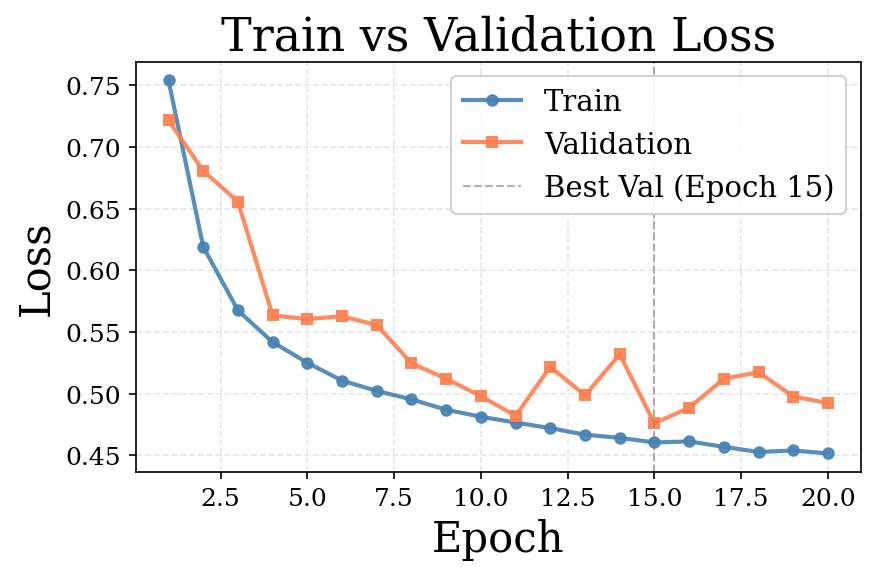

In [ ]:

plt.rcParams.update({'font.family': 'Serif', 'font.size': 12})
plt.style.use('tableau-colorblind10')

epochs = np.arange(1, len(train_losses) + 1)
best_epoch = np.argmin(test_losses) + 1

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.plot(epochs, train_losses, 'o-', linewidth=2, markersize=5,
        color='steelblue', label='Train', alpha=0.9)
ax.plot(epochs, test_losses, 's-', linewidth=2, markersize=5,
        color='coral', label='Validation', alpha=0.9)
ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Best Val (Epoch {best_epoch})')

ax.set_xlabel('Epoch', fontsize=20)
ax.set_ylabel('Loss', fontsize=20)
ax.set_title('Train vs Validation Loss', fontsize=22)
ax.legend(fontsize=14, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
device = torch.device(run_on)
fm_dataset=CatalogFMSampleDataset(spiders_catalog,logmbh=8, eddratio=0.3,norm=[1000, 10000],bg=2,nsamples=1024, device="cpu")
fm_loader = torch.utils.data.DataLoader(fm_dataset, batch_size=128, shuffle=False)

fm_dataset3=CatalogFMSampleDataset(spiders_catalog,logmbh=7.7, eddratio=0.3,norm=[1000, 10000],bg=2,nsamples=1024, device="cpu")
fm_loader3 = torch.utils.data.DataLoader(fm_dataset3, batch_size=128, shuffle=False)

fm_dataset2=CatalogFMSampleDataset(spiders_catalog,logmbh=7.3, eddratio=0.3,norm=[1000, 10000],bg=2,nsamples=1024, device="cpu")
fm_loader2 = torch.utils.data.DataLoader(fm_dataset2, batch_size=128, shuffle=False)

fm_dataset4=CatalogFMSampleDataset(spiders_catalog,logmbh=7, eddratio=0.3,norm=[1000, 10000],bg=2,nsamples=1024, device="cpu")
fm_loader4 = torch.utils.data.DataLoader(fm_dataset4, batch_size=128, shuffle=False)

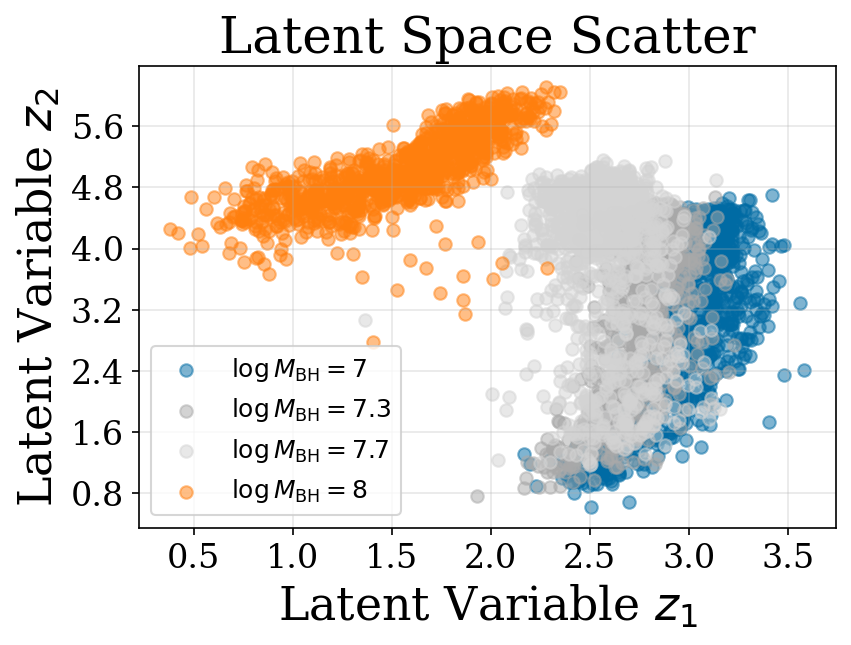

In [ ]:

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 12,
    'figure.titlesize': 30
})


autoencoder.eval()
device = torch.device(run_on)
results,results_2,results_3,results_4=[],[],[],[]
for X, y in fm_loader:
    X = X.to(device)
    with torch.no_grad():
        latent_var = encoder.forward(X)[:,0:2]
    results.append(latent_var.detach().cpu().numpy())
for X, y in fm_loader2:
    X = X.to(device)
    with torch.no_grad():
        latent_var = encoder.forward(X)[:,0:2]
    results_2.append(latent_var.detach().cpu().numpy())
for X, y in fm_loader3:
    X = X.to(device)
    with torch.no_grad():
        latent_var = encoder.forward(X)[:,0:2]
    results_3.append(latent_var.detach().cpu().numpy())
for X, y in fm_loader4:
    X = X.to(device)
    with torch.no_grad():
        latent_var = encoder.forward(X)[:,0:2]
    results_4.append(latent_var.detach().cpu().numpy())
results= np.vstack(results)
results_2= np.vstack(results_2)
results_3= np.vstack(results_3)
results_4= np.vstack(results_4)

plt.figure(figsize=(6, 4), dpi=150)

plt.scatter(results_4[:, 0], results_4[:, 1], alpha=0.5,
            label=r'$\log M_{\mathrm{BH}} = 7$')

plt.scatter(results_2[:, 0], results_2[:, 1], alpha=0.5,color='darkgrey',
            label=r'$\log M_{\mathrm{BH}} = 7.3$')

plt.scatter(results_3[:, 0], results_3[:, 1], alpha=0.5,color='lightgrey',
            label=r'$\log M_{\mathrm{BH}} = 7.7$')

plt.scatter(results[:, 0], results[:, 1], alpha=0.5,color='tab:orange',
            label=r'$\log M_{\mathrm{BH}} = 8$')

plt.xlabel(r'Latent Variable $z_1$')
plt.ylabel(r'Latent Variable $z_2$')
plt.title('Latent Space Scatter')
plt.grid(True, alpha=0.3)
plt.legend()

from matplotlib.ticker import MaxNLocator
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=8))   
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.show()

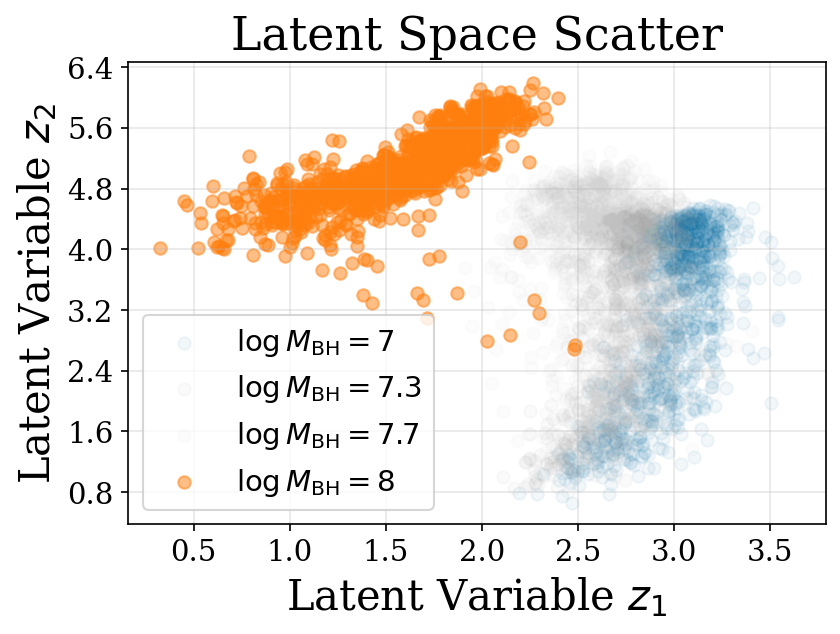

In [ ]:

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 26
})


autoencoder.eval()
device = torch.device(run_on)
results,results_2,results_3,results_4=[],[],[],[]
for X, y in fm_loader:
    X = X.to(device)
    with torch.no_grad():
        latent_var = encoder.forward(X)[:,0:2]
    results.append(latent_var.detach().cpu().numpy())
for X, y in fm_loader2:
    X = X.to(device)
    with torch.no_grad():
        latent_var = encoder.forward(X)[:,0:2]
    results_2.append(latent_var.detach().cpu().numpy())
for X, y in fm_loader3:
    X = X.to(device)
    with torch.no_grad():
        latent_var = encoder.forward(X)[:,0:2]
    results_3.append(latent_var.detach().cpu().numpy())
for X, y in fm_loader4:
    X = X.to(device)
    with torch.no_grad():
        latent_var = encoder.forward(X)[:,0:2]
    results_4.append(latent_var.detach().cpu().numpy())
results= np.vstack(results)
results_2= np.vstack(results_2)
results_3= np.vstack(results_3)
results_4= np.vstack(results_4)

plt.figure(figsize=(6, 4), dpi=150)

plt.scatter(results_4[:, 0], results_4[:, 1], alpha=0.05,
            label=r'$\log M_{\mathrm{BH}} = 7$')

plt.scatter(results_2[:, 0], results_2[:, 1], alpha=0.05,color='darkgrey',
            label=r'$\log M_{\mathrm{BH}} = 7.3$')

plt.scatter(results_3[:, 0], results_3[:, 1], alpha=0.05,color='lightgrey',
            label=r'$\log M_{\mathrm{BH}} = 7.7$')

plt.scatter(results[:, 0], results[:, 1], alpha=0.5,color='tab:orange',
            label=r'$\log M_{\mathrm{BH}} = 8$')

plt.xlabel(f'Latent Variable $z_{1}$')
plt.ylabel(f'Latent Variable $z_{2}$')
plt.title('Latent Space Scatter')
plt.grid(True, alpha=0.3)
plt.legend()


from matplotlib.ticker import MaxNLocator
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=8))   
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.show()

In [ ]:
from idna import encode


tmodel=torch.nn.TransformerEncoder(torch.nn.TransformerEncoderLayer(d_model=16, nhead=8,batch_first=True), num_layers=6)

X=torch.rand(32, 15, 16)
encoded= tmodel.forward(X)
print(encoded.shape)

torch.Size([32, 15, 16])


Computing Asimov trajectory (pure expected values)...


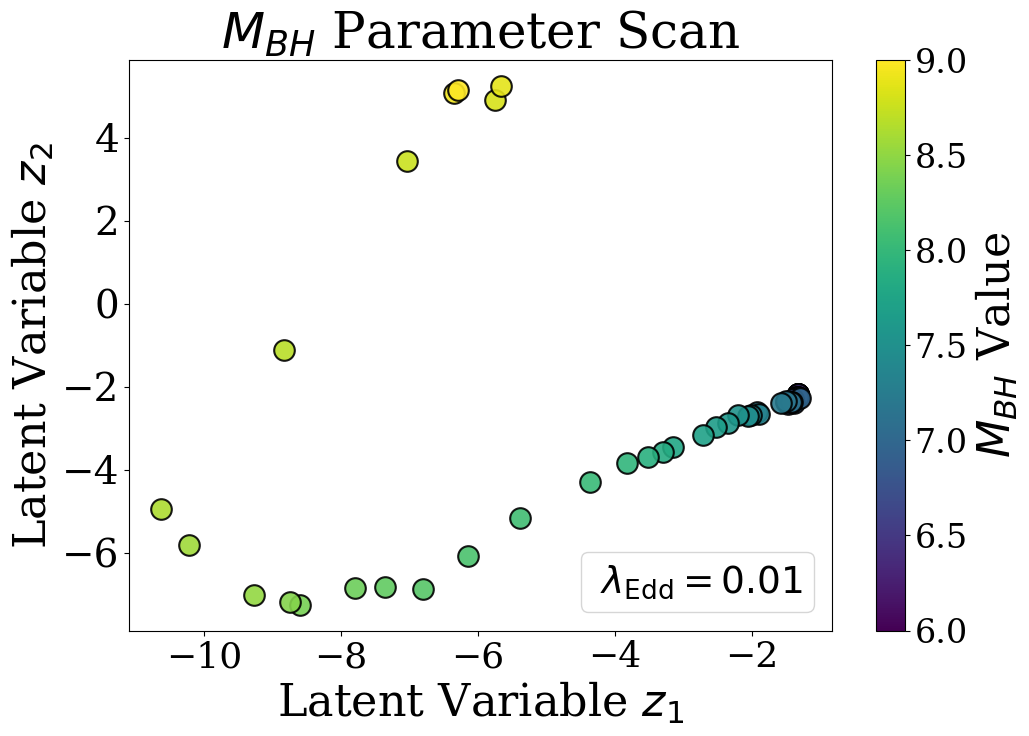

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import torch


plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 26,
    'figure.titlesize': 40
})

fixed_eddratio = 0.01
mbh_range = np.linspace(6, 9, 50)

autoencoder.eval()
asimov_traj = []

feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
norm_val = 12
bg_val = 2

print("Computing Asimov trajectory (pure expected values)...")
with torch.no_grad():
    for mbh_val in mbh_range:
        signal = 10**norm_val * neutrino_flux(
            spiders_catalog['redshift'].values,
            spiders_catalog['l_bol'].values,
            spiders_catalog['logBHM'].values,
            spiders_catalog['edd_ratio'].values,
            mbh_val,
            fixed_eddratio
        )

        expected_counts = bg_val + signal

        X_features_tensor = torch.as_tensor(
            spiders_catalog[feature_cols].values,
            dtype=torch.float32, device=run_on
        )
        log1p_expected = torch.as_tensor(
            np.log1p(expected_counts),
            dtype=torch.float32, device=run_on
        )
        X_input = torch.cat(
            [X_features_tensor, log1p_expected.unsqueeze(1)], dim=1
        ).unsqueeze(0)

        encoder_output = encoder.forward(X_input)
        mu = encoder_output[:, :encoder.latent_dim]
        asimov_traj.append(mu[0].cpu().numpy())

asimov_traj = np.array(asimov_traj)

fig, ax = plt.subplots(figsize=(11, 8))

dot_cmap = cm.viridis
norm = Normalize(vmin=mbh_range.min(), vmax=mbh_range.max())

for mbh_val, point in zip(mbh_range, asimov_traj):
    ax.scatter(point[0], point[1],
               color=dot_cmap(norm(mbh_val)),
               s=220,
               edgecolor='black',
               linewidth=1.5,
               alpha=0.9,
               zorder=3)

#lambda_proxy = Line2D([], [], linestyle='none', label=rf'λ_{{\\mathrm{{Edd}} = {fixed_eddratio:.2f}')
lambda_proxy = Line2D([], [], linestyle='none', label=rf'$\lambda_{{\mathrm{{Edd}}}} = {fixed_eddratio:.2f}$')


ax.legend(handles=[lambda_proxy],
          loc='lower right',
          frameon=True,
          handlelength=0,
          handletextpad=0.2,
          borderpad=0.3,
          fontsize=27)


ax.set_xlabel(f'Latent Variable $z_{1}$')
ax.set_ylabel(f'Latent Variable $z_{2}$')
ax.set_title(f'$M_{{BH}}$ Parameter Scan')


ax.grid(False)


sm = plt.cm.ScalarMappable(cmap=dot_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='$M_{BH}$ Value')
cbar.ax.tick_params(labelsize=24)

ax.ticklabel_format(style='plain')

plt.tight_layout()
plt.show()

Computing Asimov trajectory (pure expected values)...


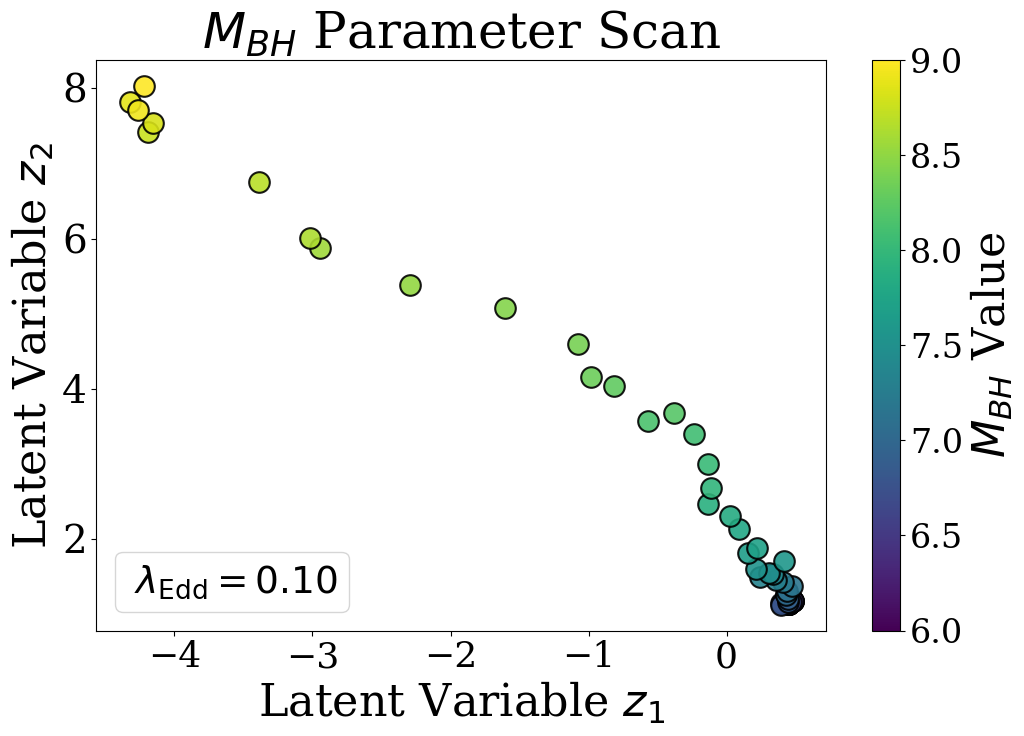

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import torch


plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 26,
    'figure.titlesize': 40
})

fixed_eddratio = 0.1
mbh_range = np.linspace(6, 9, 50)

autoencoder.eval()
asimov_traj = []

feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
norm_val = 12
bg_val = 2

print("Computing Asimov trajectory (pure expected values)...")
with torch.no_grad():
    for mbh_val in mbh_range:
        signal = 10**norm_val * neutrino_flux(
            spiders_catalog['redshift'].values,
            spiders_catalog['l_bol'].values,
            spiders_catalog['logBHM'].values,
            spiders_catalog['edd_ratio'].values,
            mbh_val,
            fixed_eddratio
        )

        expected_counts = bg_val + signal

        X_features_tensor = torch.as_tensor(
            spiders_catalog[feature_cols].values,
            dtype=torch.float32, device=run_on
        )
        log1p_expected = torch.as_tensor(
            np.log1p(expected_counts),
            dtype=torch.float32, device=run_on
        )
        X_input = torch.cat(
            [X_features_tensor, log1p_expected.unsqueeze(1)], dim=1
        ).unsqueeze(0)

        encoder_output = encoder.forward(X_input)
        mu = encoder_output[:, :encoder.latent_dim]
        asimov_traj.append(mu[0].cpu().numpy())

asimov_traj = np.array(asimov_traj)


fig, ax = plt.subplots(figsize=(11, 8))

dot_cmap = cm.viridis
norm = Normalize(vmin=mbh_range.min(), vmax=mbh_range.max())


for mbh_val, point in zip(mbh_range, asimov_traj):
    ax.scatter(point[0], point[1],
               color=dot_cmap(norm(mbh_val)),
               s=220,
               edgecolor='black',
               linewidth=1.5,
               alpha=0.9,
               zorder=3)

#lambda_proxy = Line2D([], [], linestyle='none', label=rf'λ_{{\mathrm{{Edd}} = {fixed_eddratio:.2f}')
lambda_proxy = Line2D([], [], linestyle='none', label=rf'$\lambda_{{\mathrm{{Edd}}}} = {fixed_eddratio:.2f}$')


ax.legend(handles=[lambda_proxy],
          loc='lower left',
          frameon=True,
          handlelength=0,
          handletextpad=0.2,
          borderpad=0.3,
          fontsize=27)


ax.set_xlabel(f'Latent Variable $z_{1}$')
ax.set_ylabel(f'Latent Variable $z_{2}$')
ax.set_title(f'$M_{{BH}}$ Parameter Scan')


ax.grid(False)


sm = plt.cm.ScalarMappable(cmap=dot_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='$M_{BH}$ Value')
cbar.ax.tick_params(labelsize=24)

ax.ticklabel_format(style='plain')

plt.tight_layout()
plt.show()


Computing Asimov trajectory (pure expected values)...


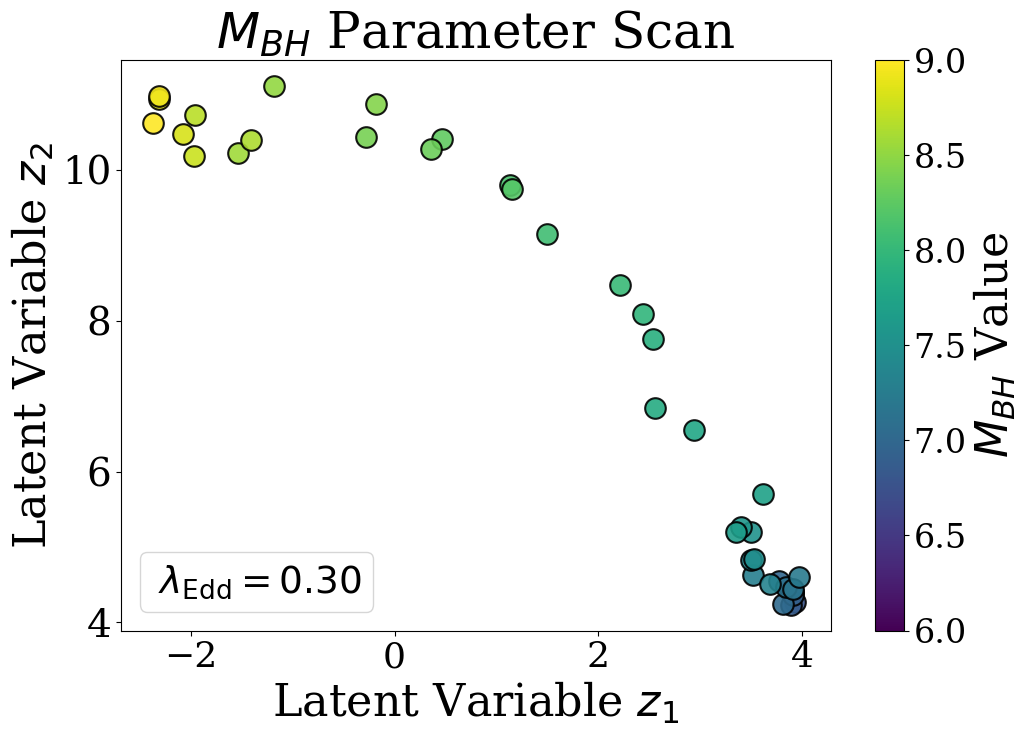

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import torch


plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 26,
    'figure.titlesize': 40
})


fixed_eddratio = 0.3
mbh_range = np.linspace(6, 9, 50)

autoencoder.eval()
asimov_traj = []

feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
norm_val = 12
bg_val = 2

print("Computing Asimov trajectory (pure expected values)...")
with torch.no_grad():
    for mbh_val in mbh_range:
        signal = 10**norm_val * neutrino_flux(
            spiders_catalog['redshift'].values,
            spiders_catalog['l_bol'].values,
            spiders_catalog['logBHM'].values,
            spiders_catalog['edd_ratio'].values,
            mbh_val,
            fixed_eddratio
        )

        expected_counts = bg_val + signal

        X_features_tensor = torch.as_tensor(
            spiders_catalog[feature_cols].values,
            dtype=torch.float32, device=run_on
        )
        log1p_expected = torch.as_tensor(
            np.log1p(expected_counts),
            dtype=torch.float32, device=run_on
        )
        X_input = torch.cat(
            [X_features_tensor, log1p_expected.unsqueeze(1)], dim=1
        ).unsqueeze(0)

        encoder_output = encoder.forward(X_input)
        mu = encoder_output[:, :encoder.latent_dim]
        asimov_traj.append(mu[0].cpu().numpy())

asimov_traj = np.array(asimov_traj)


fig, ax = plt.subplots(figsize=(11, 8))

dot_cmap = cm.viridis
norm = Normalize(vmin=mbh_range.min(), vmax=mbh_range.max())


for mbh_val, point in zip(mbh_range, asimov_traj):
    ax.scatter(point[0], point[1],
               color=dot_cmap(norm(mbh_val)),
               s=220,
               edgecolor='black',
               linewidth=1.5,
               alpha=0.9,
               zorder=3)

#lambda_proxy = Line2D([], [], linestyle='none', label=rf'λ_{{\mathrm{{Edd}} = {fixed_eddratio:.2f}')
lambda_proxy = Line2D([], [], linestyle='none', label=rf'$\lambda_{{\mathrm{{Edd}}}} = {fixed_eddratio:.2f}$')


ax.legend(handles=[lambda_proxy],
          loc='lower left',
          frameon=True,
          handlelength=0,
          handletextpad=0.2,
          borderpad=0.3,
          fontsize=27)


ax.set_xlabel(f'Latent Variable $z_{1}$')
ax.set_ylabel(f'Latent Variable $z_{2}$')
ax.set_title(f'$M_{{BH}}$ Parameter Scan')


ax.grid(False)

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=dot_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='$M_{BH}$ Value')
cbar.ax.tick_params(labelsize=24)

ax.ticklabel_format(style='plain')

plt.tight_layout()
plt.show()

Using single simulated dataset
Observed counts: min=0.0, max=147.0, mean=3.20
Observed data maps to latent point: (1.509, 4.932)
Pass 1: coarse grid to locate MLE...


  Coarse MLE: (2.366, 6.768)
Pass 2: fine grid around MLE...
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
  Progress: 100/100

Best-fit point in latent space (MLE): (2.346, 6.627)
Maximum log-likelihood: 0.00

Odds Ratio (H1 vs H0)
Background-only log-L: 787.78
Best-fit H1 log-L:     3516.61
Δ log-L (H1 − H0):    2728.83
Test statistic TS=2ΔlogL: 5457.67
Likelihood ratio (odds): ~10^1185


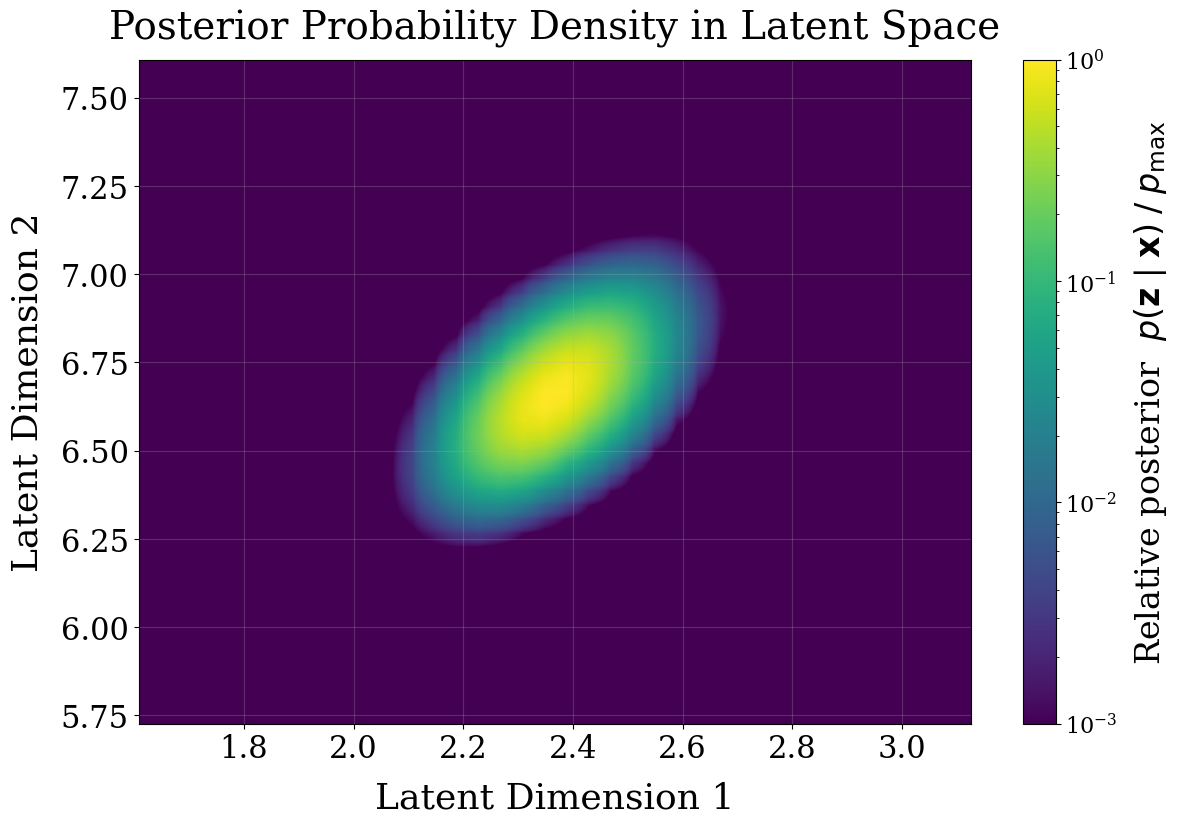


Posterior normalized. Sum = 1.000000
MLE in latent space: (2.346, 6.627)
Encoder μ:           (1.509, 4.932)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# step 1: Get observed counts
use_simulated = True
n_realizations = 1

if use_simulated:
    true_mbh_thres = 8
    true_e_ratio_thres = 0.3
    norm = [1000, 10000]
    bg = 2.0
    
    if n_realizations == 1:
        observed_counts, signal, bg_val = create_realization(
            spiders_catalog, true_mbh_thres, true_e_ratio_thres, norm=norm, bg=bg
        )
        observed_counts = observed_counts.astype(np.float32)
        print(f"Using single simulated dataset")
    else:
        print(f"Generating {n_realizations} realizations and averaging...")
        all_observed = []
        for r in range(n_realizations):
            obs, _, _ = create_realization(
                spiders_catalog, true_mbh_thres, true_e_ratio_thres, norm=norm, bg=bg
            )
            all_observed.append(obs)
        observed_counts = np.mean(all_observed, axis=0).astype(np.float32)
        bg_val = bg
        print(f"Averaged over {n_realizations} realizations")
else:
    raise NotImplementedError("Please provide your actual observed data")
    
print(f"Observed counts: min={observed_counts.min()}, max={observed_counts.max()}, mean={observed_counts.mean():.2f}")

# step 2: Define grid in latent space
autoencoder.eval()
feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
X_features = torch.as_tensor(spiders_catalog[feature_cols].values, dtype=torch.float32, device=run_on)

log1p_observed = torch.as_tensor(np.log1p(observed_counts), dtype=torch.float32, device=run_on)
X_input = torch.cat([X_features, log1p_observed.unsqueeze(1)], dim=1).unsqueeze(0)

with torch.no_grad():
    encoder_output = encoder(X_input)
    mu_observed = encoder_output[:, :encoder.latent_dim].cpu().numpy()[0]

print(f"Observed data maps to latent point: ({mu_observed[0]:.3f}, {mu_observed[1]:.3f})")

coarse_half = 6.0
coarse_ngrid = 50
coarse_z1 = np.linspace(mu_observed[0] - coarse_half, mu_observed[0] + coarse_half, coarse_ngrid)
coarse_z2 = np.linspace(mu_observed[1] - coarse_half, mu_observed[1] + coarse_half, coarse_ngrid)

print("Pass 1: coarse grid to locate MLE...")
coarse_ll = np.zeros((coarse_ngrid, coarse_ngrid))
for i, z1 in enumerate(coarse_z1):
    for j, z2 in enumerate(coarse_z2):
        mu_latent = torch.tensor([[z1, z2]], dtype=torch.float32, device=run_on)
        with torch.no_grad():
            out = decoder.net(mu_latent)
            out_clamped = out.clamp(min=0.0, max=20.0)
            predicted_counts = (torch.exp(out_clamped) - 1).cpu().numpy().flatten()
        lam = predicted_counts + bg
        # normalize predicted to match total observed counts (same as training loss)
        n_obs_total = observed_counts.sum()
        n_exp_total = lam.sum()
        if n_exp_total > 0:
            lam = lam * (n_obs_total / n_exp_total)
        lam = np.clip(lam, 1e-20, None)
        log_prior = -0.5 * (z1**2 + z2**2)  # N(0,1) VAE prior
        coarse_ll[j, i] = np.sum(observed_counts * np.log(lam) - lam) + log_prior

coarse_ll -= coarse_ll.max()
coarse_best = np.unravel_index(np.argmax(coarse_ll), coarse_ll.shape)
mle_z1_coarse = coarse_z1[coarse_best[1]]
mle_z2_coarse = coarse_z2[coarse_best[0]]
print(f"  Coarse MLE: ({mle_z1_coarse:.3f}, {mle_z2_coarse:.3f})")

fine_half = 2.0
ngrid = 100
latent_dim1_range = np.linspace(mle_z1_coarse - fine_half, mle_z1_coarse + fine_half, ngrid)
latent_dim2_range = np.linspace(mle_z2_coarse - fine_half, mle_z2_coarse + fine_half, ngrid)

LATENT_DIM1_grid, LATENT_DIM2_grid = np.meshgrid(latent_dim1_range, latent_dim2_range)

# step 3: compute log-likelihood (fine)
log_likelihood_grid_latent = np.zeros_like(LATENT_DIM1_grid)

print("Pass 2: fine grid around MLE...")
for i, z1 in enumerate(latent_dim1_range):
    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{len(latent_dim1_range)}")
    for j, z2 in enumerate(latent_dim2_range):
        
        mu_latent = torch.tensor([[z1, z2]], dtype=torch.float32, device=run_on)
        with torch.no_grad():
            out = decoder.net(mu_latent)
            out_clamped = out.clamp(min=0.0, max=20.0)
            predicted_counts = (torch.exp(out_clamped) - 1).cpu().numpy().flatten()
        
        lam = predicted_counts + bg
        # normalize predicted to match total observed counts (same as training loss)
        n_obs_total = observed_counts.sum()
        n_exp_total = lam.sum()
        if n_exp_total > 0:
            lam = lam * (n_obs_total / n_exp_total)
        lam = np.clip(lam, 1e-20, None)

        log_prior = -0.5 * (z1**2 + z2**2)  # N(0,1) VAE prior
        log_likelihood = np.sum(observed_counts * np.log(lam) - lam) + log_prior
        log_likelihood_grid_latent[j, i] = log_likelihood

# normalize (relative log-likelihood)
raw_max_ll = log_likelihood_grid_latent.max()
log_likelihood_grid_latent -= raw_max_ll

# MLE location
best_idx = np.unravel_index(np.argmax(log_likelihood_grid_latent), log_likelihood_grid_latent.shape)
best_z1 = LATENT_DIM1_grid[best_idx]
best_z2 = LATENT_DIM2_grid[best_idx]

print(f"\nBest-fit point in latent space (MLE): ({best_z1:.3f}, {best_z2:.3f})")
print(f"Maximum log-likelihood: {log_likelihood_grid_latent.max():.2f}")

# compute posterior
posterior_unnorm_latent = np.exp(log_likelihood_grid_latent)
posterior_latent = posterior_unnorm_latent / np.sum(posterior_unnorm_latent)

# Odds Ratio: H1 (signal+background) vs H0 (background-only)
n_sources = len(observed_counts)
lam_bkg = np.full(n_sources, observed_counts.sum() / n_sources)
lam_bkg = np.clip(lam_bkg, 1e-20, None)
log_L_bkg = np.sum(observed_counts * np.log(lam_bkg) - lam_bkg)
log_prior_at_mle = -0.5 * (best_z1**2 + best_z2**2)
log_L_H1 = raw_max_ll - log_prior_at_mle
delta_log_L = log_L_H1 - log_L_bkg
print(f"\nOdds Ratio (H1 vs H0)")
print(f"Background-only log-L: {log_L_bkg:.2f}")
print(f"Best-fit H1 log-L:     {log_L_H1:.2f}")
print(f"\u0394 log-L (H1 \u2212 H0):    {delta_log_L:.2f}")
print(f"Test statistic TS=2\u0394logL: {2*delta_log_L:.2f}")
if delta_log_L < 500:
    print(f"Likelihood ratio (odds): {np.exp(delta_log_L):.2e}")
else:
    print(f"Likelihood ratio (odds): ~10^{delta_log_L/np.log(10):.0f}")

# plot posterior using imshow
from matplotlib.colors import LogNorm

posterior_normalized = posterior_latent / posterior_latent.max()
# clip floor so LogNorm doesn't choke on zeros
posterior_normalized = np.clip(posterior_normalized, 1e-6, 1.0)

fig2, ax2 = plt.subplots(figsize=(13, 8))

im2 = ax2.imshow(
    posterior_normalized,
    origin='lower',
    extent=[latent_dim1_range.min(), latent_dim1_range.max(),
            latent_dim2_range.min(), latent_dim2_range.max()],
    cmap='viridis',
    norm=LogNorm(vmin=1e-3, vmax=1.0),
    aspect='auto',
    interpolation='bilinear'
)

# adaptive zoom: show region where log-likelihood > max - 10 (covers >99% of posterior mass)
significant = log_likelihood_grid_latent > -10.0
sig_rows, sig_cols = np.where(significant)
if len(sig_rows) > 0:
    z1_lo = latent_dim1_range[sig_cols.min()]
    z1_hi = latent_dim1_range[sig_cols.max()]
    z2_lo = latent_dim2_range[sig_rows.min()]
    z2_hi = latent_dim2_range[sig_rows.max()]
    pad = max(z1_hi - z1_lo, z2_hi - z2_lo) * 0.3 + 0.1
    ax2.set_xlim(z1_lo - pad, z1_hi + pad)
    ax2.set_ylim(z2_lo - pad, z2_hi + pad)

ax2.set_xlabel('Latent Dimension 1', fontsize=26, labelpad=12)
ax2.set_ylabel('Latent Dimension 2', fontsize=26, labelpad=12)
ax2.set_title('Posterior Probability Density in Latent Space', fontsize=28, pad=15)
ax2.tick_params(axis='both', which='major', labelsize=22)
ax2.grid(True, alpha=0.25)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.ax.tick_params(labelsize=16)
cbar2.set_label(r'Relative posterior  $p(\mathbf{z} \mid \mathbf{x}) \;/\; p_{\mathrm{max}}$', fontsize=24, labelpad=10)

fig2.subplots_adjust(left=0.12, right=0.92, bottom=0.10, top=0.93)
plt.show()

print(f"\nPosterior normalized. Sum = {np.sum(posterior_latent):.6f}")
print(f"MLE in latent space: ({best_z1:.3f}, {best_z2:.3f})")
print(f"Encoder μ:           ({mu_observed[0]:.3f}, {mu_observed[1]:.3f})")

Computing Asimov trajectory (pure expected values in log λ_Edd)...


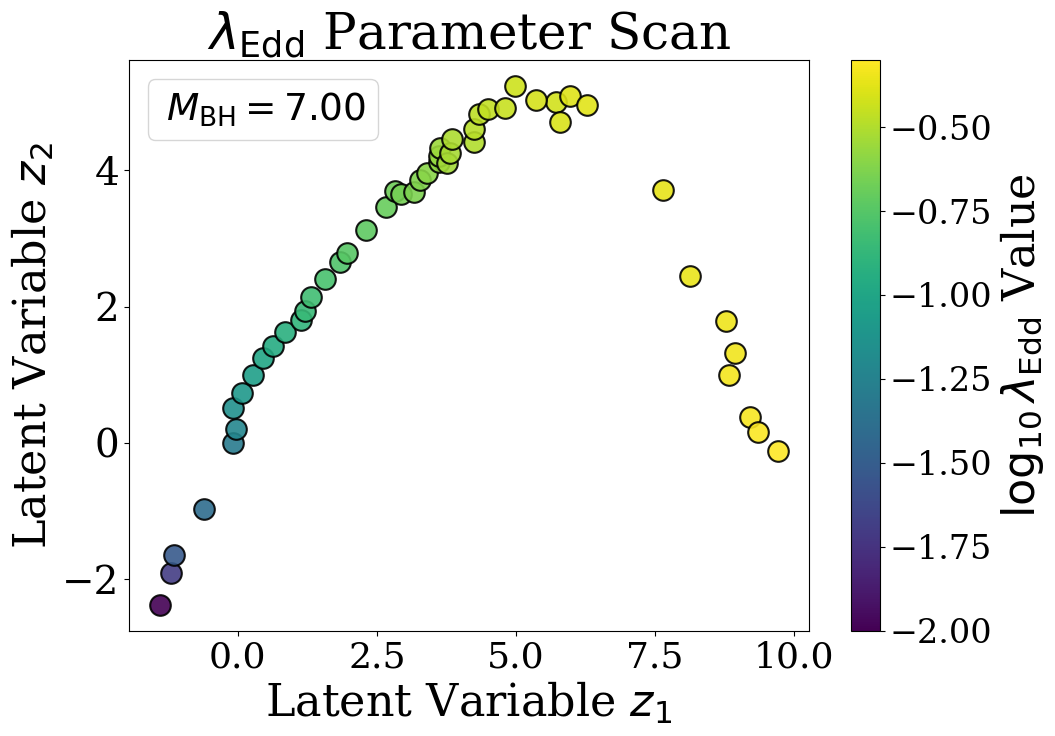

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import torch

plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 26,
    'figure.titlesize': 40
})

fixed_mbh = 7
eddratio_range = np.linspace(0.01, 0.5, 50) 
log_eddratio_range = np.log10(eddratio_range)  

autoencoder.eval()
asimov_traj = []

feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
norm_val = 12
bg_val = 2


log_edd_ratio_catalog = np.log10(spiders_catalog['edd_ratio'].values)

print("Computing Asimov trajectory (pure expected values in log λ_Edd)...")
with torch.no_grad():
    for eddratio_val in eddratio_range:
        log_eddratio_val = np.log10(eddratio_val)  

        signal = 10**norm_val * neutrino_flux(
            spiders_catalog['redshift'].values,
            spiders_catalog['l_bol'].values,
            spiders_catalog['logBHM'].values,
            log_edd_ratio_catalog,  
            fixed_mbh,
            log_eddratio_val        
        )

        expected_counts = bg_val + signal

        X_features_tensor = torch.as_tensor(
            spiders_catalog[feature_cols].values,
            dtype=torch.float32, device=run_on
        )
        log1p_expected = torch.as_tensor(
            np.log1p(expected_counts),
            dtype=torch.float32, device=run_on
        )
        X_input = torch.cat(
            [X_features_tensor, log1p_expected.unsqueeze(1)], dim=1
        ).unsqueeze(0)

        encoder_output = encoder.forward(X_input)
        mu = encoder_output[:, :encoder.latent_dim]
        asimov_traj.append(mu[0].cpu().numpy())

asimov_traj = np.array(asimov_traj)


fig, ax = plt.subplots(figsize=(11, 8))

dot_cmap = cm.viridis
norm = Normalize(vmin=log_eddratio_range.min(), vmax=log_eddratio_range.max())

for eddratio_val, point in zip(eddratio_range, asimov_traj):
    log_eddratio_val = np.log10(eddratio_val)
    ax.scatter(point[0], point[1],
               color=dot_cmap(norm(log_eddratio_val)),
               s=220,
               edgecolor='black',
               linewidth=1.5,
               alpha=0.9,
               zorder=3)

mbh_proxy = Line2D([], [], linestyle='none', label=rf'$M_{{\mathrm{{BH}}}} = {fixed_mbh:.2f}$')
ax.legend(handles=[mbh_proxy],
          loc='upper left',
          frameon=True,
          handlelength=0,
          handletextpad=0.2,
          borderpad=0.3,
          fontsize=27)

ax.set_xlabel(f'Latent Variable $z_{1}$')
ax.set_ylabel(f'Latent Variable $z_{2}$')
ax.set_title(f'$\\lambda_{{\\mathrm{{Edd}}}}$ Parameter Scan')
ax.grid(False)

# Colorbar for log λ_Edd
sm = plt.cm.ScalarMappable(cmap=dot_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='$\log_{10} \\lambda_{\\mathrm{Edd}}$ Value')
cbar.ax.tick_params(labelsize=24)

ax.ticklabel_format(style='plain')

plt.tight_layout()
plt.show()

Computing Asimov trajectory (pure expected values in log λ_Edd)...


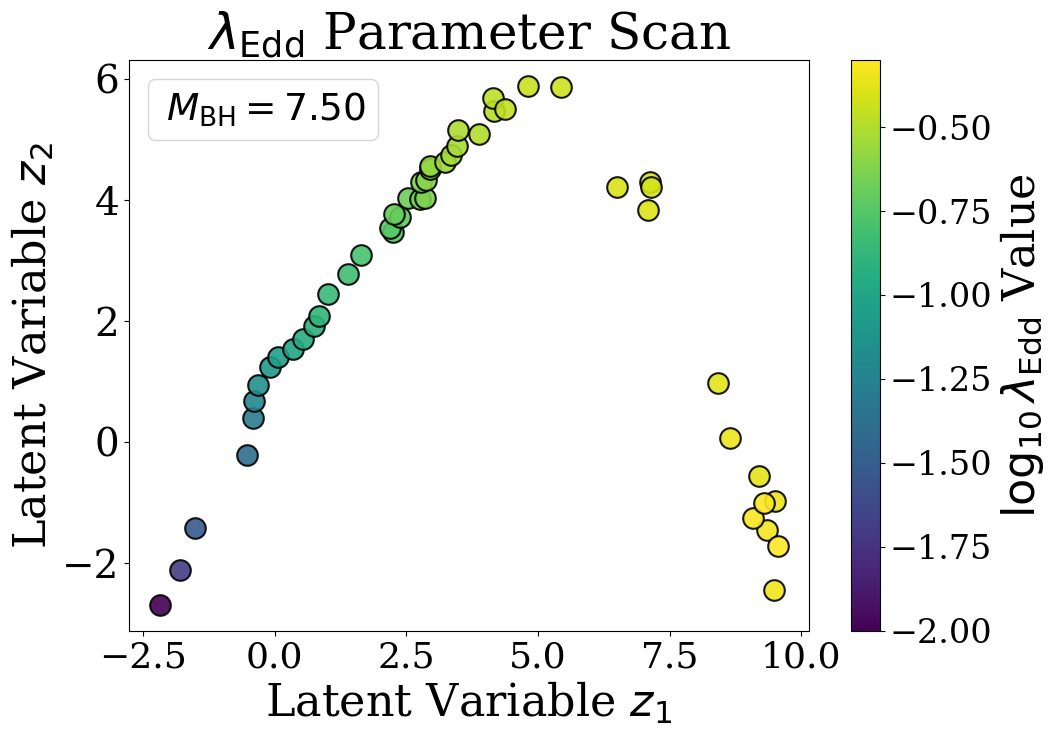

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import torch

plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 26,
    'figure.titlesize': 40
})

fixed_mbh = 7.5
eddratio_range = np.linspace(0.01, 0.5, 50)  # raw Eddington ratios
log_eddratio_range = np.log10(eddratio_range)  # log10 scale

autoencoder.eval()
asimov_traj = []

feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
norm_val = 12
bg_val = 2

# Precompute log10 of catalog Eddington ratios
log_edd_ratio_catalog = np.log10(spiders_catalog['edd_ratio'].values)

print("Computing Asimov trajectory (pure expected values in log λ_Edd)...")
with torch.no_grad():
    for eddratio_val in eddratio_range:
        log_eddratio_val = np.log10(eddratio_val)  

        signal = 10**norm_val * neutrino_flux(
            spiders_catalog['redshift'].values,
            spiders_catalog['l_bol'].values,
            spiders_catalog['logBHM'].values,
            log_edd_ratio_catalog,  
            fixed_mbh,
            log_eddratio_val        
        )

        expected_counts = bg_val + signal

        X_features_tensor = torch.as_tensor(
            spiders_catalog[feature_cols].values,
            dtype=torch.float32, device=run_on
        )
        log1p_expected = torch.as_tensor(
            np.log1p(expected_counts),
            dtype=torch.float32, device=run_on
        )
        X_input = torch.cat(
            [X_features_tensor, log1p_expected.unsqueeze(1)], dim=1
        ).unsqueeze(0)

        encoder_output = encoder.forward(X_input)
        mu = encoder_output[:, :encoder.latent_dim]
        asimov_traj.append(mu[0].cpu().numpy())

asimov_traj = np.array(asimov_traj)


fig, ax = plt.subplots(figsize=(11, 8))

dot_cmap = cm.viridis
norm = Normalize(vmin=log_eddratio_range.min(), vmax=log_eddratio_range.max())

for eddratio_val, point in zip(eddratio_range, asimov_traj):
    log_eddratio_val = np.log10(eddratio_val)
    ax.scatter(point[0], point[1],
               color=dot_cmap(norm(log_eddratio_val)),
               s=220,
               edgecolor='black',
               linewidth=1.5,
               alpha=0.9,
               zorder=3)

mbh_proxy = Line2D([], [], linestyle='none', label=rf'$M_{{\mathrm{{BH}}}} = {fixed_mbh:.2f}$')
ax.legend(handles=[mbh_proxy],
          loc='upper left',
          frameon=True,
          handlelength=0,
          handletextpad=0.2,
          borderpad=0.3,
          fontsize=27)

ax.set_xlabel(f'Latent Variable $z_{1}$')
ax.set_ylabel(f'Latent Variable $z_{2}$')
ax.set_title(f'$\\lambda_{{\\mathrm{{Edd}}}}$ Parameter Scan')
ax.grid(False)

# colorbar for log λ_Edd
sm = plt.cm.ScalarMappable(cmap=dot_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='$\log_{10} \\lambda_{\\mathrm{Edd}}$ Value')
cbar.ax.tick_params(labelsize=24)

ax.ticklabel_format(style='plain')

plt.tight_layout()
plt.show()

Computing Asimov trajectory (pure expected values in log λ_Edd)...


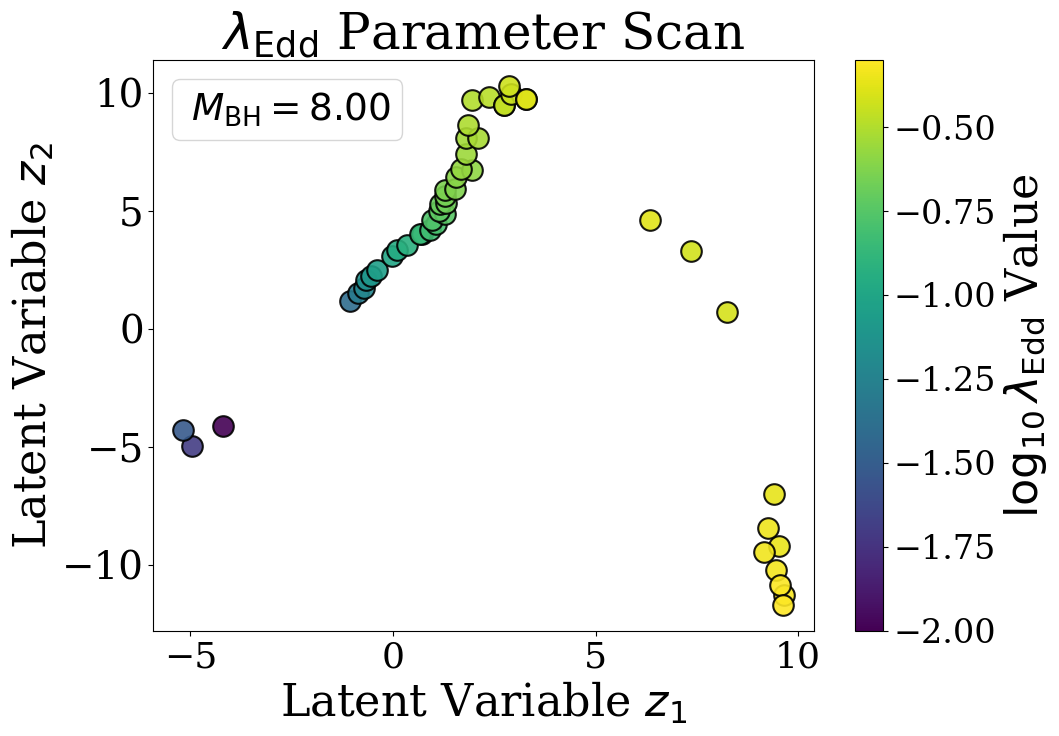

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import torch

plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 26,
    'figure.titlesize': 40
})

fixed_mbh = 8
eddratio_range = np.linspace(0.01, 0.5, 50)  
log_eddratio_range = np.log10(eddratio_range)  

autoencoder.eval()
asimov_traj = []

feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
norm_val = 12
bg_val = 2

log_edd_ratio_catalog = np.log10(spiders_catalog['edd_ratio'].values)

print("Computing Asimov trajectory (pure expected values in log λ_Edd)...")
with torch.no_grad():
    for eddratio_val in eddratio_range:
        log_eddratio_val = np.log10(eddratio_val)  

        signal = 10**norm_val * neutrino_flux(
            spiders_catalog['redshift'].values,
            spiders_catalog['l_bol'].values,
            spiders_catalog['logBHM'].values,
            log_edd_ratio_catalog,  
            fixed_mbh,
            log_eddratio_val        
        )

        expected_counts = bg_val + signal

        X_features_tensor = torch.as_tensor(
            spiders_catalog[feature_cols].values,
            dtype=torch.float32, device=run_on
        )
        log1p_expected = torch.as_tensor(
            np.log1p(expected_counts),
            dtype=torch.float32, device=run_on
        )
        X_input = torch.cat(
            [X_features_tensor, log1p_expected.unsqueeze(1)], dim=1
        ).unsqueeze(0)

        encoder_output = encoder.forward(X_input)
        mu = encoder_output[:, :encoder.latent_dim]
        asimov_traj.append(mu[0].cpu().numpy())

asimov_traj = np.array(asimov_traj)

fig, ax = plt.subplots(figsize=(11, 8))

dot_cmap = cm.viridis
norm = Normalize(vmin=log_eddratio_range.min(), vmax=log_eddratio_range.max())

for eddratio_val, point in zip(eddratio_range, asimov_traj):
    log_eddratio_val = np.log10(eddratio_val)
    ax.scatter(point[0], point[1],
               color=dot_cmap(norm(log_eddratio_val)),
               s=220,
               edgecolor='black',
               linewidth=1.5,
               alpha=0.9,
               zorder=3)

mbh_proxy = Line2D([], [], linestyle='none', label=rf'$M_{{\mathrm{{BH}}}} = {fixed_mbh:.2f}$')
ax.legend(handles=[mbh_proxy],
          loc='upper left',
          frameon=True,
          handlelength=0,
          handletextpad=0.2,
          borderpad=0.3,
          fontsize=27)

ax.set_xlabel(f'Latent Variable $z_{1}$')
ax.set_ylabel(f'Latent Variable $z_{2}$')
ax.set_title(f'$\\lambda_{{\\mathrm{{Edd}}}}$ Parameter Scan')
ax.grid(False)

# Colorbar for log λ_Edd
sm = plt.cm.ScalarMappable(cmap=dot_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='$\log_{10} \\lambda_{\\mathrm{Edd}}$ Value')
cbar.ax.tick_params(labelsize=24)

ax.ticklabel_format(style='plain')

plt.tight_layout()
plt.show()

Computing VAE output for all sources...
Selected top 30 sources with signal values ranging from 35.17 to 262.41


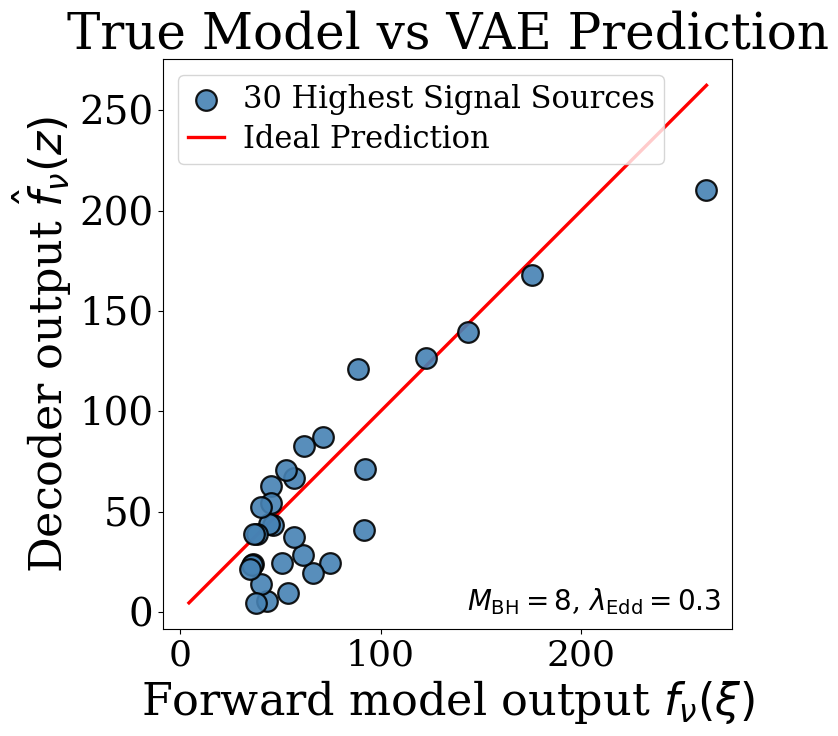


=== Comparison: True Model vs VAE Prediction (Top 30 Sources) ===
True Model (neutrino_flux Signal):
  Mean: 70.3697
  Std: 48.5256
  Min: 35.1717, Max: 262.4111

VAE Prediction (Signal):
  Mean: 58.4558
  Std: 49.2065
  Min: 4.5327, Max: 210.2184

Difference (VAE - True Model):
  Mean: -11.9138
  Std: 23.7299
  RMSE: 26.5528

Correlation: 0.8822


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch


plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 22,  
    'figure.titlesize': 40
})


mbh_thres = 8
e_ratio_thres = 0.3
norm_val = [1000, 10000]  # match training norm
bg = 2.0  

flux = neutrino_flux(
    spiders_catalog['redshift'].values,
    spiders_catalog['l_bol'].values,
    spiders_catalog['logBHM'].values,
    spiders_catalog['edd_ratio'].values,
    mbh_thres,
    e_ratio_thres
)
# Normalize total signal to geometric mean of training range
total_signal = np.sqrt(norm_val[0] * norm_val[1])
flux_sum = np.sum(flux)
true_signal = flux * (total_signal / flux_sum) if flux_sum > 0 else flux

true_counts = true_signal + bg  # E(signal) + background

# create VAE input
feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
X_features = torch.as_tensor(
    spiders_catalog[feature_cols].values,
    dtype=torch.float32, device=run_on
)

log1p_true_counts = torch.as_tensor(
    np.log1p(true_counts),
    dtype=torch.float32, device=run_on
)

X_input = torch.cat(
    [X_features, log1p_true_counts.unsqueeze(1)], dim=1
).unsqueeze(0)

#VAE prediction
autoencoder.eval()
print("Computing VAE output for all sources...")
with torch.no_grad():
    output, mu, logvar = autoencoder(X_input)
    # get predicted signal 
    predicted_signal = output.cpu().numpy().flatten()
    
    # apply same normalization as in loss function 
    # get observed counts from input
    k = torch.exp(X_input[..., -1]) - 1  # Shape: (1, nsources)
    k_np = k.cpu().numpy().flatten()
    
    # add background to predicted signal to get lambda
    bg_val = 2.0
    lam = predicted_signal + bg_val
    
    # normalize lambda to match total observed counts (same as in poisson_loss)
    n_obs = k_np.sum()
    n_exp = lam.sum()
    if n_exp > 0:
        lam_normalized = lam * (n_obs / n_exp)
        # Extract normalized signal
        predicted_signal_np = lam_normalized - bg_val
    else:
        predicted_signal_np = predicted_signal

# VAE output is already signal (now normalized)
true_signal_np = np.array(true_signal)


#select top 30 sources
top_30_indices = np.argsort(true_signal_np)[-30:][::-1]

true_signal_top30 = true_signal_np[top_30_indices]
predicted_signal_top30 = predicted_signal_np[top_30_indices]

print(f"Selected top 30 sources with signal values ranging from "
      f"{true_signal_top30.min():.2f} to {true_signal_top30.max():.2f}")

fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    true_signal_top30,
    predicted_signal_top30,
    s=220,
    color='steelblue',
    edgecolor='black',
    linewidth=1.6,
    alpha=0.9,
    zorder=3,
    label="30 Highest Signal Sources"
)

min_val = min(true_signal_top30.min(), predicted_signal_top30.min())
max_val = max(true_signal_top30.max(), predicted_signal_top30.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='-',
    linewidth=2.4,
    color='red',
    zorder=2,
    label="Ideal Prediction"
)


ax.set_xlabel(r'Forward model output $f_\nu(\xi)$')
ax.set_ylabel(r'Decoder output $\hat{f}_\nu(z)$')
ax.set_title('True Model vs VAE Prediction')


legend = ax.legend(
    frameon=True,
    borderpad=0.3,
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    fontsize=22, 
    loc='upper left'
)


param_text = rf'$M_{{\rm BH}} = {mbh_thres}$' + ', ' + rf'$\lambda_{{\rm Edd}} = {e_ratio_thres}$'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes,
        fontsize=20, horizontalalignment='right', verticalalignment='bottom')

ax.grid(False)
ax.ticklabel_format(style='plain')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


#summary stats
print("\n=== Comparison: True Model vs VAE Prediction (Top 30 Sources) ===")
print(f"True Model (neutrino_flux Signal):")
print(f"  Mean: {np.mean(true_signal_top30):.4f}")
print(f"  Std: {np.std(true_signal_top30):.4f}")
print(f"  Min: {np.min(true_signal_top30):.4f}, Max: {np.max(true_signal_top30):.4f}")

print(f"\nVAE Prediction (Signal):")
print(f"  Mean: {np.mean(predicted_signal_top30):.4f}")
print(f"  Std: {np.std(predicted_signal_top30):.4f}")
print(f"  Min: {np.min(predicted_signal_top30):.4f}, Max: {np.max(predicted_signal_top30):.4f}")

difference_top30 = predicted_signal_top30 - true_signal_top30
print(f"\nDifference (VAE - True Model):")
print(f"  Mean: {np.mean(difference_top30):.4f}")
print(f"  Std: {np.std(difference_top30):.4f}")
print(f"  RMSE: {np.sqrt(np.mean(difference_top30**2)):.4f}")

correlation_top30 = np.corrcoef(true_signal_top30, predicted_signal_top30)[0, 1]
print(f"\nCorrelation: {correlation_top30:.4f}")


Computing VAE output for all sources...
Selected top 30 sources with signal values ranging from 29.48 to 200.93


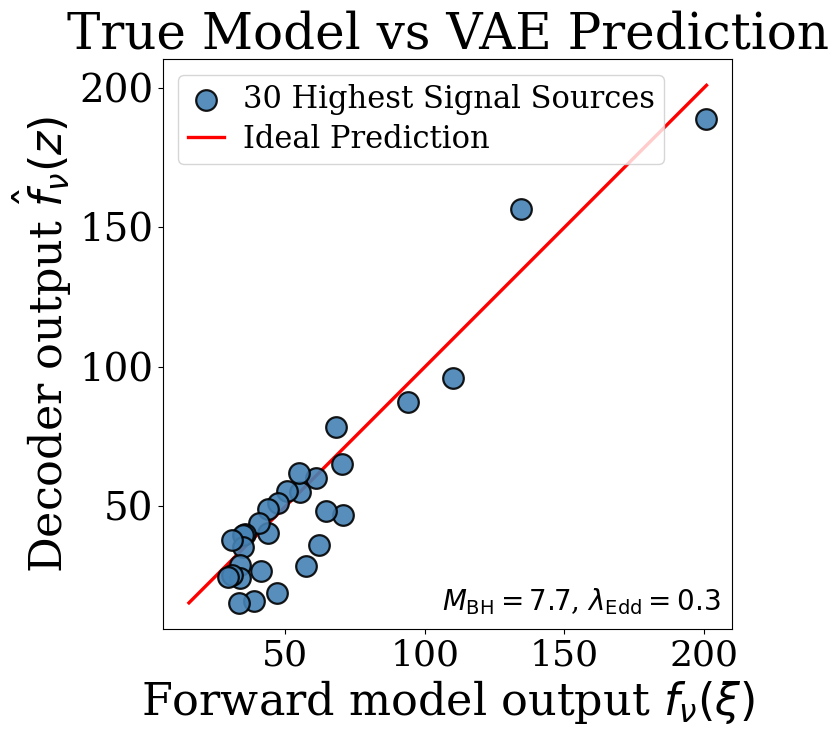


Comparison: True Model vs VAE Prediction (Top 30 Sources)
True Model (neutrino_flux Signal):
  Mean: 58.4560
  Std: 35.6038
  Min: 29.4809, Max: 200.9263

VAE Prediction (Signal):
  Mean: 52.8379
  Std: 37.7624
  Min: 15.4568, Max: 188.8914

Difference (VAE - True Model):
  Mean: -5.6181
  Std: 12.3606
  RMSE: 13.5774

Correlation: 0.9449


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch


plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 22,  
    'figure.titlesize': 40
})


mbh_thres = 7.7
e_ratio_thres = 0.3
norm_val = [1000, 10000]  # match training norm
bg = 2.0  

flux = neutrino_flux(
    spiders_catalog['redshift'].values,
    spiders_catalog['l_bol'].values,
    spiders_catalog['logBHM'].values,
    spiders_catalog['edd_ratio'].values,
    mbh_thres,
    e_ratio_thres
)
# Normalize total signal to geometric mean of training range
total_signal = np.sqrt(norm_val[0] * norm_val[1])
flux_sum = np.sum(flux)
true_signal = flux * (total_signal / flux_sum) if flux_sum > 0 else flux

true_counts = true_signal + bg  # E(signal) + background

# create VAE input
feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
X_features = torch.as_tensor(
    spiders_catalog[feature_cols].values,
    dtype=torch.float32, device=run_on
)

log1p_true_counts = torch.as_tensor(
    np.log1p(true_counts),
    dtype=torch.float32, device=run_on
)

X_input = torch.cat(
    [X_features, log1p_true_counts.unsqueeze(1)], dim=1
).unsqueeze(0)

# VAE prediction
autoencoder.eval()
print("Computing VAE output for all sources...")
with torch.no_grad():
    output, mu, logvar = autoencoder(X_input)
    # get predicted signal (decoder output is already signal)
    predicted_signal = output.cpu().numpy().flatten()
    

    # get observed counts from input
    k = torch.exp(X_input[..., -1]) - 1  # Shape: (1, nsources)
    k_np = k.cpu().numpy().flatten()
    
    # add background to predicted signal to get lambda
    bg_val = 2.0
    lam = predicted_signal + bg_val
    
    # normalize lambda to match total observed counts (same as in poisson_loss)
    n_obs = k_np.sum()
    n_exp = lam.sum()
    if n_exp > 0:
        lam_normalized = lam * (n_obs / n_exp)
        # extract normalized signal
        predicted_signal_np = lam_normalized - bg_val
    else:
        predicted_signal_np = predicted_signal

# VAE output is already signal (now normalized)
true_signal_np = np.array(true_signal)

# select top 30 sources
top_30_indices = np.argsort(true_signal_np)[-30:][::-1]

true_signal_top30 = true_signal_np[top_30_indices]
predicted_signal_top30 = predicted_signal_np[top_30_indices]

print(f"Selected top 30 sources with signal values ranging from "
      f"{true_signal_top30.min():.2f} to {true_signal_top30.max():.2f}")


fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    true_signal_top30,
    predicted_signal_top30,
    s=220,
    color='steelblue',
    edgecolor='black',
    linewidth=1.6,
    alpha=0.9,
    zorder=3,
    label="30 Highest Signal Sources"
)


min_val = min(true_signal_top30.min(), predicted_signal_top30.min())
max_val = max(true_signal_top30.max(), predicted_signal_top30.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='-',
    linewidth=2.4,
    color='red',
    zorder=2,
    label="Ideal Prediction"
)

ax.set_xlabel(r'Forward model output $f_\nu(\xi)$')
ax.set_ylabel(r'Decoder output $\hat{f}_\nu(z)$')
ax.set_title('True Model vs VAE Prediction')


legend = ax.legend(
    frameon=True,
    borderpad=0.3,
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    fontsize=22,  
    loc='upper left'
)

param_text = rf'$M_{{\rm BH}} = {mbh_thres}$' + ', ' + rf'$\lambda_{{\rm Edd}} = {e_ratio_thres}$'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes,
        fontsize=20, horizontalalignment='right', verticalalignment='bottom')

ax.grid(False)
ax.ticklabel_format(style='plain')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


#summary stats
print("\nComparison: True Model vs VAE Prediction (Top 30 Sources)")
print(f"True Model (neutrino_flux Signal):")
print(f"  Mean: {np.mean(true_signal_top30):.4f}")
print(f"  Std: {np.std(true_signal_top30):.4f}")
print(f"  Min: {np.min(true_signal_top30):.4f}, Max: {np.max(true_signal_top30):.4f}")

print(f"\nVAE Prediction (Signal):")
print(f"  Mean: {np.mean(predicted_signal_top30):.4f}")
print(f"  Std: {np.std(predicted_signal_top30):.4f}")
print(f"  Min: {np.min(predicted_signal_top30):.4f}, Max: {np.max(predicted_signal_top30):.4f}")

difference_top30 = predicted_signal_top30 - true_signal_top30
print(f"\nDifference (VAE - True Model):")
print(f"  Mean: {np.mean(difference_top30):.4f}")
print(f"  Std: {np.std(difference_top30):.4f}")
print(f"  RMSE: {np.sqrt(np.mean(difference_top30**2)):.4f}")

correlation_top30 = np.corrcoef(true_signal_top30, predicted_signal_top30)[0, 1]
print(f"\nCorrelation: {correlation_top30:.4f}")




Computing VAE output for all sources...
Selected top 30 sources with signal values ranging from 26.10 to 169.90


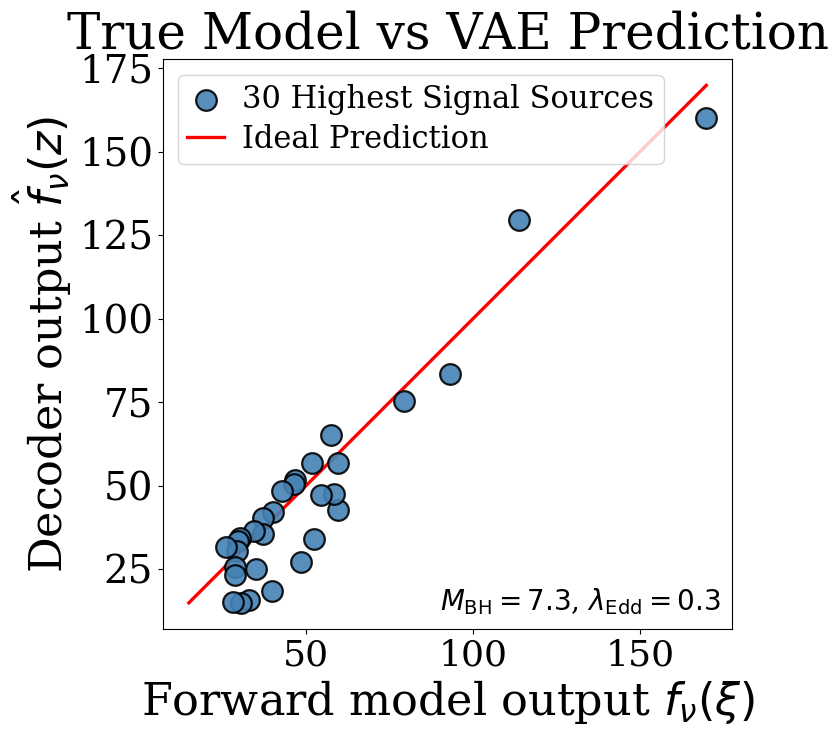


Comparison: True Model vs VAE Prediction (Top 30 Sources)
True Model (neutrino_flux Signal):
  Mean: 50.6983
  Std: 29.6836
  Min: 26.1014, Max: 169.9020

VAE Prediction (Signal):
  Mean: 46.6069
  Std: 31.3344
  Min: 14.8557, Max: 160.1973

Difference (VAE - True Model):
  Mean: -4.0914
  Std: 9.5992
  RMSE: 10.4348

Correlation: 0.9519


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch


plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 22,  
    'figure.titlesize': 40
})


mbh_thres = 7.3
e_ratio_thres = 0.3
norm_val = [1000, 10000]  # match training norm
bg = 2.0  

flux = neutrino_flux(
    spiders_catalog['redshift'].values,
    spiders_catalog['l_bol'].values,
    spiders_catalog['logBHM'].values,
    spiders_catalog['edd_ratio'].values,
    mbh_thres,
    e_ratio_thres
)
# normalize total signal to geometric mean of training range
total_signal = np.sqrt(norm_val[0] * norm_val[1])
flux_sum = np.sum(flux)
true_signal = flux * (total_signal / flux_sum) if flux_sum > 0 else flux

true_counts = true_signal + bg  # E(signal) + background

# create VAE input
feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
X_features = torch.as_tensor(
    spiders_catalog[feature_cols].values,
    dtype=torch.float32, device=run_on
)

log1p_true_counts = torch.as_tensor(
    np.log1p(true_counts),
    dtype=torch.float32, device=run_on
)

X_input = torch.cat(
    [X_features, log1p_true_counts.unsqueeze(1)], dim=1
).unsqueeze(0)

# VAE prediction
autoencoder.eval()
print("Computing VAE output for all sources...")
with torch.no_grad():
    output, mu, logvar = autoencoder(X_input)
    # get predicted signal (decoder output is already signal)
    predicted_signal = output.cpu().numpy().flatten()
    
    # get observed counts from input
    k = torch.exp(X_input[..., -1]) - 1  # Shape: (1, nsources)
    k_np = k.cpu().numpy().flatten()
    
    # add background to predicted signal to get lambda
    bg_val = 2.0
    lam = predicted_signal + bg_val
    
    # normalize lambda to match total observed counts (same as in poisson_loss)
    n_obs = k_np.sum()
    n_exp = lam.sum()
    if n_exp > 0:
        lam_normalized = lam * (n_obs / n_exp)
        # extract normalized signal
        predicted_signal_np = lam_normalized - bg_val
    else:
        predicted_signal_np = predicted_signal

# VAE output is already signal (now normalized)
true_signal_np = np.array(true_signal)

# select top 30 sources
top_30_indices = np.argsort(true_signal_np)[-30:][::-1]

true_signal_top30 = true_signal_np[top_30_indices]
predicted_signal_top30 = predicted_signal_np[top_30_indices]

print(f"Selected top 30 sources with signal values ranging from "
      f"{true_signal_top30.min():.2f} to {true_signal_top30.max():.2f}")


fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    true_signal_top30,
    predicted_signal_top30,
    s=220,
    color='steelblue',
    edgecolor='black',
    linewidth=1.6,
    alpha=0.9,
    zorder=3,
    label="30 Highest Signal Sources"
)


min_val = min(true_signal_top30.min(), predicted_signal_top30.min())
max_val = max(true_signal_top30.max(), predicted_signal_top30.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='-',
    linewidth=2.4,
    color='red',
    zorder=2,
    label="Ideal Prediction"
)

ax.set_xlabel(r'Forward model output $f_\nu(\xi)$')
ax.set_ylabel(r'Decoder output $\hat{f}_\nu(z)$')
ax.set_title('True Model vs VAE Prediction')


legend = ax.legend(
    frameon=True,
    borderpad=0.3,
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    fontsize=22,  
    loc='upper left'
)

param_text = rf'$M_{{\rm BH}} = {mbh_thres}$' + ', ' + rf'$\lambda_{{\rm Edd}} = {e_ratio_thres}$'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes,
        fontsize=20, horizontalalignment='right', verticalalignment='bottom')

ax.grid(False)
ax.ticklabel_format(style='plain')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


#summary stats
print("\nComparison: True Model vs VAE Prediction (Top 30 Sources)")
print(f"True Model (neutrino_flux Signal):")
print(f"  Mean: {np.mean(true_signal_top30):.4f}")
print(f"  Std: {np.std(true_signal_top30):.4f}")
print(f"  Min: {np.min(true_signal_top30):.4f}, Max: {np.max(true_signal_top30):.4f}")

print(f"\nVAE Prediction (Signal):")
print(f"  Mean: {np.mean(predicted_signal_top30):.4f}")
print(f"  Std: {np.std(predicted_signal_top30):.4f}")
print(f"  Min: {np.min(predicted_signal_top30):.4f}, Max: {np.max(predicted_signal_top30):.4f}")

difference_top30 = predicted_signal_top30 - true_signal_top30
print(f"\nDifference (VAE - True Model):")
print(f"  Mean: {np.mean(difference_top30):.4f}")
print(f"  Std: {np.std(difference_top30):.4f}")
print(f"  RMSE: {np.sqrt(np.mean(difference_top30**2)):.4f}")

correlation_top30 = np.corrcoef(true_signal_top30, predicted_signal_top30)[0, 1]
print(f"\nCorrelation: {correlation_top30:.4f}")




Computing VAE output for all sources...
Selected top 30 sources with signal values ranging from 25.35 to 152.56


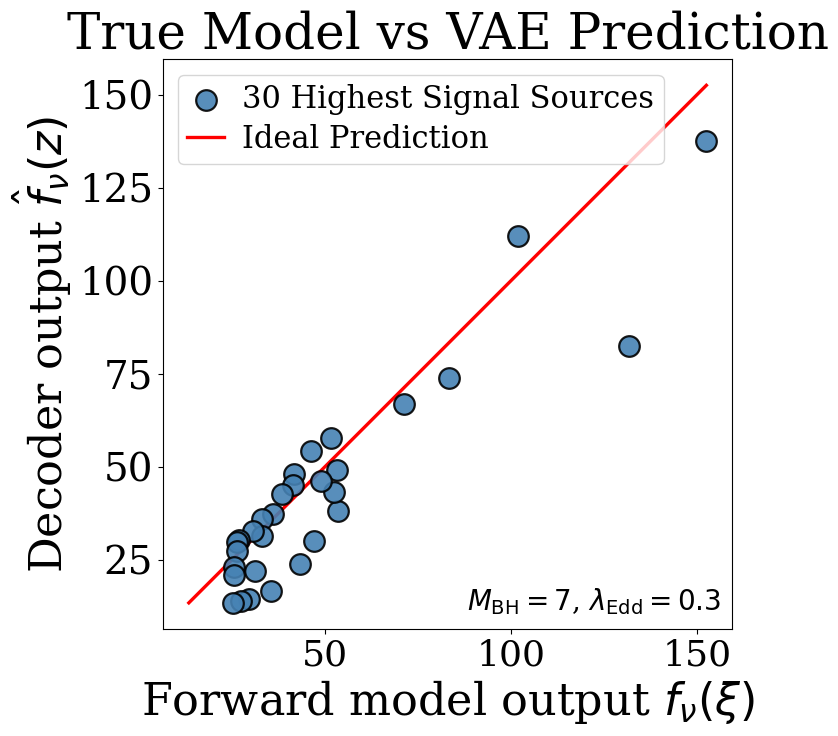


Comparison: True Model vs VAE Prediction (Top 30 Sources)
True Model (neutrino_flux Signal):
  Mean: 49.1327
  Std: 30.4728
  Min: 25.3543, Max: 152.5642

VAE Prediction (Signal):
  Mean: 43.4422
  Std: 27.8238
  Min: 13.5227, Max: 137.6496

Difference (VAE - True Model):
  Mean: -5.6905
  Std: 11.7126
  RMSE: 13.0218

Correlation: 0.9232


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch


plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 22,  
    'figure.titlesize': 40
})


mbh_thres = 7
e_ratio_thres = 0.3
norm_val = [1000, 10000]  # match training norm
bg = 2.0  

flux = neutrino_flux(
    spiders_catalog['redshift'].values,
    spiders_catalog['l_bol'].values,
    spiders_catalog['logBHM'].values,
    spiders_catalog['edd_ratio'].values,
    mbh_thres,
    e_ratio_thres
)
# normalize total signal to geometric mean of training range
total_signal = np.sqrt(norm_val[0] * norm_val[1])
flux_sum = np.sum(flux)
true_signal = flux * (total_signal / flux_sum) if flux_sum > 0 else flux

true_counts = true_signal + bg  # E(signal) + background

# create VAE input
feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
X_features = torch.as_tensor(
    spiders_catalog[feature_cols].values,
    dtype=torch.float32, device=run_on
)

log1p_true_counts = torch.as_tensor(
    np.log1p(true_counts),
    dtype=torch.float32, device=run_on
)

X_input = torch.cat(
    [X_features, log1p_true_counts.unsqueeze(1)], dim=1
).unsqueeze(0)

# VAE prediction
autoencoder.eval()
print("Computing VAE output for all sources...")
with torch.no_grad():
    output, mu, logvar = autoencoder(X_input)
    # get predicted signal (decoder output is already signal)
    predicted_signal = output.cpu().numpy().flatten()
    

    # get observed counts from input
    k = torch.exp(X_input[..., -1]) - 1  # Shape: (1, nsources)
    k_np = k.cpu().numpy().flatten()
    
    # add background to predicted signal to get lambda
    bg_val = 2.0
    lam = predicted_signal + bg_val
    
    # normalize lambda to match total observed counts (same as in poisson_loss)
    n_obs = k_np.sum()
    n_exp = lam.sum()
    if n_exp > 0:
        lam_normalized = lam * (n_obs / n_exp)
        # extract normalized signal
        predicted_signal_np = lam_normalized - bg_val
    else:
        predicted_signal_np = predicted_signal

# VAE output is already signal (now normalized)
true_signal_np = np.array(true_signal)

# select top 30 sources
top_30_indices = np.argsort(true_signal_np)[-30:][::-1]

true_signal_top30 = true_signal_np[top_30_indices]
predicted_signal_top30 = predicted_signal_np[top_30_indices]

print(f"Selected top 30 sources with signal values ranging from "
      f"{true_signal_top30.min():.2f} to {true_signal_top30.max():.2f}")


fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    true_signal_top30,
    predicted_signal_top30,
    s=220,
    color='steelblue',
    edgecolor='black',
    linewidth=1.6,
    alpha=0.9,
    zorder=3,
    label="30 Highest Signal Sources"
)


min_val = min(true_signal_top30.min(), predicted_signal_top30.min())
max_val = max(true_signal_top30.max(), predicted_signal_top30.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='-',
    linewidth=2.4,
    color='red',
    zorder=2,
    label="Ideal Prediction"
)

ax.set_xlabel(r'Forward model output $f_\nu(\xi)$')
ax.set_ylabel(r'Decoder output $\hat{f}_\nu(z)$')
ax.set_title('True Model vs VAE Prediction')


legend = ax.legend(
    frameon=True,
    borderpad=0.3,
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    fontsize=22,  
    loc='upper left'
)

param_text = rf'$M_{{\rm BH}} = {mbh_thres}$' + ', ' + rf'$\lambda_{{\rm Edd}} = {e_ratio_thres}$'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes,
        fontsize=20, horizontalalignment='right', verticalalignment='bottom')

ax.grid(False)
ax.ticklabel_format(style='plain')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


#summary stats
print("\nComparison: True Model vs VAE Prediction (Top 30 Sources)")
print(f"True Model (neutrino_flux Signal):")
print(f"  Mean: {np.mean(true_signal_top30):.4f}")
print(f"  Std: {np.std(true_signal_top30):.4f}")
print(f"  Min: {np.min(true_signal_top30):.4f}, Max: {np.max(true_signal_top30):.4f}")

print(f"\nVAE Prediction (Signal):")
print(f"  Mean: {np.mean(predicted_signal_top30):.4f}")
print(f"  Std: {np.std(predicted_signal_top30):.4f}")
print(f"  Min: {np.min(predicted_signal_top30):.4f}, Max: {np.max(predicted_signal_top30):.4f}")

difference_top30 = predicted_signal_top30 - true_signal_top30
print(f"\nDifference (VAE - True Model):")
print(f"  Mean: {np.mean(difference_top30):.4f}")
print(f"  Std: {np.std(difference_top30):.4f}")
print(f"  RMSE: {np.sqrt(np.mean(difference_top30**2)):.4f}")

correlation_top30 = np.corrcoef(true_signal_top30, predicted_signal_top30)[0, 1]
print(f"\nCorrelation: {correlation_top30:.4f}")




M_BH and λ_Edd Configurations — 3-Panel Analysis

Processing Config 1: $\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.3$


Observed data maps to latent point: (2.262, 5.891)
Computing posterior on scatter-centered grid...
  Progress: 25/100
  Progress: 50/100
  Progress: 75/100
  Progress: 100/100
  Grid MAP (within scatter): (3.601, 7.955)
  Encoder mu_observed:       (2.262, 5.891)
  Scatter center (median):   (1.592, 4.979)
  Odds Ratio (H1 vs H0): ΔlogL=15860.71, TS=31721.43, ratio=~10^6888


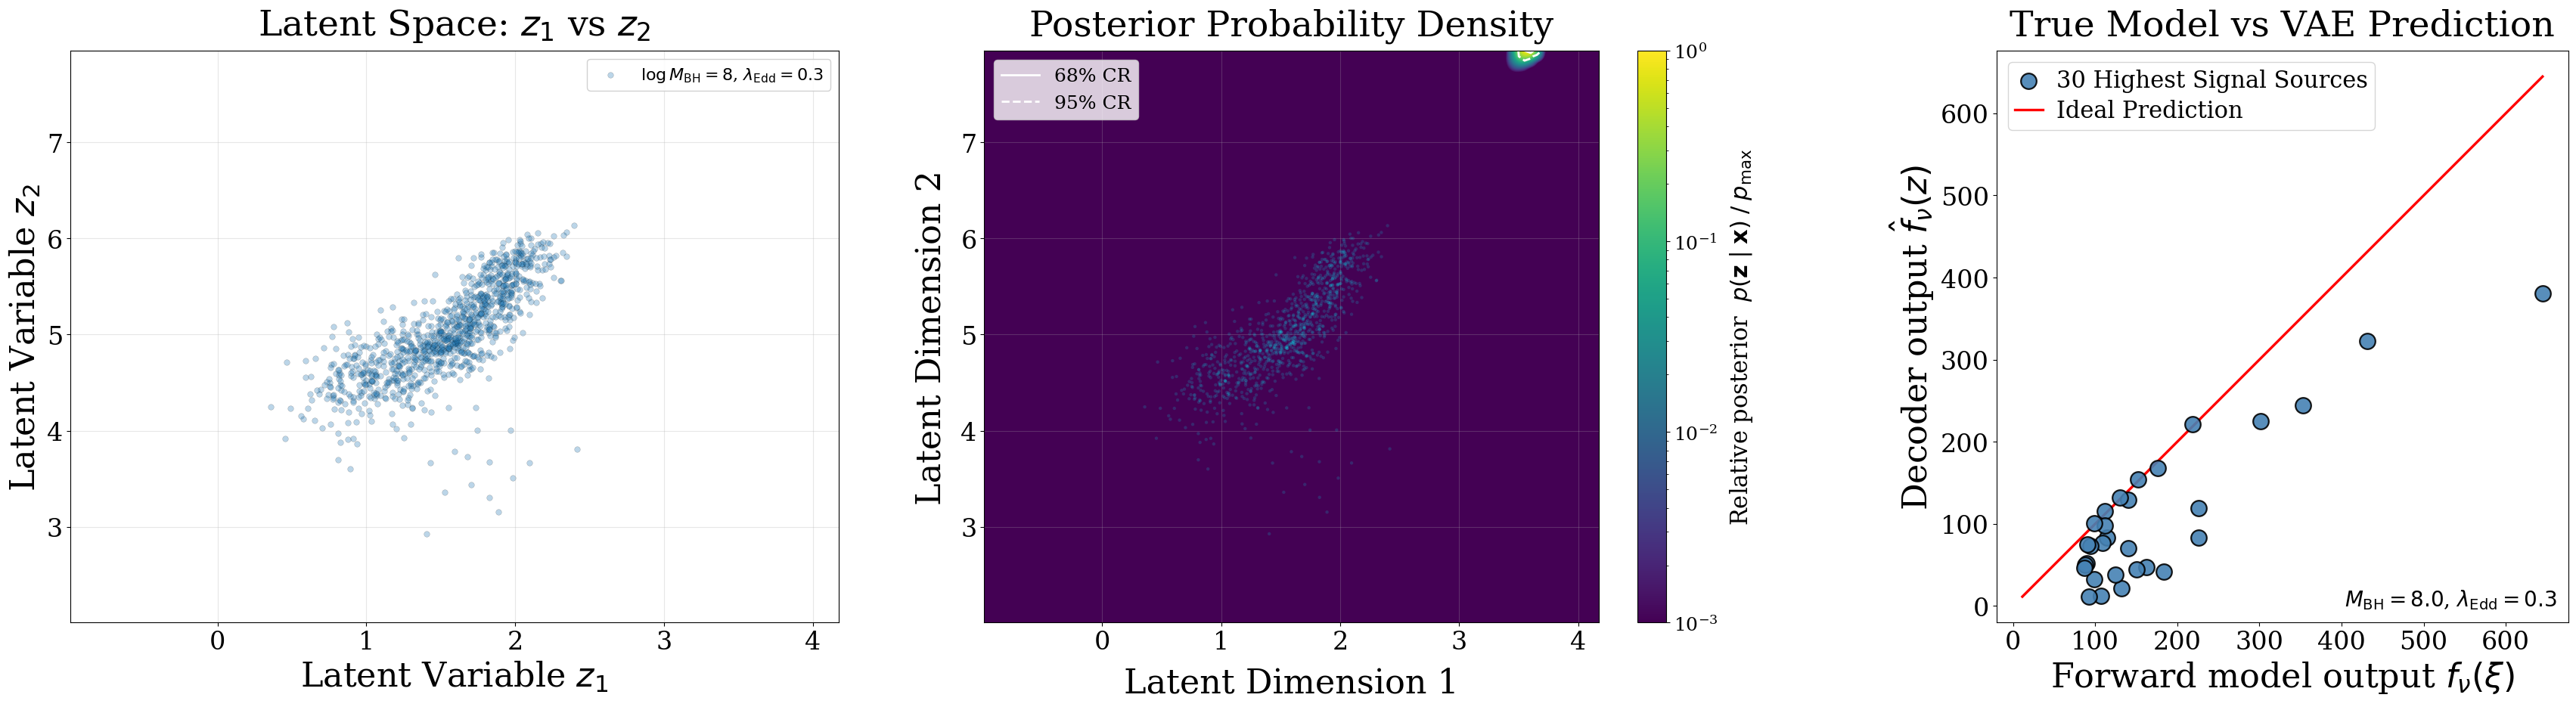


Statistics for Config 1
True Signal (Top 30):
  Mean: 172.9313
  Std: 119.2500
  Min: 86.4333, Max: 644.8669

VAE Prediction (Top 30):
  Mean: 108.9467
  Std: 88.9283
  Min: 11.2810, Max: 380.5753

Difference (VAE - True Model):
  Mean: -63.9845
  Std: 59.3470
  RMSE: 87.2702
  Correlation: 0.8773

Posterior Statistics:
  68% credible level: 0.276028
  95% credible level: 0.025779
  MLE location: (3.601, 7.955)

Processing Config 2: $\log M_{\mathrm{BH}} = 7.7$, $\lambda_{\mathrm{Edd}} = 0.3$
Observed data maps to latent point: (2.518, 4.341)
Computing posterior on scatter-centered grid...
  Progress: 25/100
  Progress: 50/100
  Progress: 75/100
  Progress: 100/100
  Grid MAP (within scatter): (3.564, 6.539)
  Encoder mu_observed:       (2.518, 4.341)
  Scatter center (median):   (2.579, 4.207)
  Odds Ratio (H1 vs H0): ΔlogL=6272.91, TS=12545.83, ratio=~10^2724


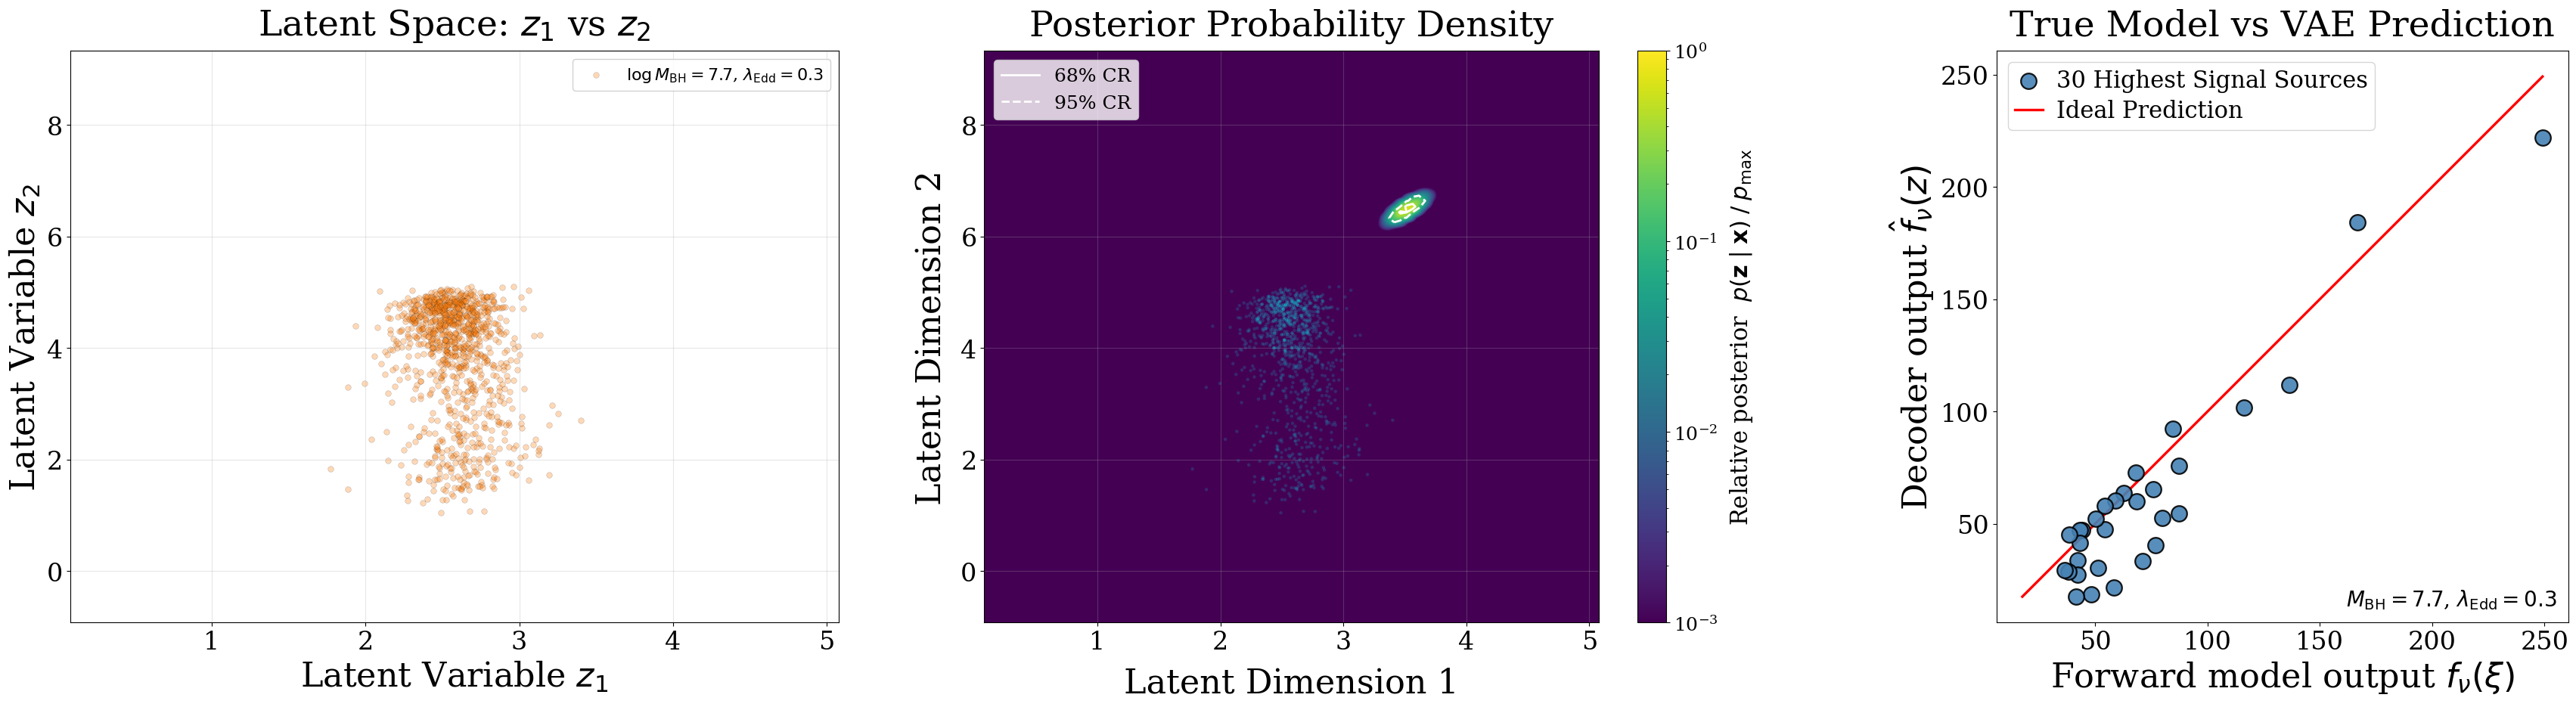


Statistics for Config 2
True Signal (Top 30):
  Mean: 72.4936
  Std: 44.1537
  Min: 36.5604, Max: 249.1765

VAE Prediction (Top 30):
  Mean: 61.2271
  Std: 44.4760
  Min: 17.5171, Max: 221.8793

Difference (VAE - True Model):
  Mean: -11.2664
  Std: 15.0746
  RMSE: 18.8196
  Correlation: 0.9422

Posterior Statistics:
  68% credible level: 0.141554
  95% credible level: 0.012783
  MLE location: (3.564, 6.539)

Processing Config 3: $\log M_{\mathrm{BH}} = 7.3$, $\lambda_{\mathrm{Edd}} = 0.3$
Observed data maps to latent point: (2.858, 4.311)
Computing posterior on scatter-centered grid...
  Progress: 25/100
  Progress: 50/100
  Progress: 75/100
  Progress: 100/100
  Grid MAP (within scatter): (3.692, 6.000)
  Encoder mu_observed:       (2.858, 4.311)
  Scatter center (median):   (2.757, 3.585)
  Odds Ratio (H1 vs H0): ΔlogL=7647.76, TS=15295.52, ratio=~10^3321


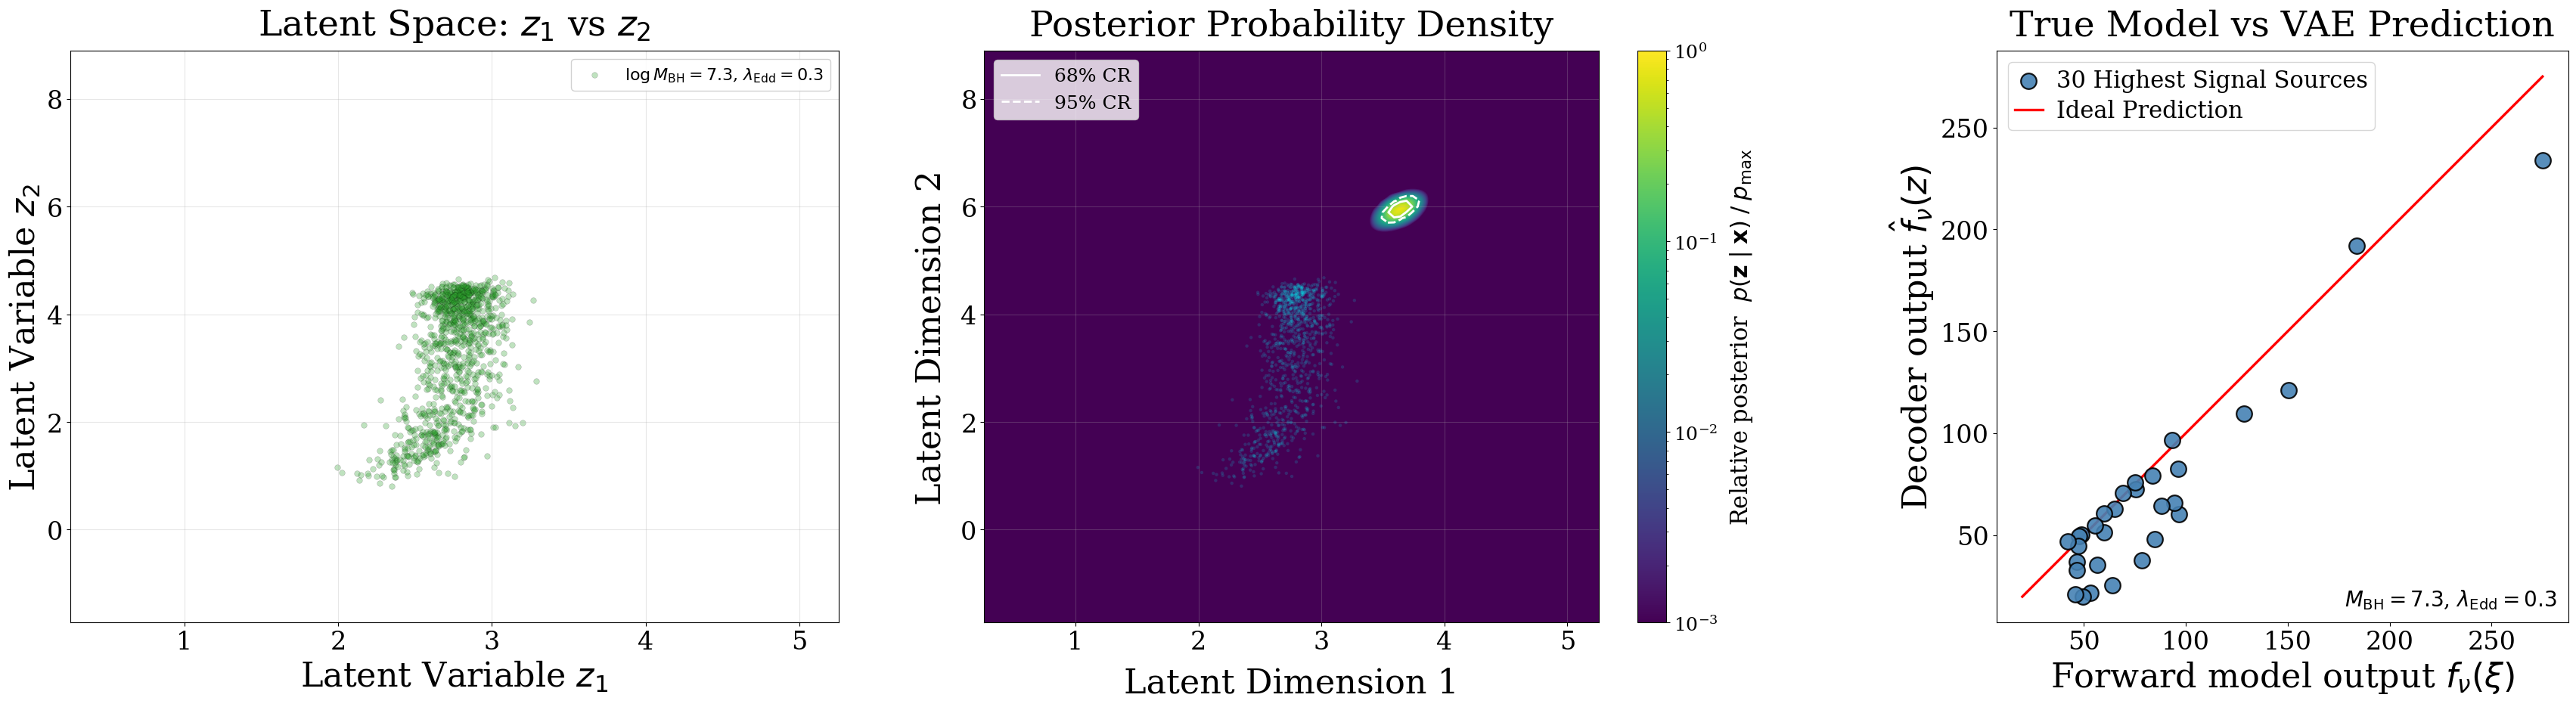


Statistics for Config 3
True Signal (Top 30):
  Mean: 82.0685
  Std: 48.0506
  Min: 42.2520, Max: 275.0309

VAE Prediction (Top 30):
  Mean: 67.4910
  Std: 46.2096
  Min: 19.8312, Max: 233.9280

Difference (VAE - True Model):
  Mean: -14.5775
  Std: 15.6824
  RMSE: 21.4112
  Correlation: 0.9454

Posterior Statistics:
  68% credible level: 0.045363
  95% credible level: 0.009200
  MLE location: (3.692, 6.000)

Processing Config 4: $\log M_{\mathrm{BH}} = 7$, $\lambda_{\mathrm{Edd}} = 0.3$
Observed data maps to latent point: (2.973, 4.171)
Computing posterior on scatter-centered grid...
  Progress: 25/100
  Progress: 50/100
  Progress: 75/100
  Progress: 100/100
  Grid MAP (within scatter): (4.015, 5.871)
  Encoder mu_observed:       (2.973, 4.171)
  Scatter center (median):   (3.030, 3.481)
  Odds Ratio (H1 vs H0): ΔlogL=9025.69, TS=18051.39, ratio=~10^3920


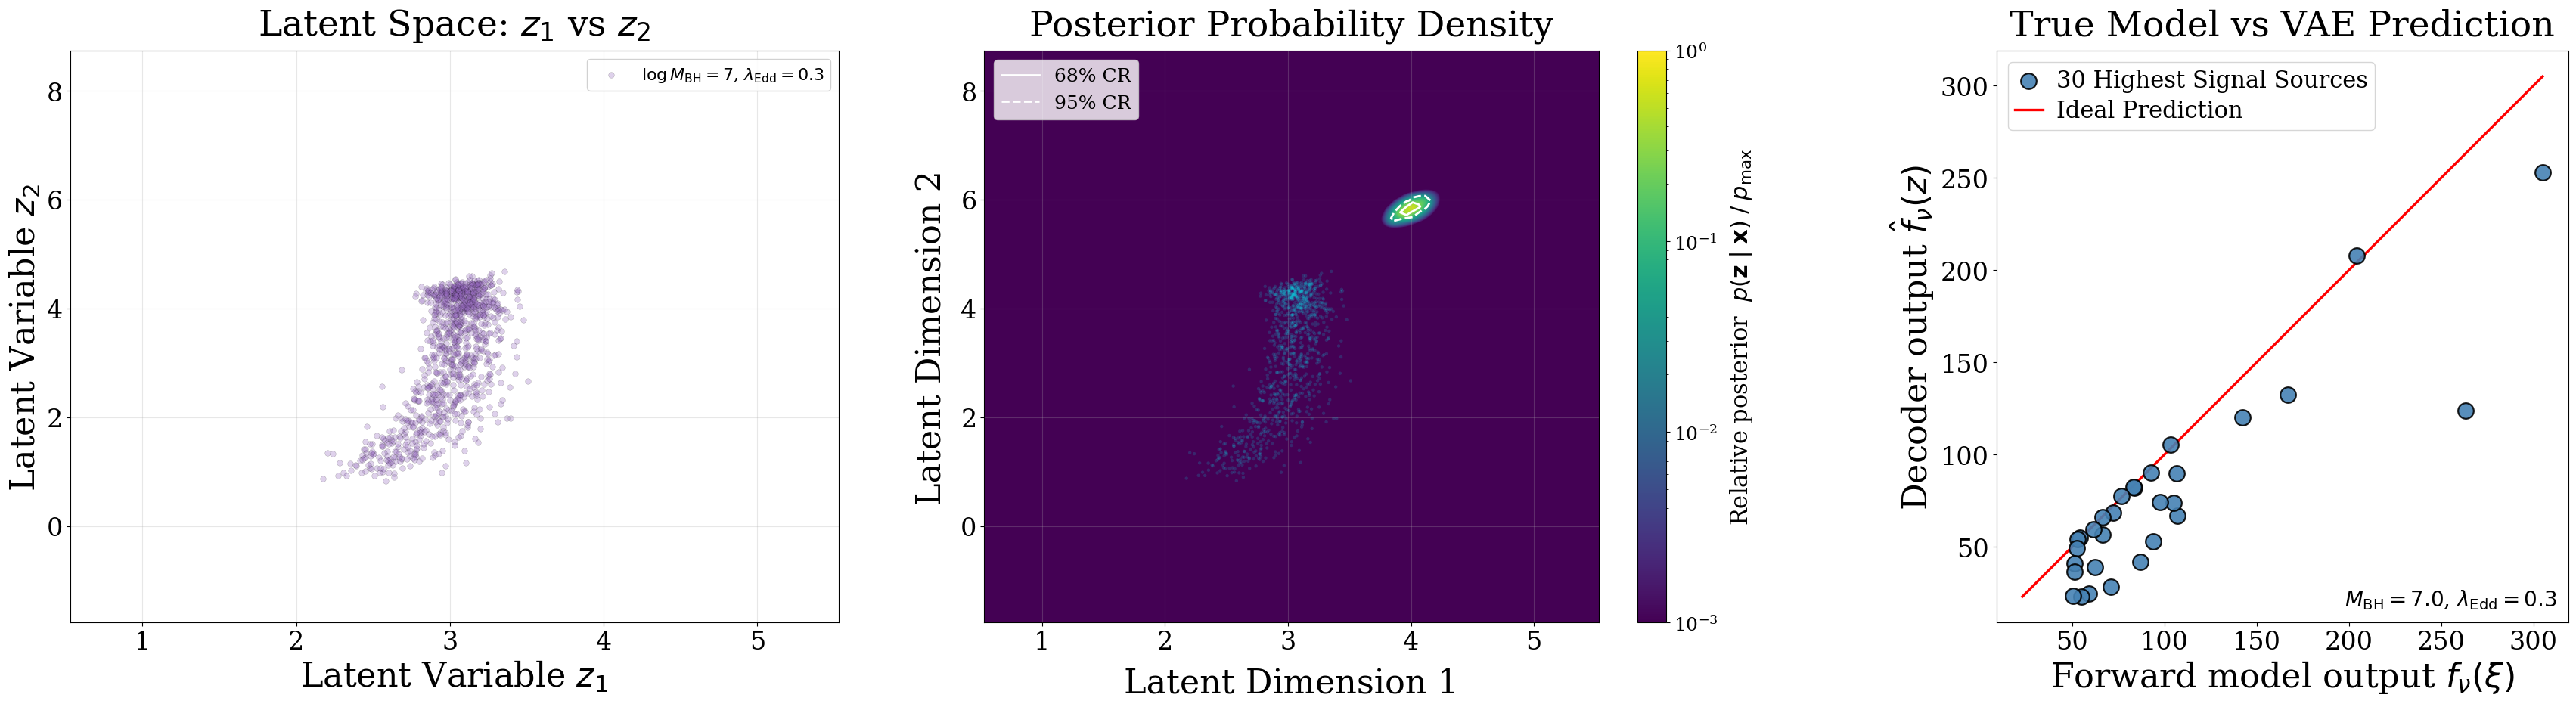


Statistics for Config 4
True Signal (Top 30):
  Mean: 98.1888
  Std: 60.8980
  Min: 50.6690, Max: 304.8903

VAE Prediction (Top 30):
  Mean: 76.6629
  Std: 50.4104
  Min: 23.0195, Max: 253.0730

Difference (VAE - True Model):
  Mean: -21.5259
  Std: 27.5803
  RMSE: 34.9863
  Correlation: 0.8940

Posterior Statistics:
  68% credible level: 0.087113
  95% credible level: 0.010792
  MLE location: (4.015, 5.871)

Processing Config 5: $\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.05$
Observed data maps to latent point: (-1.463, 0.636)
Computing posterior on scatter-centered grid...
  Progress: 25/100
  Progress: 50/100
  Progress: 75/100
  Progress: 100/100
  Grid MAP (within scatter): (-1.313, 0.612)
  Encoder mu_observed:       (-1.463, 0.636)
  Scatter center (median):   (-1.086, 0.971)
  Odds Ratio (H1 vs H0): ΔlogL=657.67, TS=1315.34, ratio=~10^286


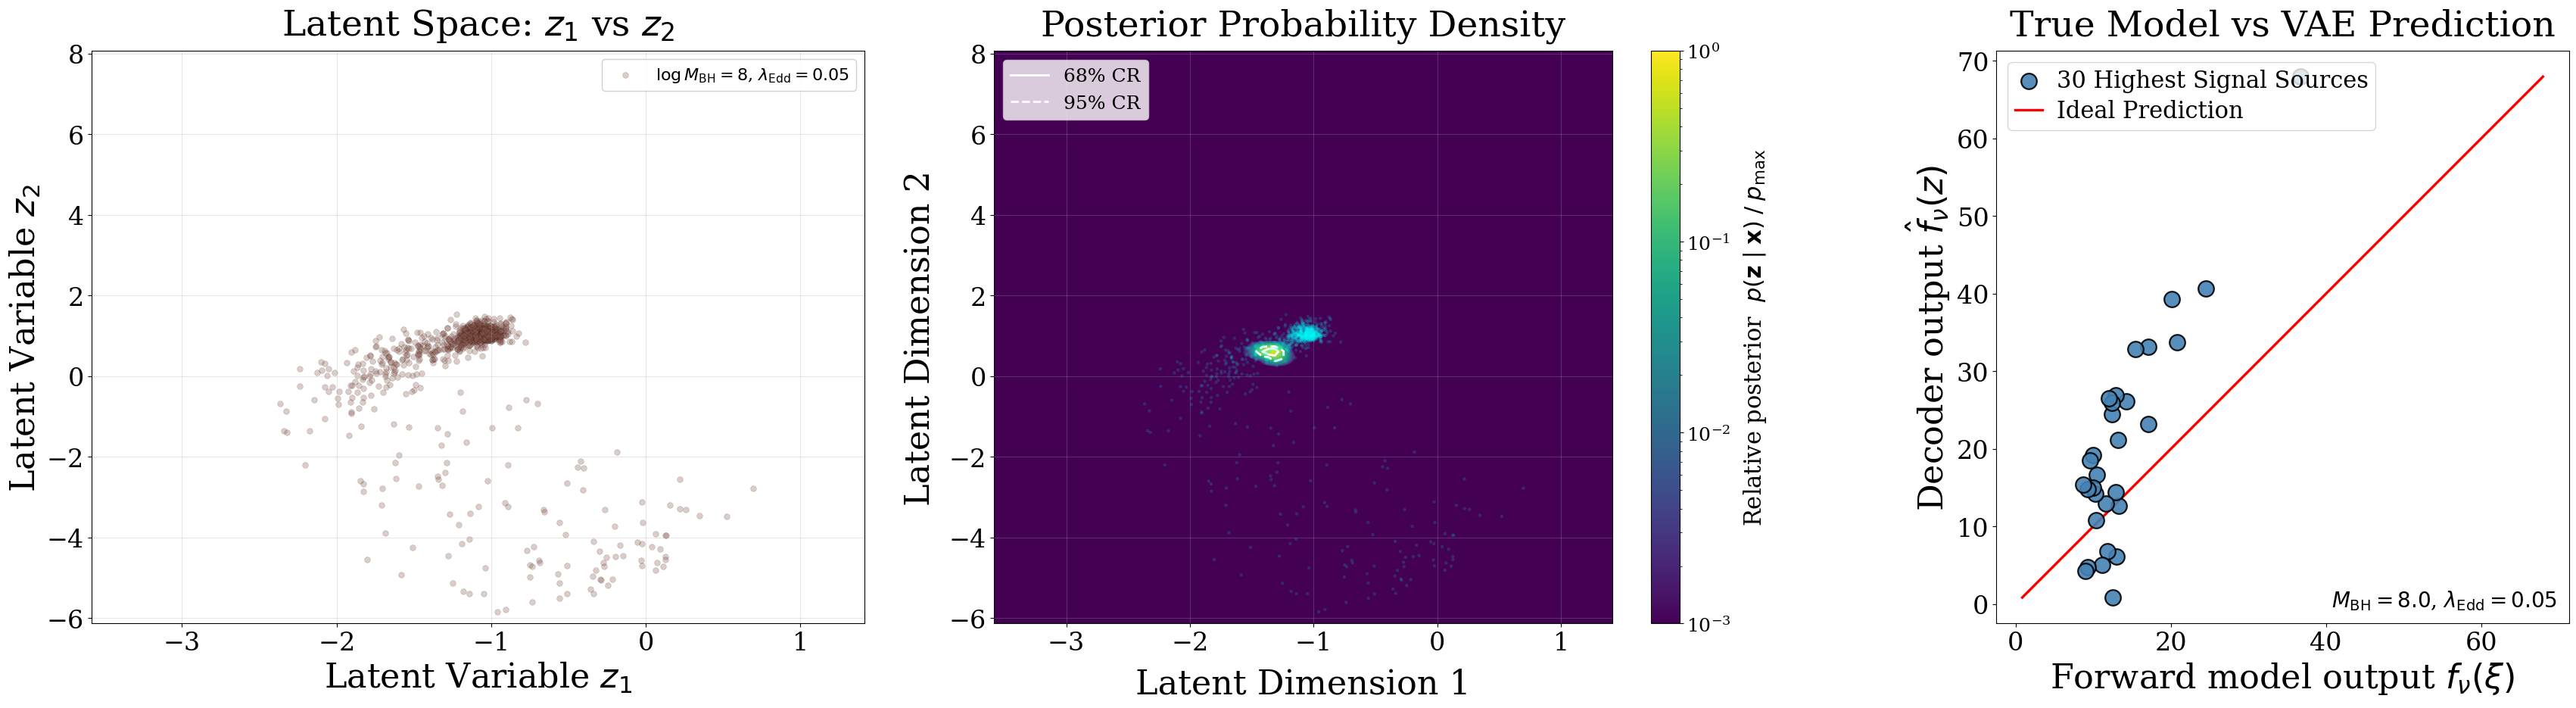


Statistics for Config 5
True Signal (Top 30):
  Mean: 13.7407
  Std: 5.6372
  Min: 8.6807, Max: 36.6981

VAE Prediction (Top 30):
  Mean: 20.4784
  Std: 13.6513
  Min: 0.8457, Max: 67.9741

Difference (VAE - True Model):
  Mean: 6.7376
  Std: 9.2285
  RMSE: 11.4263
  Correlation: 0.8640

Posterior Statistics:
  68% credible level: 0.153829
  95% credible level: 0.030989
  MLE location: (-1.313, 0.612)

Processing Config 6: $\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.1$
Observed data maps to latent point: (-0.516, 2.000)
Computing posterior on scatter-centered grid...
  Progress: 25/100
  Progress: 50/100
  Progress: 75/100
  Progress: 100/100
  Grid MAP (within scatter): (-0.394, 2.499)
  Encoder mu_observed:       (-0.516, 2.000)
  Scatter center (median):   (-0.571, 2.070)
  Odds Ratio (H1 vs H0): ΔlogL=4672.50, TS=9345.00, ratio=~10^2029


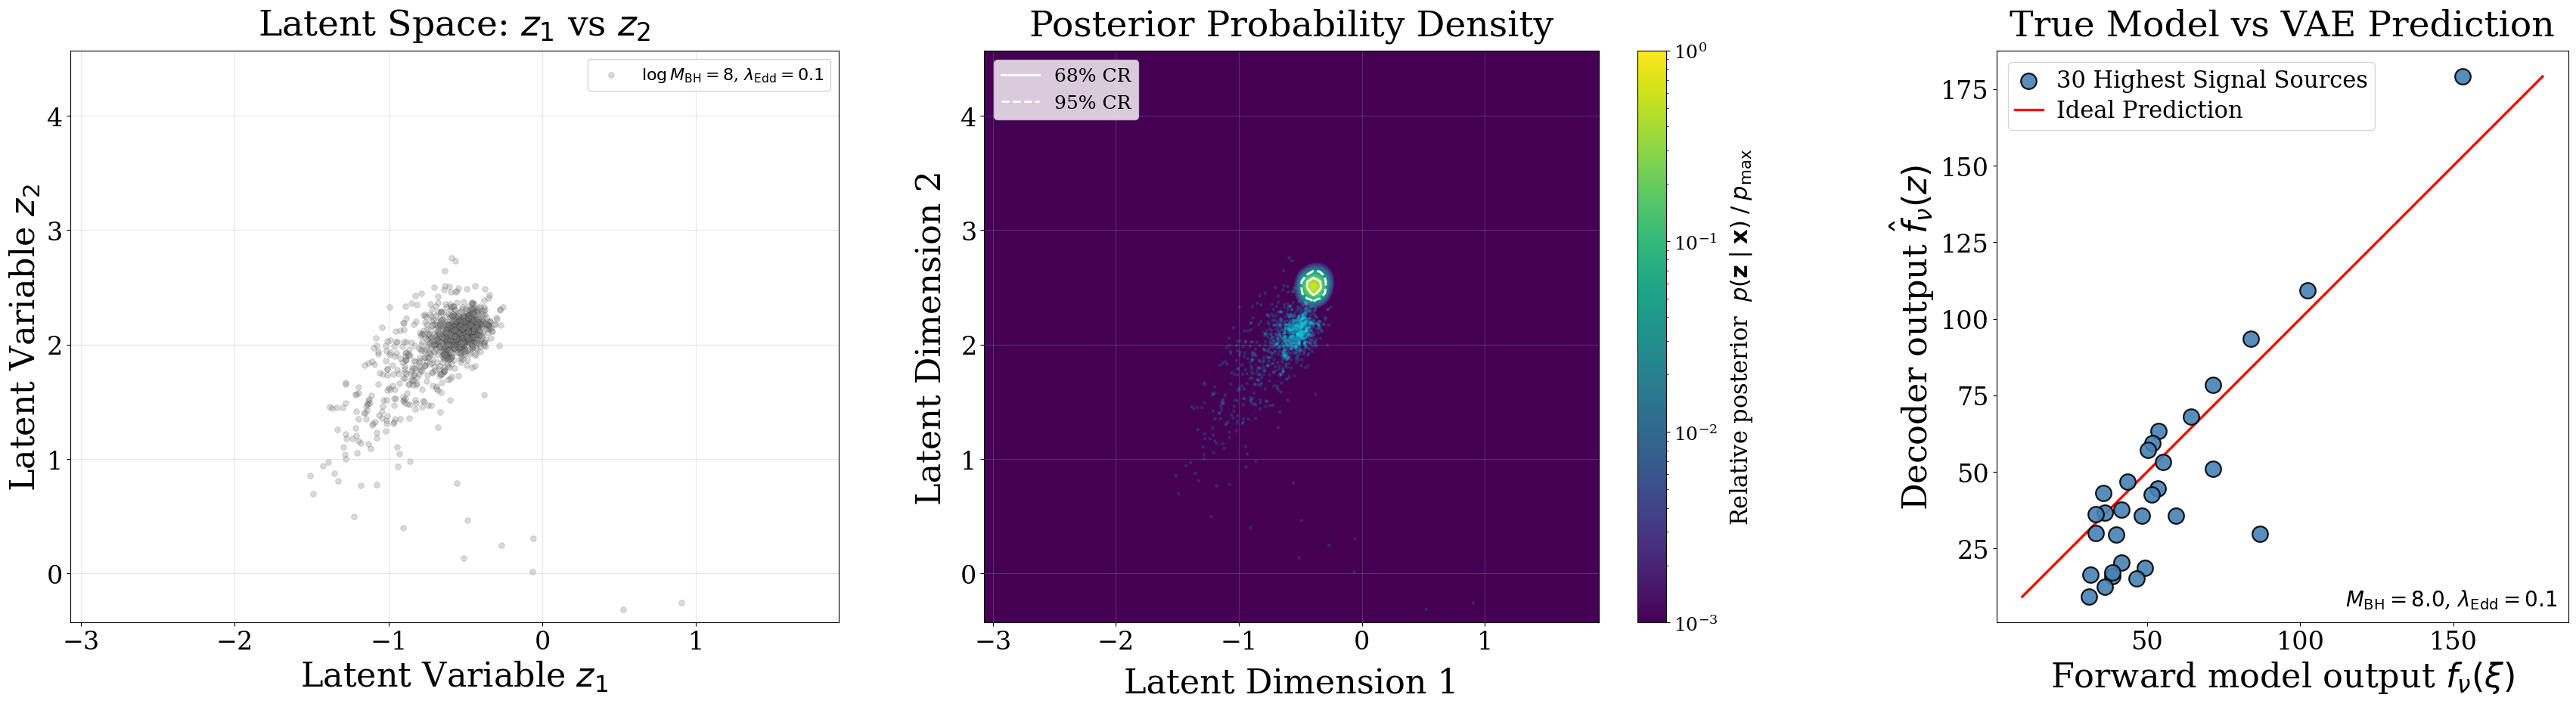


Statistics for Config 6
True Signal (Top 30):
  Mean: 54.4353
  Std: 25.1085
  Min: 30.9305, Max: 152.9188

VAE Prediction (Top 30):
  Mean: 46.1847
  Std: 34.1125
  Min: 9.2442, Max: 179.0957

Difference (VAE - True Model):
  Mean: -8.2506
  Std: 16.7211
  RMSE: 18.6459
  Correlation: 0.8841

Posterior Statistics:
  68% credible level: 0.069395
  95% credible level: 0.008318
  MLE location: (-0.394, 2.499)

Processing Config 7: $\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.2$
Observed data maps to latent point: (0.666, 3.580)
Computing posterior on scatter-centered grid...
  Progress: 25/100
  Progress: 50/100
  Progress: 75/100
  Progress: 100/100
  Grid MAP (within scatter): (1.072, 4.547)
  Encoder mu_observed:       (0.666, 3.580)
  Scatter center (median):   (0.592, 3.461)
  Odds Ratio (H1 vs H0): ΔlogL=3682.11, TS=7364.22, ratio=~10^1599


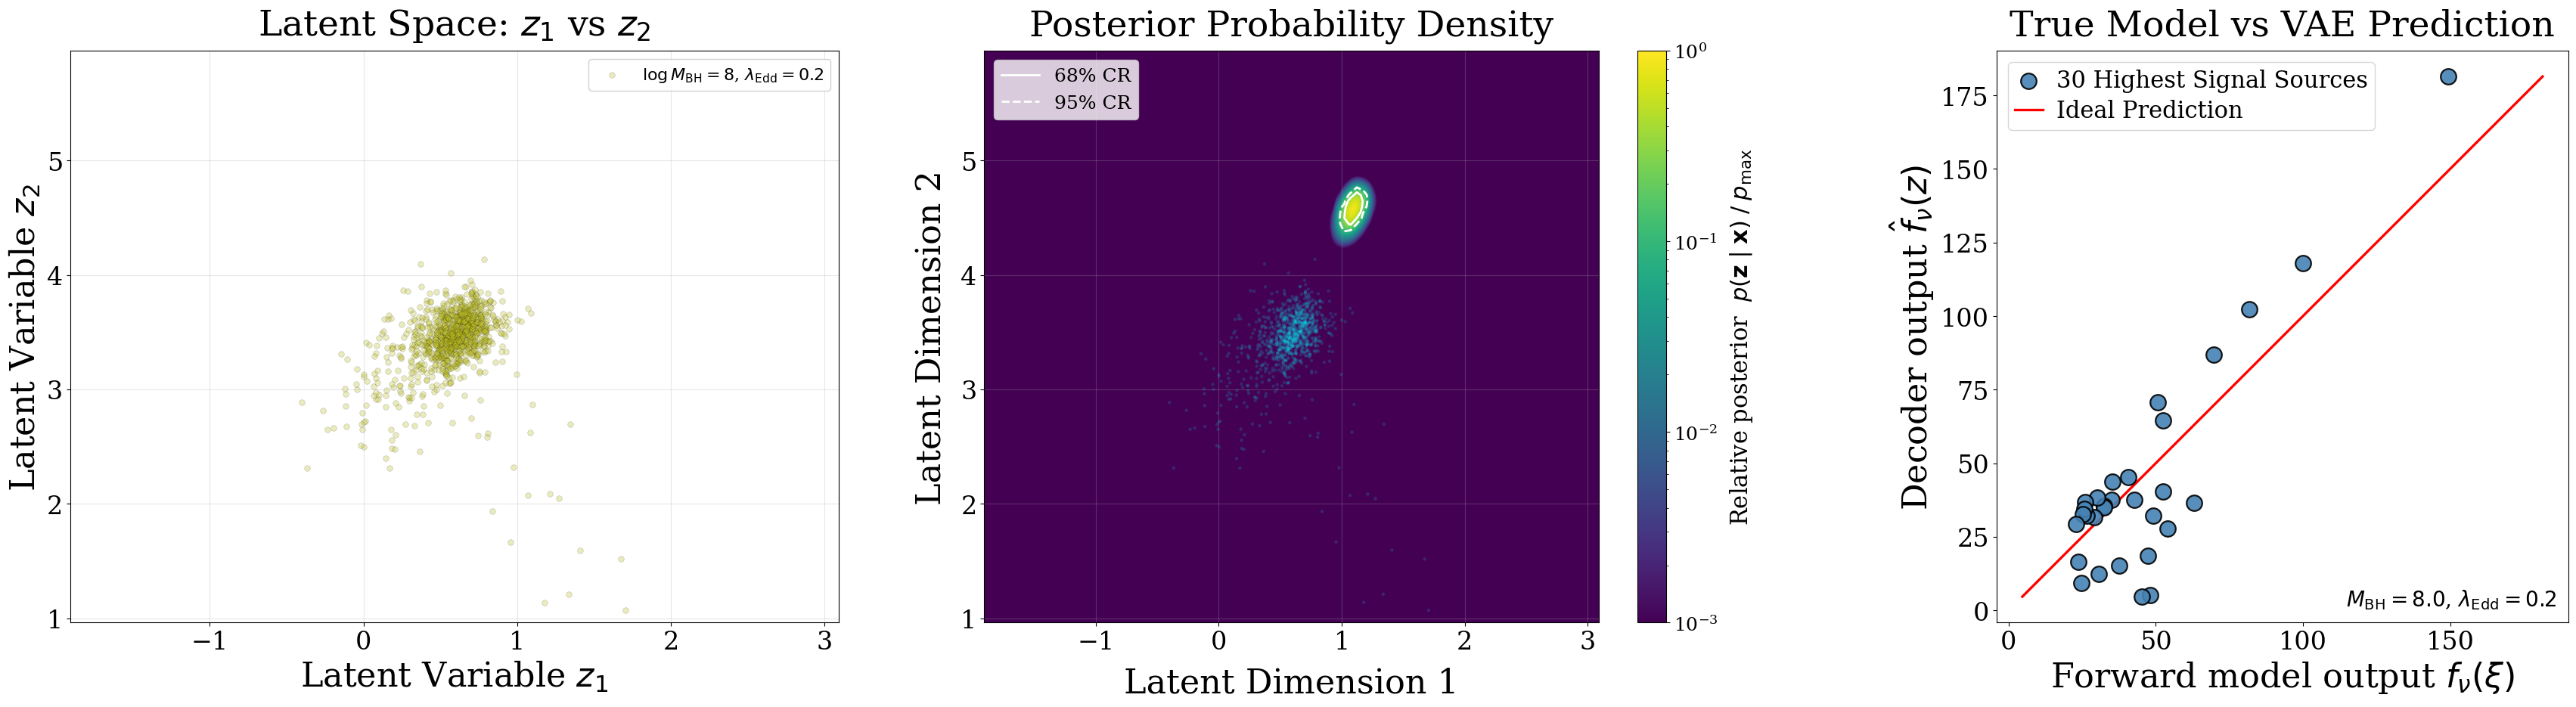


Statistics for Config 7
True Signal (Top 30):
  Mean: 46.1492
  Std: 26.1586
  Min: 22.9620, Max: 149.4664

VAE Prediction (Top 30):
  Mean: 43.7203
  Std: 36.4103
  Min: 4.6536, Max: 181.4172

Difference (VAE - True Model):
  Mean: -2.4289
  Std: 18.4909
  RMSE: 18.6498
  Correlation: 0.8757

Posterior Statistics:
  68% credible level: 0.032742
  95% credible level: 0.009950
  MLE location: (1.072, 4.547)

Processing Config 8: $\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.5$
Observed data maps to latent point: (5.807, 10.298)
Computing posterior on scatter-centered grid...
  Progress: 25/100
  Progress: 50/100
  Progress: 75/100
  Progress: 100/100
  Grid MAP (within scatter): (9.731, 17.667)
  Encoder mu_observed:       (5.807, 10.298)
  Scatter center (median):   (5.040, 8.061)
  Odds Ratio (H1 vs H0): ΔlogL=25891.98, TS=51783.96, ratio=~10^11245


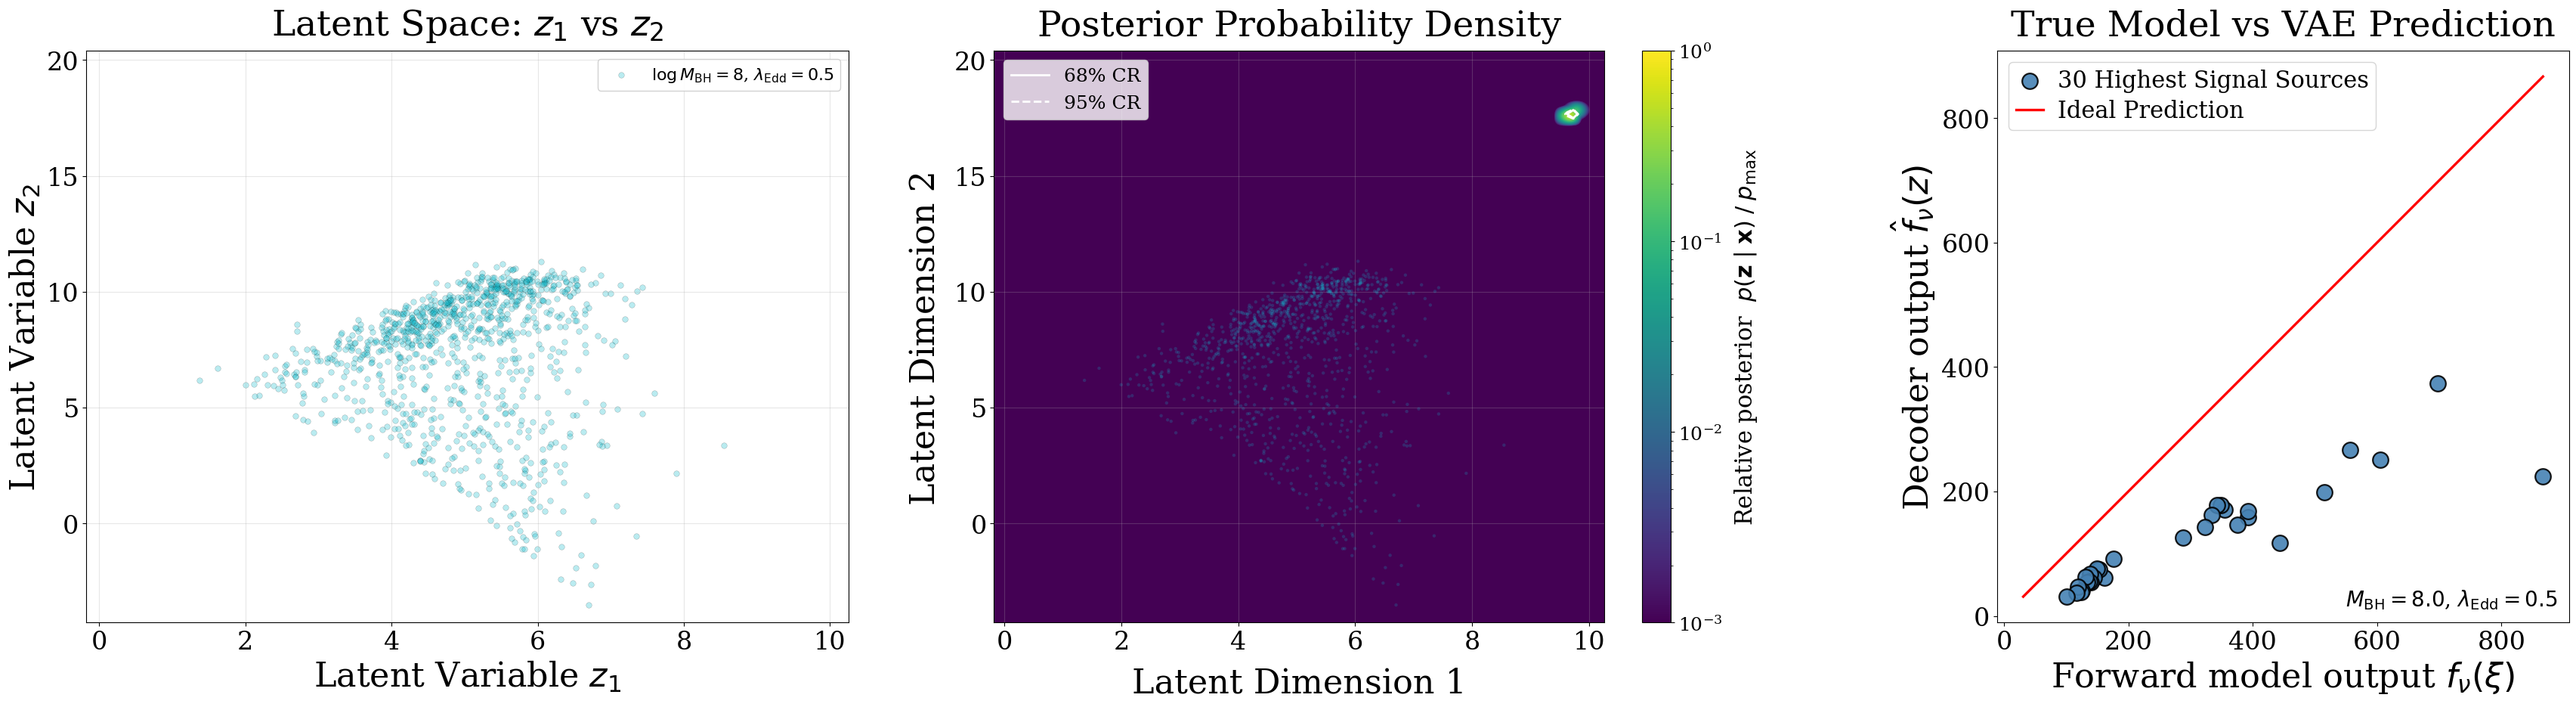


Statistics for Config 8
True Signal (Top 30):
  Mean: 296.2511
  Std: 195.0870
  Min: 101.2881, Max: 866.8268

VAE Prediction (Top 30):
  Mean: 123.9331
  Std: 81.4323
  Min: 31.0365, Max: 373.1718

Difference (VAE - True Model):
  Mean: -172.3180
  Std: 125.9453
  RMSE: 213.4378
  Correlation: 0.9073

Posterior Statistics:
  68% credible level: 0.201280
  95% credible level: 0.137919
  MLE location: (9.731, 17.667)

All 8 configurations processed

Summary Table
Config       Parameters                                    Corr       RMSE       MLE (z1, z2)        
----------------------------------------------------------------------
Config 1     MBH=8.0, Edd=0.3                              0.8773     87.2702    (3.601, 7.955)
Config 2     MBH=7.7, Edd=0.3                              0.9422     18.8196    (3.564, 6.539)
Config 3     MBH=7.3, Edd=0.3                              0.9454     21.4112    (3.692, 6.000)
Config 4     MBH=7.0, Edd=0.3                              0.8940     3

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import LogNorm, Normalize
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 28,
    'legend.fontsize': 22,
    'figure.titlesize': 40
})

print("=" * 60)
print("M_BH and λ_Edd Configurations — 3-Panel Analysis")
print("=" * 60)

# 4 MBH configs with same lambda_Edd = 0.3
# + 4 Edd ratio configs with same M_BH = 8
mbh_configs = [
    (8.0, 0.3, r'$\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.3$'),
    (7.7, 0.3, r'$\log M_{\mathrm{BH}} = 7.7$, $\lambda_{\mathrm{Edd}} = 0.3$'),
    (7.3, 0.3, r'$\log M_{\mathrm{BH}} = 7.3$, $\lambda_{\mathrm{Edd}} = 0.3$'),
    (7.0, 0.3, r'$\log M_{\mathrm{BH}} = 7$, $\lambda_{\mathrm{Edd}} = 0.3$'),
    (8.0, 0.05, r'$\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.05$'),
    (8.0, 0.1,  r'$\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.1$'),
    (8.0, 0.2,  r'$\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.2$'),
    (8.0, 0.5,  r'$\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.5$'),
]

norm_val = [1000, 10000]
bg = 2.0

colors = plt.cm.tab10(np.linspace(0, 1, len(mbh_configs)))

autoencoder.eval()
feature_cols = ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']

all_results = []

for config_idx, (mbh_thres, e_ratio_thres, label) in enumerate(mbh_configs):
    print(f"\n{'='*60}")
    print(f"Processing Config {config_idx+1}: {label}")
    print(f"{'='*60}")

    # left panel data: scatter cloud in latent space
    fm_dataset = CatalogFMSampleDataset(
        spiders_catalog, logmbh=mbh_thres, eddratio=e_ratio_thres,
        norm=[1000, 10000], bg=2, nsamples=1024, device="cpu"
    )
    fm_loader = torch.utils.data.DataLoader(fm_dataset, batch_size=128, shuffle=False)

    scatter_results = []
    device = torch.device(run_on)
    for X, y in fm_loader:
        X = X.to(device, non_blocking=True)
        with torch.no_grad():
            enc_out = encoder.forward(X)
            mu = enc_out[:, :encoder.latent_dim]
            logvar = enc_out[:, encoder.latent_dim:]
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            z = mu + eps * std  # reparameterize to match training
        scatter_results.append(z.detach().cpu().numpy())
    scatter_results = np.vstack(scatter_results)

    # observed counts (single Poisson realization)
    observed_counts, signal_obs, bg_val = create_realization(
        spiders_catalog, mbh_thres, e_ratio_thres, norm=norm_val, bg=bg
    )
    observed_counts = observed_counts.astype(np.float32)

    # map observed to latent space
    X_features = torch.as_tensor(spiders_catalog[feature_cols].values, dtype=torch.float32, device=run_on)
    log1p_observed = torch.as_tensor(np.log1p(observed_counts), dtype=torch.float32, device=run_on)
    X_input = torch.cat([X_features, log1p_observed.unsqueeze(1)], dim=1).unsqueeze(0)

    with torch.no_grad():
        encoder_output = encoder.forward(X_input)
        mu_observed = encoder_output[:, :encoder.latent_dim].cpu().numpy()[0]

    print(f"Observed data maps to latent point: ({mu_observed[0]:.3f}, {mu_observed[1]:.3f})")

    # build grid centered on the scatter cloud
    # The decoder was trained on z-values the encoder produces, so the posterior
    # must be evaluated in the encoder's operating region (= scatter cloud)
    all_z1 = np.concatenate([scatter_results[:, 0], [mu_observed[0]]])
    all_z2 = np.concatenate([scatter_results[:, 1], [mu_observed[1]]])
    z1_center = np.median(all_z1)
    z2_center = np.median(all_z2)
    z1_spread = max(np.std(all_z1) * 4, 1.5)
    z2_spread = max(np.std(all_z2) * 4, 1.5)

    # single-pass fine grid centered on the scatter cloud (not on a distant MLE)
    ngrid = 100
    grid_margin = 1.0  # small margin beyond scatter extent
    latent_dim1_range = np.linspace(z1_center - z1_spread - grid_margin,
                                    z1_center + z1_spread + grid_margin, ngrid)
    latent_dim2_range = np.linspace(z2_center - z2_spread - grid_margin,
                                    z2_center + z2_spread + grid_margin, ngrid)
    LATENT_DIM1_grid, LATENT_DIM2_grid = np.meshgrid(latent_dim1_range, latent_dim2_range)

    log_likelihood_grid_latent = np.zeros_like(LATENT_DIM1_grid)
    print("Computing posterior on scatter-centered grid...")
    for i, z1 in enumerate(latent_dim1_range):
        if (i + 1) % 25 == 0:
            print(f"  Progress: {i+1}/{len(latent_dim1_range)}")
        for j, z2 in enumerate(latent_dim2_range):
            mu_latent = torch.tensor([[z1, z2]], dtype=torch.float32, device=run_on)
            with torch.no_grad():
                out = decoder.net(mu_latent)
                out_clamped = out.clamp(min=0.0, max=20.0)
                predicted_counts = (torch.exp(out_clamped) - 1).cpu().numpy().flatten()
            lam = predicted_counts + bg
            # normalize predicted to match total observed counts (same as training loss)
            n_obs_total = observed_counts.sum()
            n_exp_total = lam.sum()
            if n_exp_total > 0:
                lam = lam * (n_obs_total / n_exp_total)
            lam = np.clip(lam, 1e-20, None)
            log_prior = -0.5 * (z1**2 + z2**2)  # N(0,1) VAE prior
            log_likelihood_grid_latent[j, i] = np.sum(observed_counts * np.log(lam) - lam) + log_prior

    raw_max_ll = log_likelihood_grid_latent.max()
    log_likelihood_grid_latent -= raw_max_ll

    best_idx = np.unravel_index(np.argmax(log_likelihood_grid_latent), log_likelihood_grid_latent.shape)
    best_z1 = LATENT_DIM1_grid[best_idx]
    best_z2 = LATENT_DIM2_grid[best_idx]
    print(f"  Grid MAP (within scatter): ({best_z1:.3f}, {best_z2:.3f})")
    print(f"  Encoder mu_observed:       ({mu_observed[0]:.3f}, {mu_observed[1]:.3f})")
    print(f"  Scatter center (median):   ({z1_center:.3f}, {z2_center:.3f})")

    posterior_unnorm_latent = np.exp(log_likelihood_grid_latent)
    posterior_latent = posterior_unnorm_latent / np.sum(posterior_unnorm_latent)

    # Odds Ratio: H1 (signal+background) vs H0 (background-only)
    n_sources = len(observed_counts)
    lam_bkg = np.full(n_sources, observed_counts.sum() / n_sources)
    lam_bkg = np.clip(lam_bkg, 1e-20, None)
    log_L_bkg = np.sum(observed_counts * np.log(lam_bkg) - lam_bkg)
    log_prior_at_mle = -0.5 * (best_z1**2 + best_z2**2)
    log_L_H1 = raw_max_ll - log_prior_at_mle
    delta_log_L = log_L_H1 - log_L_bkg
    print(f"  Odds Ratio (H1 vs H0): \u0394logL={delta_log_L:.2f}, TS={2*delta_log_L:.2f}", end="")
    if delta_log_L < 500:
        print(f", ratio={np.exp(delta_log_L):.2e}")
    else:
        print(f", ratio=~10^{delta_log_L/np.log(10):.0f}")

    flat = posterior_latent.flatten()
    sorted_flat = np.sort(flat)[::-1]
    cumulative = np.cumsum(sorted_flat)
    level_68 = sorted_flat[np.searchsorted(cumulative, 0.68)]
    level_95 = sorted_flat[np.searchsorted(cumulative, 0.95)]

    # right panel data: true vs VAE predicted (with normalization)
    # use signal_obs from create_realization (already properly normalized)
    true_signal = signal_obs
    true_counts = true_signal + bg

    log1p_true_counts = torch.as_tensor(np.log1p(true_counts), dtype=torch.float32, device=run_on)
    X_input_true = torch.cat([X_features, log1p_true_counts.unsqueeze(1)], dim=1).unsqueeze(0)

    with torch.no_grad():
        output, mu_pred, logvar_pred = autoencoder(X_input_true)
        predicted_signal = output.cpu().numpy().flatten()

        # normalize predicted signal to match total observed counts (same as poisson_loss)
        k = torch.exp(X_input_true[..., -1]) - 1
        k_np = k.cpu().numpy().flatten()
        lam_pred = predicted_signal + bg
        n_obs = k_np.sum()
        n_exp = lam_pred.sum()
        if n_exp > 0:
            lam_normalized = lam_pred * (n_obs / n_exp)
            predicted_signal_np = lam_normalized - bg
        else:
            predicted_signal_np = predicted_signal

    true_signal_np = np.array(true_signal)

    top_30_indices = np.argsort(true_signal_np)[-30:][::-1]
    true_signal_top30 = true_signal_np[top_30_indices]
    predicted_signal_top30 = predicted_signal_np[top_30_indices]

    # plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(36, 10))

    #left: latent space scatter
    ax1.scatter(scatter_results[:, 0], scatter_results[:, 1],
                alpha=0.3, s=30, color=colors[config_idx],
                edgecolors='black', linewidths=0.3, label=label)
    ax1.set_xlim(latent_dim1_range[0], latent_dim1_range[-1])
    ax1.set_ylim(latent_dim2_range[0], latent_dim2_range[-1])
    ax1.set_xlabel(r'Latent Variable $z_1$', fontsize=32)
    ax1.set_ylabel(r'Latent Variable $z_2$', fontsize=32)
    ax1.set_title(f'Latent Space: $z_1$ vs $z_2$', fontsize=34, pad=15)
    ax1.legend(loc='best', fontsize=16, framealpha=0.9)
    ax1.tick_params(axis='both', which='major', labelsize=24)
    ax1.grid(True, alpha=0.3)

    # middle: posterior with contours
    posterior_normalized = posterior_latent / posterior_latent.max()
    posterior_normalized = np.clip(posterior_normalized, 1e-6, 1.0)

    im = ax2.imshow(
        posterior_normalized,
        origin='lower',
        extent=[latent_dim1_range.min(), latent_dim1_range.max(),
                latent_dim2_range.min(), latent_dim2_range.max()],
        cmap='viridis',
        norm=LogNorm(vmin=1e-3, vmax=1.0),
        aspect='auto',
        interpolation='bicubic'
    )

    # credible contours
    ax2.contour(
        LATENT_DIM1_grid, LATENT_DIM2_grid,
        posterior_latent,
        levels=[level_68],
        colors='white',
        linewidths=2.0,
        linestyles='solid',
    )
    ax2.contour(
        LATENT_DIM1_grid, LATENT_DIM2_grid,
        posterior_latent,
        levels=[level_95],
        colors='white',
        linewidths=2.0,
        linestyles='dashed',
    )

    # overlay the scatter cloud on the posterior panel so overlap is visible
    ax2.scatter(scatter_results[:, 0], scatter_results[:, 1],
                alpha=0.15, s=10, color='cyan', edgecolors='none', zorder=4)

    ax2.set_xlim(latent_dim1_range[0], latent_dim1_range[-1])
    ax2.set_ylim(latent_dim2_range[0], latent_dim2_range[-1])

    ax2.set_xlabel('Latent Dimension 1', fontsize=32, labelpad=12)
    ax2.set_ylabel('Latent Dimension 2', fontsize=32, labelpad=12)
    ax2.set_title('Posterior Probability Density', fontsize=34, pad=15)
    ax2.tick_params(axis='both', which='major', labelsize=24)
    ax2.grid(True, alpha=0.25)

    # legend
    legend_lines = [
        Line2D([0], [0], color='white', lw=2, linestyle='solid', label='68% CR'),
        Line2D([0], [0], color='white', lw=2, linestyle='dashed', label='95% CR'),
    ]
    ax2.legend(handles=legend_lines, loc='upper left', fontsize=18)

    cbar = plt.colorbar(im, ax=ax2)
    cbar.ax.tick_params(labelsize=18)
    cbar.set_label(r'Relative posterior  $p(\mathbf{z} \mid \mathbf{x}) \;/\; p_{\mathrm{max}}$',
                   fontsize=22, labelpad=10)

    # right: True vs Predicted
    ax3.scatter(
        true_signal_top30,
        predicted_signal_top30,
        s=220,
        color='steelblue',
        edgecolor='black',
        linewidth=1.6,
        alpha=0.9,
        zorder=3,
        label="30 Highest Signal Sources"
    )

    min_val = min(true_signal_top30.min(), predicted_signal_top30.min())
    max_val = max(true_signal_top30.max(), predicted_signal_top30.max())
    ax3.plot(
        [min_val, max_val], [min_val, max_val],
        linestyle='-', linewidth=2.4, color='red',
        zorder=2, label="Ideal Prediction"
    )

    ax3.set_xlabel(r'Forward model output $f_\nu(\xi)$', fontsize=32)
    ax3.set_ylabel(r'Decoder output $\hat{f}_\nu(z)$', fontsize=32)
    ax3.set_title('True Model vs VAE Prediction', fontsize=34, pad=15)

    ax3.legend(
        frameon=True,
        borderpad=0.3,
        handlelength=1.2,
        handletextpad=0.6,
        labelspacing=0.3,
        fontsize=22,
        loc='upper left'
    )

    param_text = rf'$M_{{\rm BH}} = {mbh_thres}$' + ', ' + rf'$\lambda_{{\rm Edd}} = {e_ratio_thres}$'
    ax3.text(0.98, 0.02, param_text, transform=ax3.transAxes,
             fontsize=20, horizontalalignment='right', verticalalignment='bottom')

    ax3.grid(False)
    ax3.ticklabel_format(style='plain')
    ax3.set_aspect('equal', adjustable='box')
    ax3.tick_params(axis='both', which='major', labelsize=24)

    correlation = np.corrcoef(true_signal_top30, predicted_signal_top30)[0, 1]

    plt.tight_layout()
    plt.show()

    # print stats
    print(f"\nStatistics for Config {config_idx+1}")
    print(f"True Signal (Top 30):")
    print(f"  Mean: {np.mean(true_signal_top30):.4f}")
    print(f"  Std: {np.std(true_signal_top30):.4f}")
    print(f"  Min: {np.min(true_signal_top30):.4f}, Max: {np.max(true_signal_top30):.4f}")
    print(f"\nVAE Prediction (Top 30):")
    print(f"  Mean: {np.mean(predicted_signal_top30):.4f}")
    print(f"  Std: {np.std(predicted_signal_top30):.4f}")
    print(f"  Min: {np.min(predicted_signal_top30):.4f}, Max: {np.max(predicted_signal_top30):.4f}")

    difference_top30 = predicted_signal_top30 - true_signal_top30
    print(f"\nDifference (VAE - True Model):")
    print(f"  Mean: {np.mean(difference_top30):.4f}")
    print(f"  Std: {np.std(difference_top30):.4f}")
    print(f"  RMSE: {np.sqrt(np.mean(difference_top30**2)):.4f}")
    print(f"  Correlation: {correlation:.4f}")

    print(f"\nPosterior Statistics:")
    print(f"  68% credible level: {level_68:.6f}")
    print(f"  95% credible level: {level_95:.6f}")
    print(f"  MLE location: ({best_z1:.3f}, {best_z2:.3f})")

    all_results.append({
        'config_label': label,
        'mbh_thres': mbh_thres,
        'e_ratio_thres': e_ratio_thres,
        'mu_observed': mu_observed,
        'best_z': (best_z1, best_z2),
        'scatter_results': scatter_results.copy(),
        'posterior_latent': posterior_latent.copy(),
        'latent_dim1_range': latent_dim1_range.copy(),
        'latent_dim2_range': latent_dim2_range.copy(),
        'true_signal_top30': true_signal_top30.copy(),
        'predicted_signal_top30': predicted_signal_top30.copy(),
        'correlation': correlation,
        'rmse': np.sqrt(np.mean(difference_top30**2)),
        'delta_log_L': delta_log_L,
        'log_L_bkg': log_L_bkg,
        'log_L_H1': log_L_H1,
    })

print(f"\n{'='*60}")
print(f"All {len(mbh_configs)} configurations processed")
print(f"{'='*60}")

# summary table
print("\n" + "="*70)
print("Summary Table")
print("="*70)
print(f"{'Config':<12} {'Parameters':<45} {'Corr':<10} {'RMSE':<10} {'MLE (z1, z2)':<20}")
print("-"*70)
for idx, result in enumerate(all_results):
    corr = result['correlation']
    rmse = result['rmse']
    mle = result['best_z']
    lbl = f"MBH={mbh_configs[idx][0]}, Edd={mbh_configs[idx][1]}"
    print(f"Config {idx+1:<5} {lbl:<45} {corr:<10.4f} {rmse:<10.4f} ({mle[0]:.3f}, {mle[1]:.3f})")

print(f"\n✓ {len(all_results)} configurations analysis complete!")

Saved: figures/step_model/overlay_mbh80_edd03.png
  Config 1: M_BH=8.0, λ_Edd=0.3
    log L(bkg)=10336.89  log L(H1)=26197.60  Δ log L=15860.71
    TS=31721.43  Odds=~10^6888  σ=178.1  Corr=0.8773  RMSE=87.2702



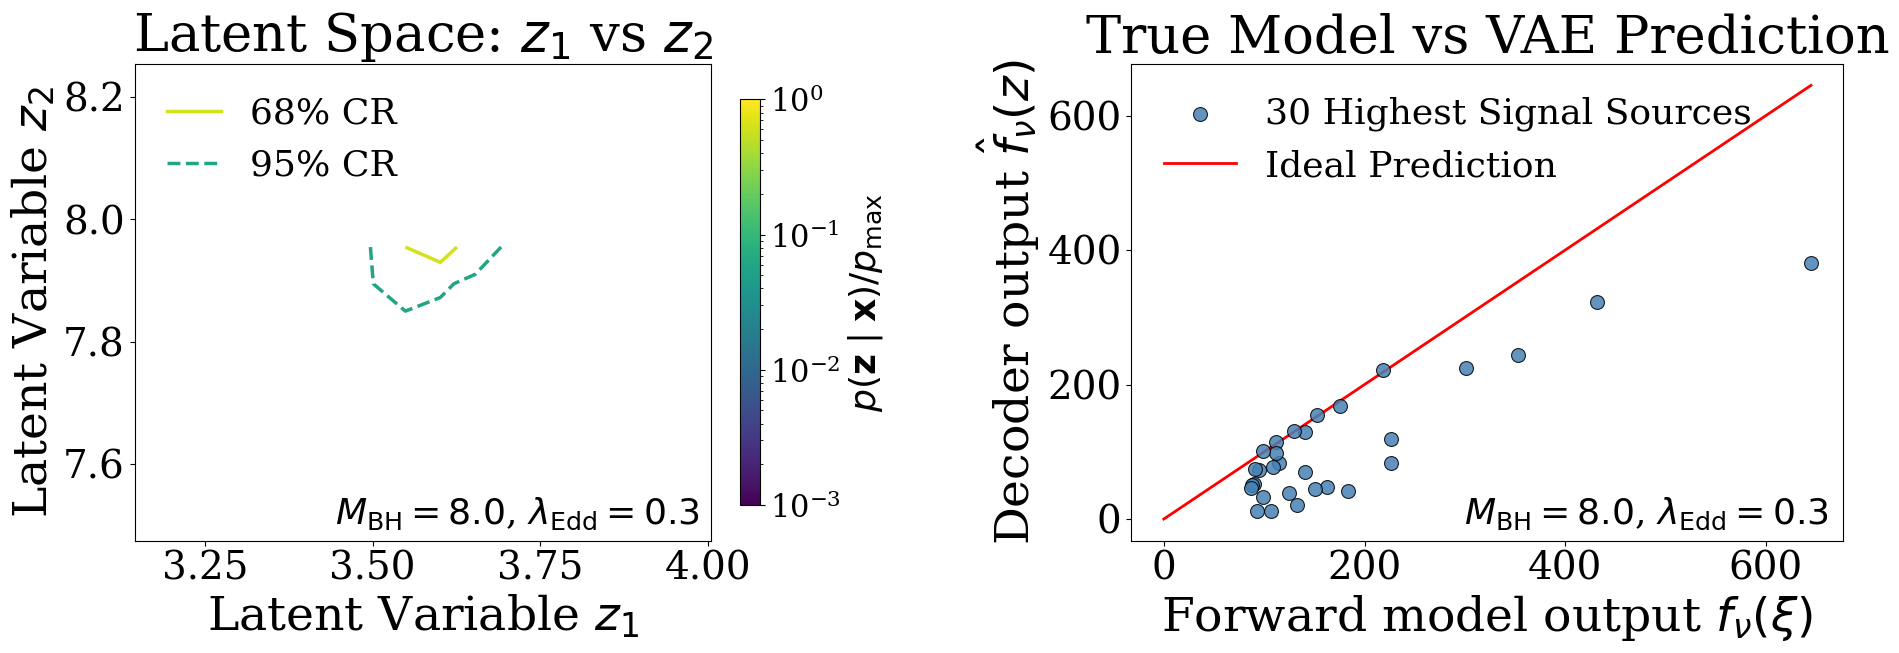

Saved: figures/step_model/overlay_mbh77_edd03.png
  Config 2: M_BH=7.7, λ_Edd=0.3
    log L(bkg)=3764.64  log L(H1)=10037.55  Δ log L=6272.91
    TS=12545.83  Odds=~10^2724  σ=112.0  Corr=0.9422  RMSE=18.8196



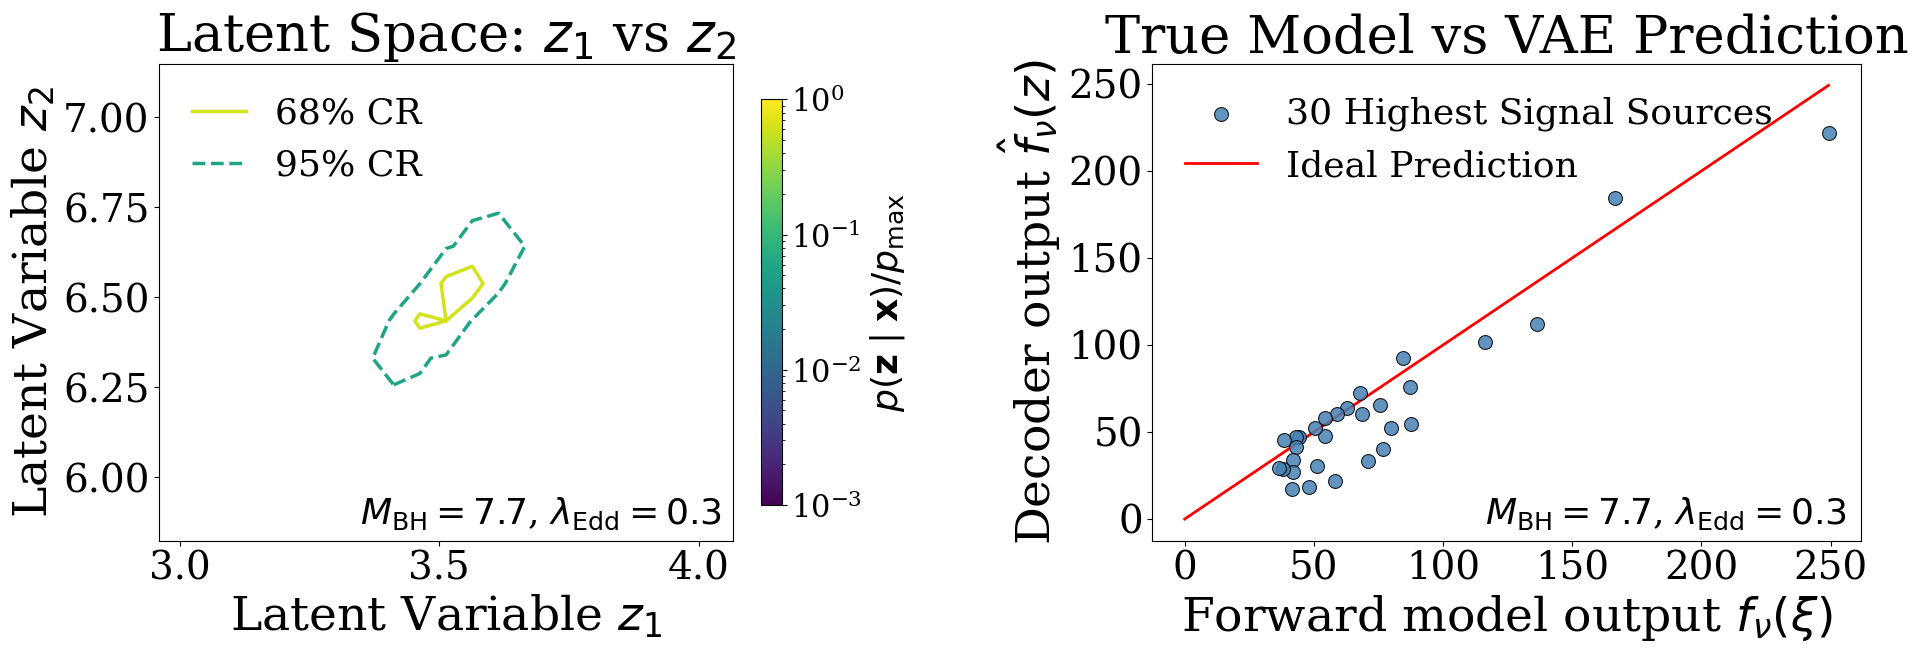

Saved: figures/step_model/overlay_mbh73_edd03.png
  Config 3: M_BH=7.3, λ_Edd=0.3
    log L(bkg)=5559.83  log L(H1)=13207.59  Δ log L=7647.76
    TS=15295.52  Odds=~10^3321  σ=123.7  Corr=0.9454  RMSE=21.4112



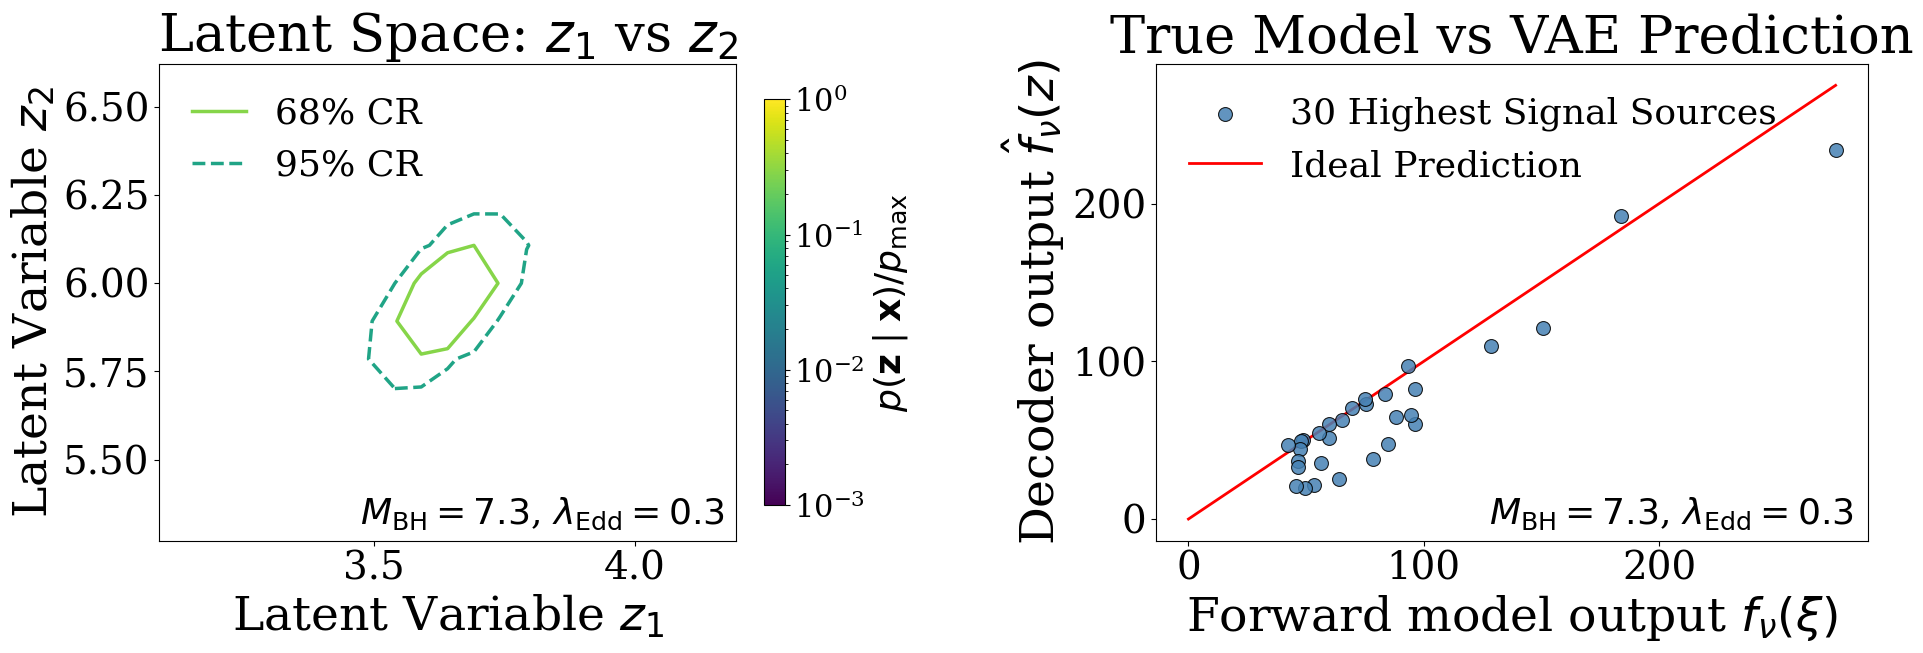

Saved: figures/step_model/overlay_mbh70_edd03.png
  Config 4: M_BH=7.0, λ_Edd=0.3
    log L(bkg)=7682.91  log L(H1)=16708.60  Δ log L=9025.69
    TS=18051.39  Odds=~10^3920  σ=134.4  Corr=0.8940  RMSE=34.9863



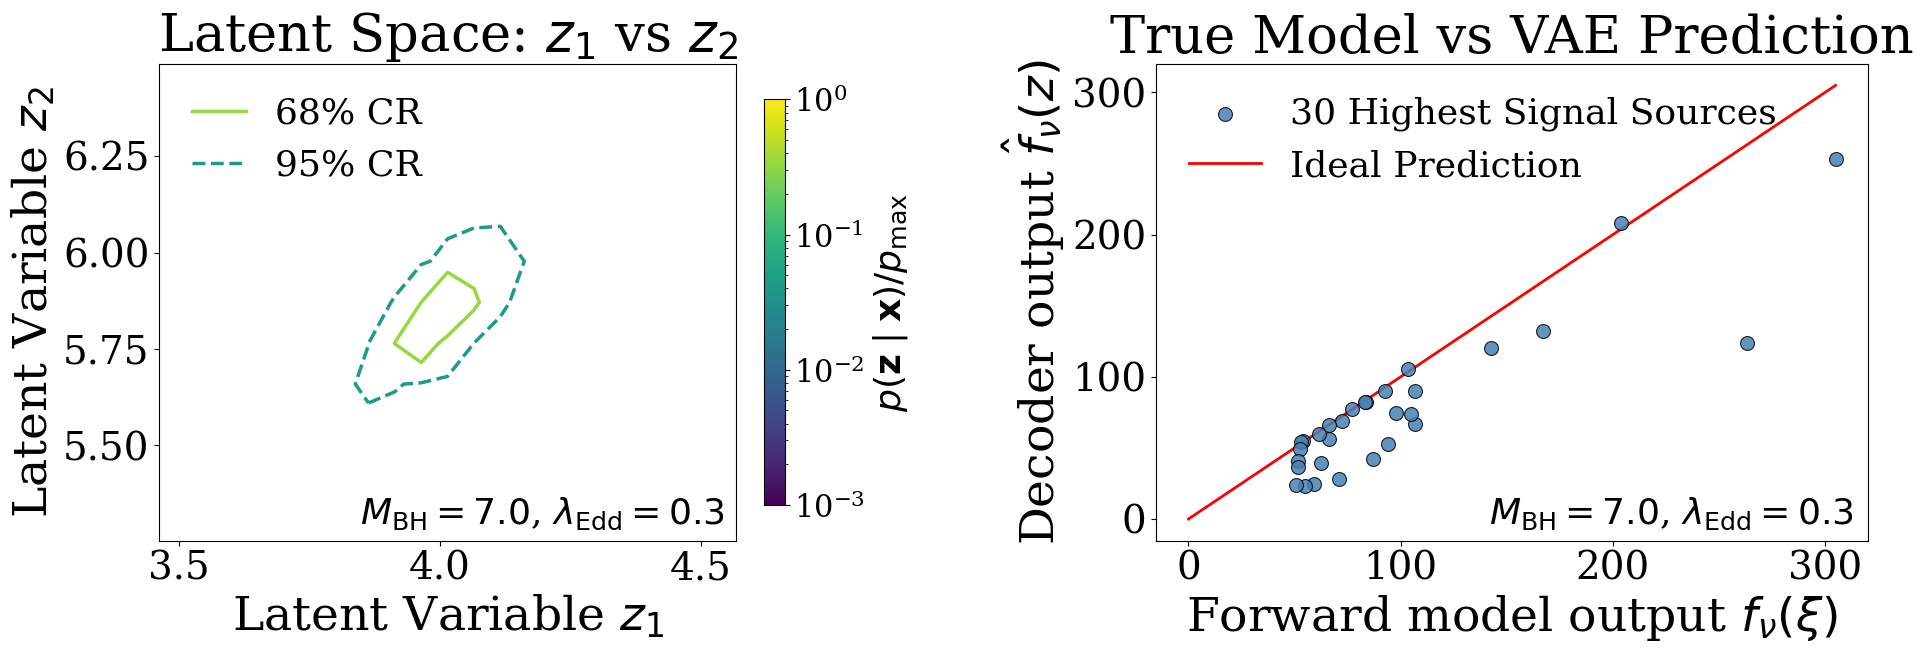

Saved: figures/step_model/overlay_mbh80_edd005.png
  Config 5: M_BH=8.0, λ_Edd=0.05
    log L(bkg)=568.18  log L(H1)=1225.85  Δ log L=657.67
    TS=1315.34  Odds=~10^286  σ=36.3  Corr=0.8640  RMSE=11.4263



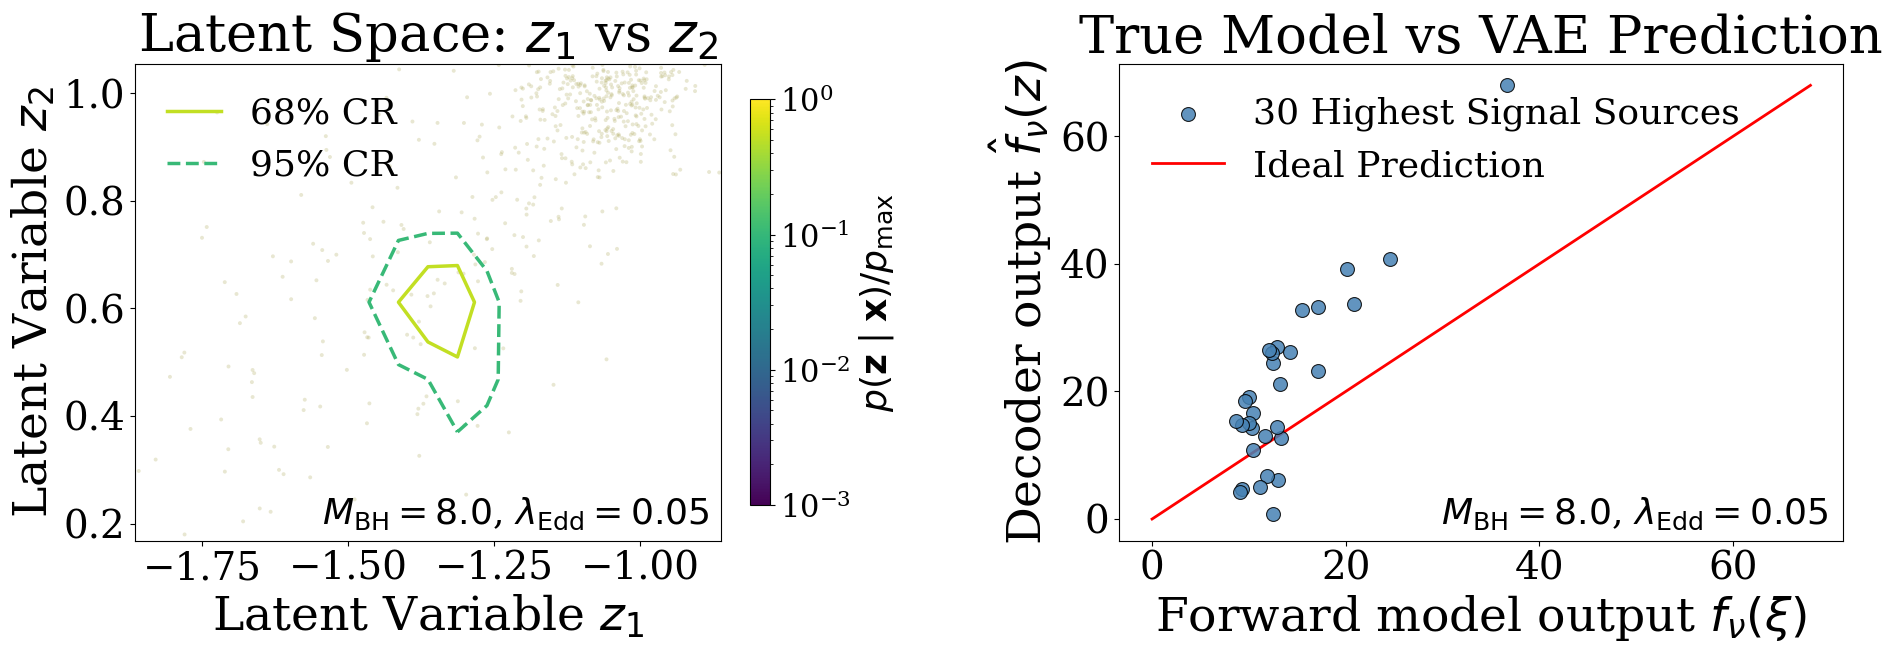

Saved: figures/step_model/overlay_mbh80_edd01.png
  Config 6: M_BH=8.0, λ_Edd=0.1
    log L(bkg)=4898.59  log L(H1)=9571.08  Δ log L=4672.50
    TS=9345.00  Odds=~10^2029  σ=96.7  Corr=0.8841  RMSE=18.6459



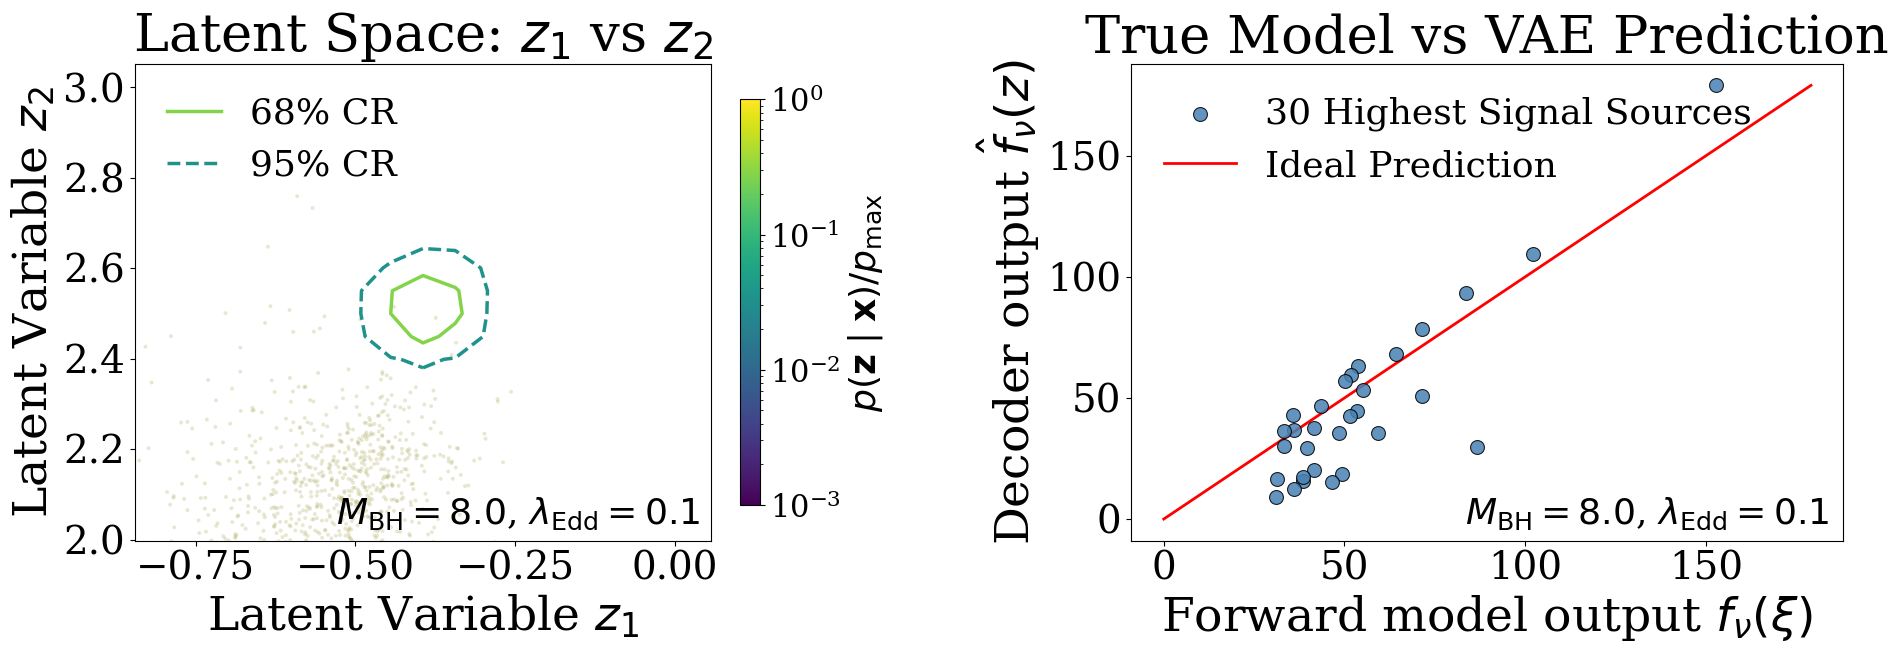

Saved: figures/step_model/overlay_mbh80_edd02.png
  Config 7: M_BH=8.0, λ_Edd=0.2
    log L(bkg)=2031.71  log L(H1)=5713.82  Δ log L=3682.11
    TS=7364.22  Odds=~10^1599  σ=85.8  Corr=0.8757  RMSE=18.6498



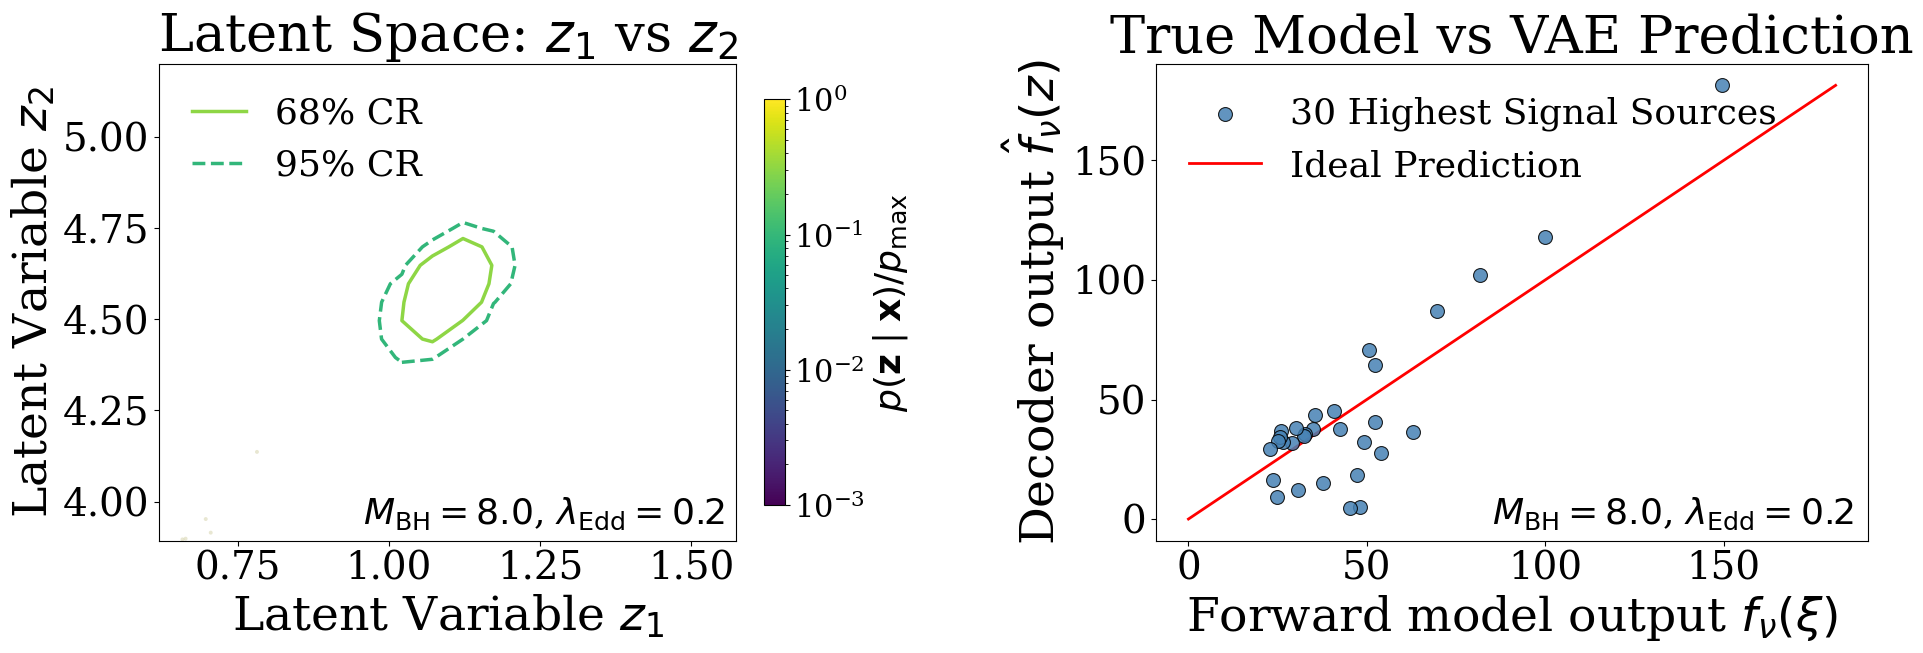

Saved: figures/step_model/overlay_mbh80_edd05.png
  Config 8: M_BH=8.0, λ_Edd=0.5
    log L(bkg)=13282.89  log L(H1)=39174.87  Δ log L=25891.98
    TS=51783.96  Odds=~10^11245  σ=227.6  Corr=0.9073  RMSE=213.4378



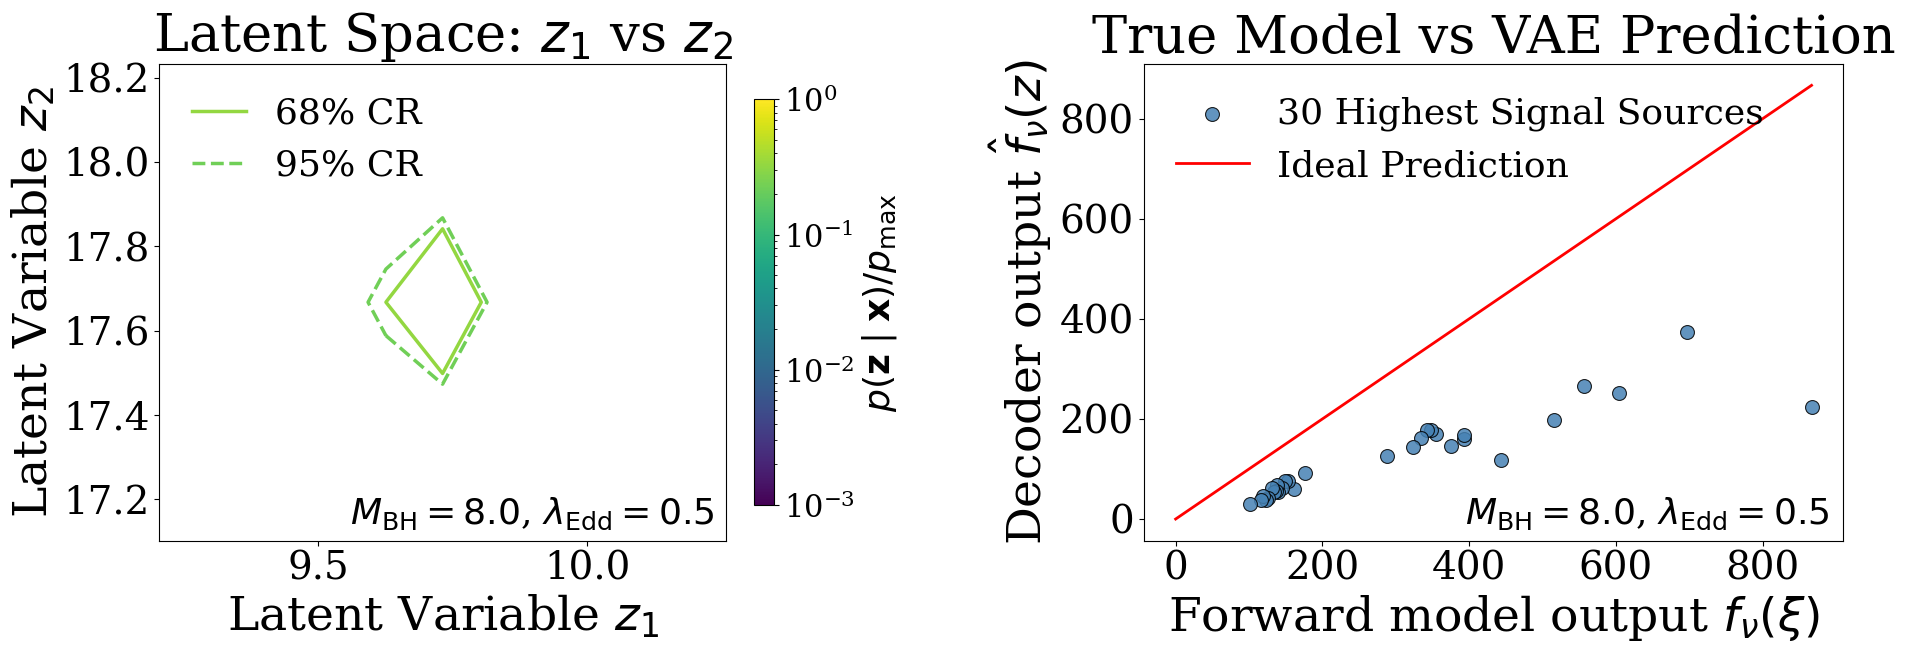


✓ 8 overlay figures saved.


In [ ]:
#overlay plots 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

os.makedirs("figures/step_model", exist_ok=True)

plt.rcParams.update({
    'font.size': 30,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 26,
    'legend.fontsize': 22,
})

viridis = cm.viridis

for idx, res in enumerate(all_results):
    scatter = res['scatter_results']
    posterior = res['posterior_latent']
    z1_range = res['latent_dim1_range']
    z2_range = res['latent_dim2_range']
    true_top30 = res['true_signal_top30']
    pred_top30 = res['predicted_signal_top30']
    mbh = res['mbh_thres']
    edd = res['e_ratio_thres']
    label = res['config_label']

    # odds ratio info
    dlogL = res['delta_log_L']
    log_L_bkg = res['log_L_bkg']
    log_L_H1 = res['log_L_H1']
    ts = 2 * dlogL
    log10_ratio = dlogL / np.log(10)
    sigma_equiv = np.sqrt(ts)
    if dlogL < 500:
        ratio_str = f"{np.exp(dlogL):.2e}"
    else:
        ratio_str = f"~10^{log10_ratio:.0f}"

    Z1_grid, Z2_grid = np.meshgrid(z1_range, z2_range)

    max_post = posterior.max()
    post_norm = posterior / max_post
    post_norm = np.clip(post_norm, 1e-6, 1.0)

    flat = posterior.flatten()
    sorted_flat = np.sort(flat)[::-1]
    cumulative = np.cumsum(sorted_flat)
    level_68 = sorted_flat[np.searchsorted(cumulative, 0.68)]
    level_95 = sorted_flat[np.searchsorted(cumulative, 0.95)]

    norm_cmap = LogNorm(vmin=1e-3, vmax=1.0)
    color_68 = viridis(norm_cmap(level_68 / max_post))
    color_95 = viridis(norm_cmap(level_95 / max_post))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    #left: latent scatter + viridis CR contours
    ax1.scatter(scatter[:, 0], scatter[:, 1],
                alpha=0.3, s=8, color='#b5b06a', edgecolors='none', zorder=1)

    ax1.contour(Z1_grid, Z2_grid, posterior,
                levels=[level_95], colors=[color_95], linewidths=2.5,
                linestyles='dashed', zorder=3)
    ax1.contour(Z1_grid, Z2_grid, posterior,
                levels=[level_68], colors=[color_68], linewidths=2.5,
                linestyles='solid', zorder=3)

    sm = cm.ScalarMappable(cmap='viridis', norm=norm_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax1, pad=0.04, shrink=0.85)
    cbar.set_label(r'$p(\mathbf{z} \mid \mathbf{x}) / p_{\mathrm{max}}$', fontsize=26)
    cbar.ax.tick_params(labelsize=22)

    legend_handles = [
        Line2D([0], [0], color=color_68, linewidth=2.5, linestyle='-', label='68% CR'),
        Line2D([0], [0], color=color_95, linewidth=2.5, linestyle='--', label='95% CR'),
    ]
    ax1.legend(handles=legend_handles, loc='upper left', frameon=False,
               fontsize=26, handlelength=1.5)

    param_text = rf'$M_{{\rm BH}} = {mbh}$, $\lambda_{{\rm Edd}} = {edd}$'
    ax1.text(0.98, 0.02, param_text, transform=ax1.transAxes,
             fontsize=26, ha='right', va='bottom')

    significant = np.log(post_norm) > -10.0
    if significant.any():
        rows, cols = np.where(significant)
        pad = max((z1_range[1]-z1_range[0])*3, 0.3)
        ax1.set_xlim(z1_range[cols.min()] - pad, z1_range[cols.max()] + pad)
        ax1.set_ylim(z2_range[rows.min()] - pad, z2_range[rows.max()] + pad)

    ax1.set_xlabel(r'Latent Variable $z_1$', fontsize=34)
    ax1.set_ylabel(r'Latent Variable $z_2$', fontsize=34)
    ax1.set_title(r'Latent Space: $z_1$ vs $z_2$', fontsize=38)
    ax1.tick_params(axis='both', labelsize=28)

    # right: True vs VAE Prediction
    ax2.scatter(true_top30, pred_top30, s=100, color='steelblue',
                edgecolor='black', linewidth=0.8, alpha=0.85, zorder=3,
                label='30 Highest Signal Sources')

    mn = min(true_top30.min(), pred_top30.min(), 0)
    mx = max(true_top30.max(), pred_top30.max())
    ax2.plot([mn, mx], [mn, mx], '-', color='red', linewidth=2, zorder=2,
             label='Ideal Prediction')

    ax2.set_xlabel(r'Forward model output $f_\nu(\xi)$', fontsize=34)
    ax2.set_ylabel(r'Decoder output $\hat{f}_\nu(z)$', fontsize=34)
    ax2.set_title('True Model vs VAE Prediction', fontsize=38)
    ax2.tick_params(axis='both', labelsize=28)
    ax2.legend(loc='upper left', frameon=False, fontsize=26)

    ax2.text(0.98, 0.02, param_text, transform=ax2.transAxes,
             fontsize=26, ha='right', va='bottom')

    fig.tight_layout(pad=2.0)

    fname = f"figures/step_model/overlay_mbh{str(mbh).replace('.','')}_edd{str(edd).replace('.','')}.png"
    fig.savefig(fname, dpi=150, bbox_inches='tight', pad_inches=0.3)
    print(f"Saved: {fname}")
    print(f"  Config {idx+1}: M_BH={mbh}, λ_Edd={edd}")
    print(f"    log L(bkg)={log_L_bkg:.2f}  log L(H1)={log_L_H1:.2f}  Δ log L={dlogL:.2f}")
    print(f"    TS={ts:.2f}  Odds={ratio_str}  σ={sigma_equiv:.1f}  Corr={res['correlation']:.4f}  RMSE={res['rmse']:.4f}")
    print()
    plt.show()

print(f"\n✓ {len(all_results)} overlay figures saved.")


In [ ]:
#Odds Ratio Overview: Step Model

import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures/step_model', exist_ok=True)

print("=" * 40)
print("Odds Ratio Overview: Step Model (All Configurations)")
print("=" * 40)

#detailed per-configuration table
header = (f"{'#':<4} {'Config Label':<35} {'log L(bkg)':<14} {'log L(H1)':<14} "
          f"{'Δ log L':<12} {'TS=2ΔlogL':<14} {'Odds Ratio':<22}")
print("\n" + header)
print("-" * len(header))

odds_labels = []
odds_delta = []
odds_ts = []
odds_ratio_str = []
odds_log10 = []

for idx, res in enumerate(all_results):
    mbh = res['mbh_thres']
    edd = res['e_ratio_thres']
    label = res['config_label']
    dlogL = res['delta_log_L']
    logL_bkg = res['log_L_bkg']
    logL_H1 = res['log_L_H1']
    ts = 2 * dlogL
    log10_ratio = dlogL / np.log(10)

    if dlogL < 500:
        ratio_str = f"{np.exp(dlogL):.2e}"
    else:
        ratio_str = f"~10^{log10_ratio:.0f}"

    print(f"{idx+1:<4} {label:<35} {logL_bkg:<14.2f} {logL_H1:<14.2f} "
          f"{dlogL:<12.2f} {ts:<14.2f} {ratio_str:<22}")

    odds_labels.append(f"C{idx+1}: MBH={mbh}, Edd={edd}")
    odds_delta.append(dlogL)
    odds_ts.append(ts)
    odds_ratio_str.append(ratio_str)
    odds_log10.append(log10_ratio)

# summary statistics
print("\n" + "=" * 90)
print("  Summary Statistics")
print("=" * 90)
print(f"  Number of configurations:     {len(all_results)}")
print(f"  Mean Δ log L:                 {np.mean(odds_delta):.2f}")
print(f"  Std  Δ log L:                 {np.std(odds_delta):.2f}")
print(f"  Min  Δ log L:                 {np.min(odds_delta):.2f}  (Config {np.argmin(odds_delta)+1})")
print(f"  Max  Δ log L:                 {np.max(odds_delta):.2f}  (Config {np.argmax(odds_delta)+1})")
print(f"  Mean TS (2ΔlogL):             {np.mean(odds_ts):.2f}")
print(f"  Min  TS:                      {np.min(odds_ts):.2f}")
print(f"  Max  TS:                      {np.max(odds_ts):.2f}")
print(f"  Mean log_10(odds ratio):       {np.mean(odds_log10):.1f}")
print(f"  Range log_10(odds ratio):      {np.min(odds_log10):.1f} – {np.max(odds_log10):.1f}")

all_detected = all(d > 0 for d in odds_delta)
print(f"\n  All configurations favour H1 over H0 (bkg-only): {'YES' if all_detected else 'NO'}")
sigma_equiv = [np.sqrt(ts) for ts in odds_ts]
print(f"  Gaussian-equivalent significance range: {min(sigma_equiv):.1f}σ – {max(sigma_equiv):.1f}σ")

# compact per-configuration summary with correlation & RMSE
print("\n" + "=" * 90)
print("  Per-Configuration: Odds Ratio + Reconstruction Quality")
print("=" * 90)
header2 = f"{'#':<4} {'Label':<35} {'log_10(OR)':<14} {'σ equiv':<10} {'Corr':<10} {'RMSE':<10}"
print(header2)
print("-" * len(header2))
for idx, res in enumerate(all_results):
    label = res['config_label']
    dlogL = res['delta_log_L']
    ts = 2 * dlogL
    log10_r = dlogL / np.log(10)
    sig = np.sqrt(ts)
    corr = res['correlation']
    rmse = res['rmse']
    print(f"{idx+1:<4} {label:<35} {log10_r:<14.1f} {sig:<10.1f} {corr:<10.4f} {rmse:<10.4f}")

print("\n" + "=" * 90)


Odds Ratio Overview: Step Model (All Configurations)

#    Config Label                        log L(bkg)     log L(H1)      Δ log L      TS=2ΔlogL      Odds Ratio            
-------------------------------------------------------------------------------------------------------------------------
1    $\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.3$ 10336.89       26197.60       15860.71     31721.43       ~10^6888              
2    $\log M_{\mathrm{BH}} = 7.7$, $\lambda_{\mathrm{Edd}} = 0.3$ 3764.64        10037.55       6272.91      12545.83       ~10^2724              
3    $\log M_{\mathrm{BH}} = 7.3$, $\lambda_{\mathrm{Edd}} = 0.3$ 5559.83        13207.59       7647.76      15295.52       ~10^3321              
4    $\log M_{\mathrm{BH}} = 7$, $\lambda_{\mathrm{Edd}} = 0.3$ 7682.91        16708.60       9025.69      18051.39       ~10^3920              
5    $\log M_{\mathrm{BH}} = 8$, $\lambda_{\mathrm{Edd}} = 0.05$ 568.18         1225.85        657.67       1315.34   

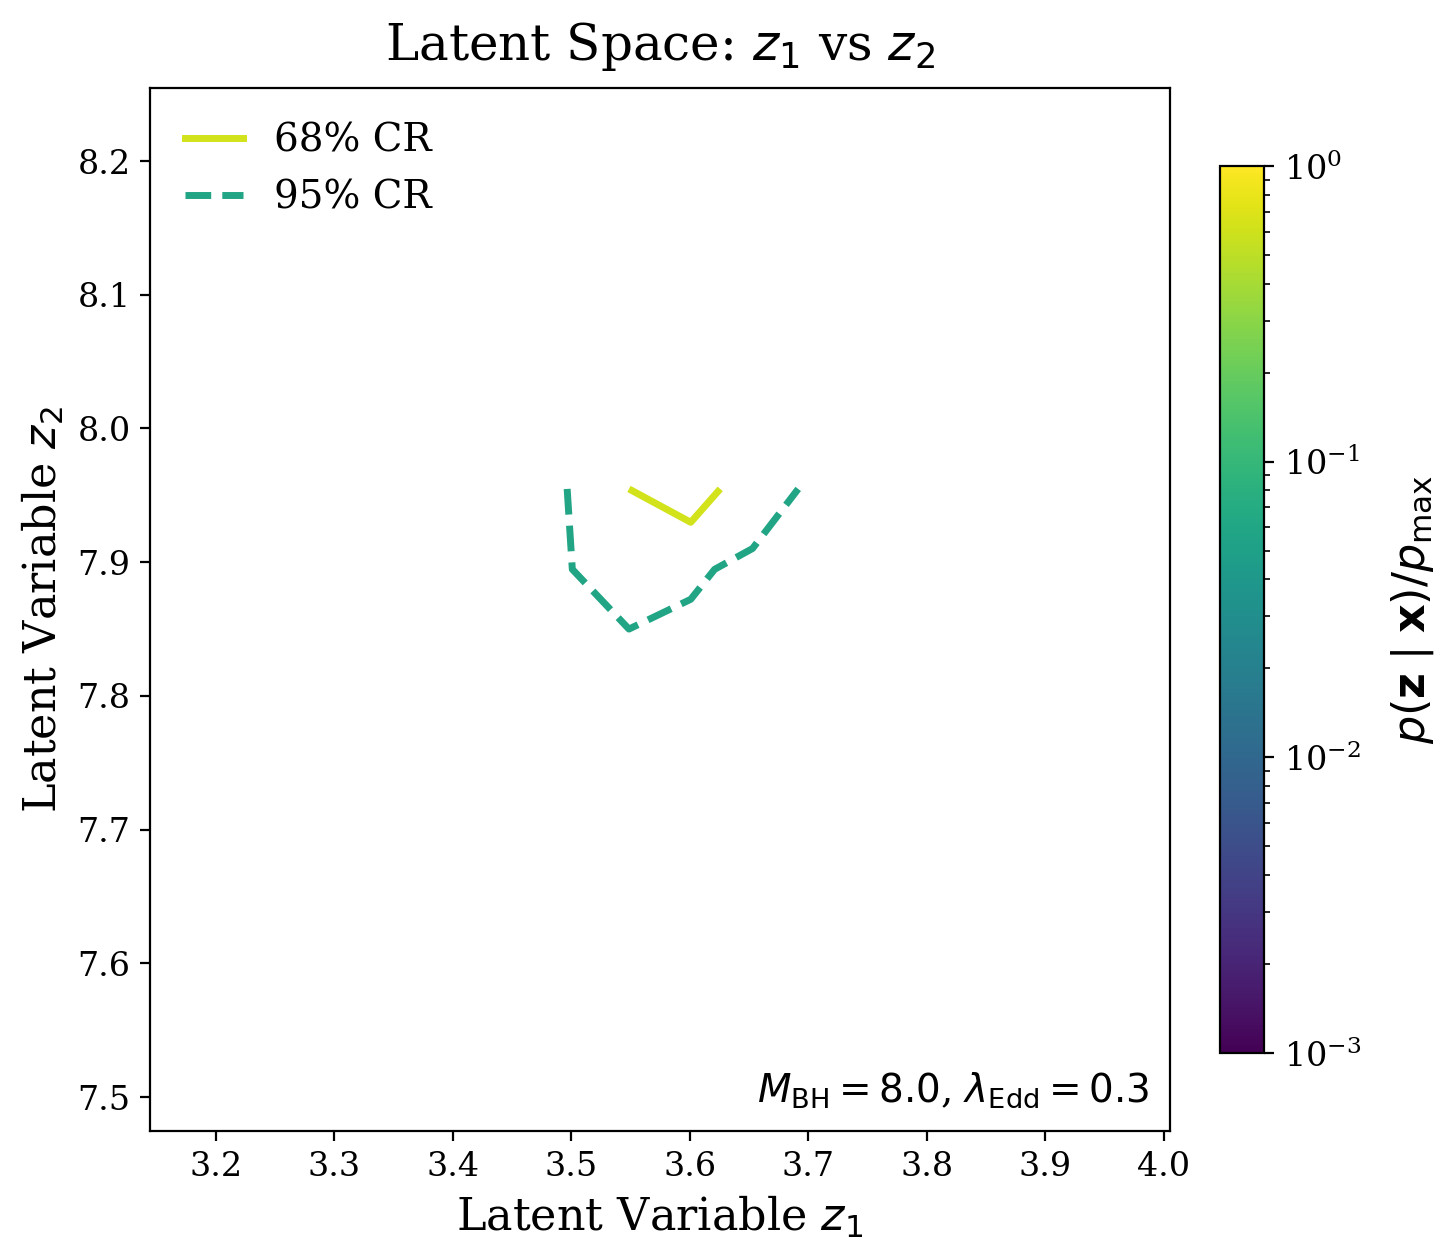

  Config 1: M_BH = 8.0, λ_Edd = 0.3
  68% credible level: 0.276028
  95% credible level: 0.025779


In [ ]:
# standalone plot: latent space z₁ vs z₂  (config 1: M_BH = 8.0, λ_Edd = 0.3)

from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib import cm

#extract Config 1 data
res = all_results[0]   # config 1: MBH=8.0, Edd=0.3

scatter    = res['scatter_results']
posterior  = res['posterior_latent']
z1_range   = res['latent_dim1_range']
z2_range   = res['latent_dim2_range']
mbh        = res['mbh_thres']
edd        = res['e_ratio_thres']

Z1_grid, Z2_grid = np.meshgrid(z1_range, z2_range)

# normalise posterior & compute credible levels
max_post   = posterior.max()
post_norm  = np.clip(posterior / max_post, 1e-6, 1.0)

flat        = posterior.flatten()
sorted_flat = np.sort(flat)[::-1]
cumulative  = np.cumsum(sorted_flat)
level_68    = sorted_flat[np.searchsorted(cumulative, 0.68)]
level_95    = sorted_flat[np.searchsorted(cumulative, 0.95)]

norm_cmap = LogNorm(vmin=1e-3, vmax=1.0)
viridis   = cm.viridis
color_68  = viridis(norm_cmap(level_68 / max_post))
color_95  = viridis(norm_cmap(level_95 / max_post))

# single standalone figure
fig, ax = plt.subplots(figsize=(8, 7), dpi=200)

# scatter cloud
ax.scatter(scatter[:, 0], scatter[:, 1],
           alpha=0.3, s=8, color='#b5b06a', edgecolors='none', zorder=1)

# 95% CR contour (dashed)
ax.contour(Z1_grid, Z2_grid, posterior,
           levels=[level_95], colors=[color_95], linewidths=2.5,
           linestyles='dashed', zorder=3)
# 68% CR contour (solid)
ax.contour(Z1_grid, Z2_grid, posterior,
           levels=[level_68], colors=[color_68], linewidths=2.5,
           linestyles='solid', zorder=3)

# colorbar
sm = cm.ScalarMappable(cmap='viridis', norm=norm_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.04, shrink=0.85)
cbar.set_label(r'$p(\mathbf{z} \mid \mathbf{x}) / p_{\mathrm{max}}$', fontsize=16, labelpad=10)
cbar.ax.tick_params(labelsize=12)

# legend
legend_handles = [
    Line2D([0], [0], color=color_68, linewidth=2.5, linestyle='-',  label='68% CR'),
    Line2D([0], [0], color=color_95, linewidth=2.5, linestyle='--', label='95% CR'),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=False,
          fontsize=14, handlelength=1.5)

# parameter annotation
param_text = rf'$M_{{\rm BH}} = {mbh}$, $\lambda_{{\rm Edd}} = {edd}$'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes,
        fontsize=14, ha='right', va='bottom')

# auto-zoom to the significant region
significant = np.log(post_norm) > -10.0
if significant.any():
    rows, cols = np.where(significant)
    pad = max((z1_range[1] - z1_range[0]) * 3, 0.3)
    ax.set_xlim(z1_range[cols.min()] - pad, z1_range[cols.max()] + pad)
    ax.set_ylim(z2_range[rows.min()] - pad, z2_range[rows.max()] + pad)

ax.set_xlabel(r'Latent Variable $z_1$', fontsize=16)
ax.set_ylabel(r'Latent Variable $z_2$', fontsize=16)
ax.set_title(r'Latent Space: $z_1$ vs $z_2$', fontsize=18, pad=10)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('figures/step_model/latent_space_mbh80_edd03_standalone.png',
            dpi=200, bbox_inches='tight')
plt.show()

print(f"  Config 1: M_BH = {mbh}, λ_Edd = {edd}")
print(f"  68% credible level: {level_68:.6f}")
print(f"  95% credible level: {level_95:.6f}")